01/06-2026

#### **Main immunoprecipitation experiments:**

* R876 (run4 - P0249_R0876_X957 - Immunoprecipitation) <br>
* R1101 (run5 - P0249_R1101_X1367 - Immunoprecipitation) <br>
* R1344 (run6 - P0249_R1344_X1882 - Immunoprecipitation) <br>

**Isoform and TrEMBL coverage**: PRI did include isoforms in their database. They also included unreviewed proteins (TrEMBL) - but not all of those have gene IDs, only protein IDs! 

**Purpose**: This script will analyse and compare the output from 3 experiments, in order to combine a pipeline to filter hits across the datasets. 

**Regarding LFQ intensities**: They are intensities which have been normalized for each dataset. That means that they are not directly comparable across the experiments/ datasets! 

In [2]:
import pandas as pd

#Set the maximum number of columns to display
pd.set_option('display.max_columns', None)  #None means show all columns


In [3]:
#Important Python script functions for loading the proteomic data from FragPipe and MaxQuant. 
import sys
sys.path.append('../helper_functions')

from load_fragPipe_proteomic_data import load_fragPipe_proteomic_data
from load_fragPipe_proteomic_psm_data import load_fragPipe_proteomic_psm_data
from load_maxQuant_proteomic_data import load_maxQuant_proteomic_data


In [4]:
#Loading MaxQuant data (from PRI):

###

#Run 4: 
print("=== Loading Run4 MaxQuant Data ===")
ROOT_run4 = "/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run4_PRI_MaxQuant_P0249_R0876_X957/txt" #(!) Change this value accordingly (!) 
annotation_file_run4 = "../annotation_folder/experiment_annotation_run4_R876.tsv" 

master_prot_run4_maxQuant_df, master_pep_run4_maxQuant_df = load_maxQuant_proteomic_data(ROOT_run4, annotation_file_run4) 

###

#Run 5: s
print("\n=== Loading Run5 MaxQuant Data ===")
ROOT_run5 = "/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run5_PRI_MaxQuant_P0249_R1101_X1367/txt" #(!) Change this value accordingly (!) 
annotation_file_run5 = "../annotation_folder/experiment_annotation_run5_R1101.tsv" 

master_prot_run5_maxQuant_df, master_pep_run5_maxQuant_df = load_maxQuant_proteomic_data(ROOT_run5, annotation_file_run5) 

###

#Run 6: 
print("\n=== Loading Run6 MaxQuant Data ===")
ROOT_run6 = "/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run6_PRI_MaxQuant_P0249_R1344_X1882/txt" #(!) Change this value accordingly (!) 
annotation_file_run6 = "../annotation_folder/experiment_annotation_run6_R1344.tsv" 

master_prot_run6_maxQuant_df, master_pep_run6_maxQuant_df = load_maxQuant_proteomic_data(ROOT_run6, annotation_file_run6) 



=== Loading Run4 MaxQuant Data ===
Loaded annotations: Found 30 total samples in annotation file.

Processing proteinGroups.txt...
Filtered out contaminants based on 'Potential contaminant' column.
Filtered out reverse hits.
Filtered out 'Only identified by site' hits.
-> Loaded 25664 positive LFQ protein detections.

Processing peptides.txt...
Filtered out contaminants based on 'Potential contaminant' column.
Filtered out reverse hits.
-> Loaded 198826 positive peptide detections.

✅ Data loading complete! 'master_prot_df' and 'master_pep_df' for MaxQuant output are ready.

=== Loading Run5 MaxQuant Data ===
Loaded annotations: Found 27 total samples in annotation file.

Processing proteinGroups.txt...
Filtered out contaminants based on 'Potential contaminant' column.
Filtered out reverse hits.
Filtered out 'Only identified by site' hits.
-> Loaded 53362 positive LFQ protein detections.

Processing peptides.txt...
Filtered out contaminants based on 'Potential contaminant' column.
Filt

In [5]:
#Filtering out irrelevant parts of the data (e.g. the contaminanted GALD sample 14). 

#GALD14 is the contaminated GALD sample, we will filter it out in the downstream analysis.

master_prot_run4_maxQuant_df = master_prot_run4_maxQuant_df[master_prot_run4_maxQuant_df['Sample'] != 'sample_14'].copy()
master_pep_run4_maxQuant_df = master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df['Sample'] != 'sample_14'].copy()

master_prot_run5_maxQuant_df = master_prot_run5_maxQuant_df[master_prot_run5_maxQuant_df['Sample'] != 'sample_14'].copy()
master_pep_run5_maxQuant_df = master_pep_run5_maxQuant_df[master_pep_run5_maxQuant_df['Sample'] != 'sample_14'].copy()

master_prot_run6_maxQuant_df = master_prot_run6_maxQuant_df[(master_prot_run6_maxQuant_df['Sample'] != 'sample_14') & (master_prot_run6_maxQuant_df['Sample'] != 'sample_56')].copy()
master_pep_run6_maxQuant_df = master_pep_run6_maxQuant_df[(master_pep_run6_maxQuant_df['Sample'] != 'sample_14') & (master_pep_run6_maxQuant_df['Sample'] != 'sample_56')].copy()

print("Successfully filtered out sample_14 (and sample_56 from run6) from all DataFrames.")


Successfully filtered out sample_14 (and sample_56 from run6) from all DataFrames.


In [6]:
#Check 
# Concrete example of GALD1, peptide-level, Run 6 - after having loaded initial data and processed it a bit: 

display(master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Sample"] == "sample_1"].head(3))

print(master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Sample"] == "sample_1"].shape)


,Peptide Sequence,Protein,Protein Group,Gene,Protein Name,Score,PEP,Sample_Col,Razor Intensity,Sample,Group,Sample_type,Protein Description
2,AAAAKPNNLSLVVHGPGDLR,Q00796,Q00796;A0A6I8PIS1;H0YKB3;Q00796-2;A0A6I8PRA7,SORD,Sorbitol dehydrogenase,255.710,6.199700e-77,LFQ intensity 01_S2-A1_1_10366,347990.0,sample_1,GALD,Liver Lysate,NaN
3,AAAAPVAADDDERR,B4DHR0,B4DHR0;Q9H5N1-2;Q9H5N1,RABEP2,Rab GTPase-binding effector protein 2,103.870,9.581400e-04,LFQ intensity 01_S2-A1_1_10366,20736.0,sample_1,GALD,Liver Lysate,NaN
9,AAAEEVPIEPYNIPLSQAEVIQEGSDVTLVAWGTQVHVIR,P21953,P21953,BCKDHB,"2-oxoisovalerate dehydrogenase subunit beta, m...",40.045,4.911900e-06,LFQ intensity 01_S2-A1_1_10366,20281.0,sample_1,GALD,Liver Lysate,sp|P21953|ODBB_HUMAN 2-oxoisovalerate dehydrog...


(12747, 13)


**Reminder**: more than 1 peptide needs to be mapped to a particular protein, before that protein will make it into the protein-level

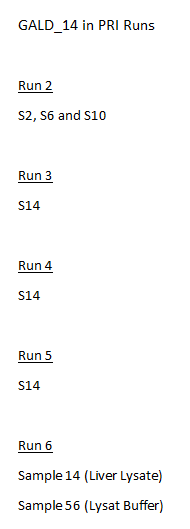

In [7]:
#What the raw protein output data looks like: 
prot_df = pd.read_csv("/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run6_PRI_MaxQuant_P0249_R1344_X1882/txt/proteinGroups.txt", sep='\t')

prot_df[prot_df["Gene names"].str.contains(";", na=False)]

#Mapping logic - protein-level:
        # 'Majority protein IDs': 'Protein', 
        # 'Protein IDs': 'Protein Group', 
        # 'Fasta headers': 'Description', 
        # 'Gene names': 'Gene', 
        # 'Protein names': 'Protein Name' 

/tmp/ipykernel_1908/3697576982.py:2: DtypeWarning: Columns (695) have mixed types. Specify dtype option on import or set low_memory=False.
  prot_df = pd.read_csv("/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run6_PRI_MaxQuant_P0249_R1344_X1882/txt/proteinGroups.txt", sep='\t')


,Protein IDs,Majority protein IDs,Peptide counts (all),Peptide counts (razor+unique),Peptide counts (unique),Protein names,Gene names,Fasta headers,Number of proteins,Peptides,Razor + unique peptides,Unique peptides,Peptides 01_S2-A1_1_10366,Peptides 02_S2-A2_1_10367,Peptides 03_S2-A3_1_10368,Peptides 04_S2-A4_1_10369,Peptides 05_S2-A5_1_10370,Peptides 06_S2-A6_1_10371,Peptides 07_S2-A7_1_10372,Peptides 08_S2-A8_1_10373,Peptides 09_S2-A9_1_10374,Peptides 10_S2-A10_1_10375,Peptides 11_S2-A11_1_10376,Peptides 12_S2-A12_1_10377,Peptides 13_S2-B1_1_10378,Peptides 14_S2-B2_1_10379,Peptides 15_S2-B3_1_10380,Peptides 16_S2-B4_1_10383,Peptides 17_S2-B5_1_10384,Peptides 18_S2-B6_1_10385,Peptides 19_S2-B7_1_10386,Peptides 20_S2-B8_1_10387,Peptides 21_S2-B9_1_10388,Peptides 22_S2-B10_1_10389,Peptides 23_S2-B11_1_10390,Peptides 24_S2-B12_1_10391,Peptides 25_S2-C1_1_10392,Peptides 26_S2-C2_1_10393,Peptides 27_S2-C3_1_10394,Peptides 28_S2-C4_1_10397,Peptides 29_S2-C5_1_10398,Peptides 30_S2-C6_1_10399,Peptides 31_S2-C7_1_10400,Peptides 32_S2-C8_1_10401,Peptides 33_S2-C9_1_10402,Peptides 34_S2-C10_1_10403,Peptides 35_S2-C11_1_10404,Peptides 36_S2-C12_1_10405,Peptides 37_S2-D1_1_10406,Peptides 38_S2-D2_1_10407,Peptides 39_S2-D3_1_10408,Peptides 40_S2-D4_1_10409,Peptides 41_S2-D5_1_10410,Peptides 42_S2-D6_1_10411,Peptides 43_S2-D7_1_10417,Peptides 44_S2-D8_1_10418,Peptides 45_S2-D9_1_10419,Peptides 46_S2-D10_1_10420,Peptides 47_S2-D11_1_10421,Peptides 48_S2-D12_1_10422,Peptides 49_S2-E1_1_10423,Peptides 50_S2-E2_1_10424,Peptides 51_S2-E3_1_10425,Peptides 52_S2-E4_1_10426,Peptides 53_S2-E5_1_10427,Peptides 54_S2-E6_1_10428,Peptides 55_S2-E7_1_10429,Peptides 56_S2-E8_1_10430,Peptides 57_S2-E9_1_10431,Peptides 58_S2-E10_1_10434,Peptides 59_S2-E11_1_10435,Peptides 60_S2-E12_1_10436,Peptides 61_S2-F1_1_10437,Peptides 62_S2-F2_1_10438,Peptides 63_S2-F3_1_10439,Peptides 64_S2-F4_1_10440,Peptides 65_S2-F5_1_10441,Peptides 66_S2-F6_1_10442,Peptides 67_S2-F7_1_10443,Peptides 68_S2-F8_1_10444,Peptides 69_S2-F9_1_10445,Peptides 70_S2-F10_1_10448,Peptides 71_S2-F11_1_10449,Peptides 72_S2-F12_1_10450,Peptides 73_S2-G1_1_10451,Peptides 74_S2-G2_1_10452,Peptides 75_S2-G3_1_10453,Peptides 76_S2-G4_1_10454,Peptides 77_S2-G5_1_10455,Peptides 78_S2-G6_1_10456,Peptides 79_S2-G7_1_10457,Peptides 80_S2-G8_1_10458,Peptides 81_S2-G9_1_10459,Peptides 82_S2-G10_1_10460,Peptides 83_S2-G11_1_10461,Peptides 84_S2-G12_1_10462,Razor + unique peptides 01_S2-A1_1_10366,Razor + unique peptides 02_S2-A2_1_10367,Razor + unique peptides 03_S2-A3_1_10368,Razor + unique peptides 04_S2-A4_1_10369,Razor + unique peptides 05_S2-A5_1_10370,Razor + unique peptides 06_S2-A6_1_10371,Razor + unique peptides 07_S2-A7_1_10372,Razor + unique peptides 08_S2-A8_1_10373,Razor + unique peptides 09_S2-A9_1_10374,Razor + unique peptides 10_S2-A10_1_10375,Razor + unique peptides 11_S2-A11_1_10376,Razor + unique peptides 12_S2-A12_1_10377,Razor + unique peptides 13_S2-B1_1_10378,Razor + unique peptides 14_S2-B2_1_10379,Razor + unique peptides 15_S2-B3_1_10380,Razor + unique peptides 16_S2-B4_1_10383,Razor + unique peptides 17_S2-B5_1_10384,Razor + unique peptides 18_S2-B6_1_10385,Razor + unique peptides 19_S2-B7_1_10386,Razor + unique peptides 20_S2-B8_1_10387,Razor + unique peptides 21_S2-B9_1_10388,Razor + unique peptides 22_S2-B10_1_10389,Razor + unique peptides 23_S2-B11_1_10390,Razor + unique peptides 24_S2-B12_1_10391,Razor + unique peptides 25_S2-C1_1_10392,Razor + unique peptides 26_S2-C2_1_10393,Razor + unique peptides 27_S2-C3_1_10394,Razor + unique peptides 28_S2-C4_1_10397,Razor + unique peptides 29_S2-C5_1_10398,Razor + unique peptides 30_S2-C6_1_10399,Razor + unique peptides 31_S2-C7_1_10400,Razor + unique peptides 32_S2-C8_1_10401,Razor + unique peptides 33_S2-C9_1_10402,Razor + unique peptides 34_S2-C10_1_10403,Razor + unique peptides 35_S2-C11_1_10404,Razor + unique peptides 36_S2-C12_1_10405,Razor + unique peptides 37_S2-D1_1_10406,Razor + unique peptides 38_S2-D2_1_10407,Razor + uniq

Note to the sharp reader: Yes, I am the kind of idiot who stores MaxQuant data in a folder called 'FragPipe'... >_< <br>

In [8]:
#What the raw peptide output data looks like: 
pep_df = pd.read_csv("/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run6_PRI_MaxQuant_P0249_R1344_X1882/txt/peptides.txt", sep='\t')

pep_df[pep_df["Gene names"].str.contains(";", na=False)]

#Mapping logic - peptide-level:
#     'Sequence': 'Peptide Sequence',
#     'Leading razor protein': 'Protein',
#     'Proteins': 'Protein Group',     
#     'Gene names': 'Gene',
#     'Protein names': 'Protein Name'  

/tmp/ipykernel_1908/1138105785.py:2: DtypeWarning: Columns (298) have mixed types. Specify dtype option on import or set low_memory=False.
  pep_df = pd.read_csv("/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run6_PRI_MaxQuant_P0249_R1344_X1882/txt/peptides.txt", sep='\t')


,Sequence,N-term cleavage window,C-term cleavage window,Amino acid before,First amino acid,Second amino acid,Second last amino acid,Last amino acid,Amino acid after,A Count,R Count,N Count,D Count,C Count,Q Count,E Count,G Count,H Count,I Count,L Count,K Count,M Count,F Count,P Count,S Count,T Count,W Count,Y Count,V Count,U Count,O Count,Length,Missed cleavages,Mass,Proteins,Leading razor protein,Start position,End position,Gene names,Protein names,Unique (Groups),Unique (Proteins),Charges,PEP,Score,Identification type 01_S2-A1_1_10366,Identification type 02_S2-A2_1_10367,Identification type 03_S2-A3_1_10368,Identification type 04_S2-A4_1_10369,Identification type 05_S2-A5_1_10370,Identification type 06_S2-A6_1_10371,Identification type 07_S2-A7_1_10372,Identification type 08_S2-A8_1_10373,Identification type 09_S2-A9_1_10374,Identification type 10_S2-A10_1_10375,Identification type 11_S2-A11_1_10376,Identification type 12_S2-A12_1_10377,Identification type 13_S2-B1_1_10378,Identification type 14_S2-B2_1_10379,Identification type 15_S2-B3_1_10380,Identification type 16_S2-B4_1_10383,Identification type 17_S2-B5_1_10384,Identification type 18_S2-B6_1_10385,Identification type 19_S2-B7_1_10386,Identification type 20_S2-B8_1_10387,Identification type 21_S2-B9_1_10388,Identification type 22_S2-B10_1_10389,Identification type 23_S2-B11_1_10390,Identification type 24_S2-B12_1_10391,Identification type 25_S2-C1_1_10392,Identification type 26_S2-C2_1_10393,Identification type 27_S2-C3_1_10394,Identification type 28_S2-C4_1_10397,Identification type 29_S2-C5_1_10398,Identification type 30_S2-C6_1_10399,Identification type 31_S2-C7_1_10400,Identification type 32_S2-C8_1_10401,Identification type 33_S2-C9_1_10402,Identification type 34_S2-C10_1_10403,Identification type 35_S2-C11_1_10404,Identification type 36_S2-C12_1_10405,Identification type 37_S2-D1_1_10406,Identification type 38_S2-D2_1_10407,Identification type 39_S2-D3_1_10408,Identification type 40_S2-D4_1_10409,Identification type 41_S2-D5_1_10410,Identification type 42_S2-D6_1_10411,Identification type 43_S2-D7_1_10417,Identification type 44_S2-D8_1_10418,Identification type 45_S2-D9_1_10419,Identification type 46_S2-D10_1_10420,Identification type 47_S2-D11_1_10421,Identification type 48_S2-D12_1_10422,Identification type 49_S2-E1_1_10423,Identification type 50_S2-E2_1_10424,Identification type 51_S2-E3_1_10425,Identification type 52_S2-E4_1_10426,Identification type 53_S2-E5_1_10427,Identification type 54_S2-E6_1_10428,Identification type 55_S2-E7_1_10429,Identification type 56_S2-E8_1_10430,Identification type 57_S2-E9_1_10431,Identification type 58_S2-E10_1_10434,Identification type 59_S2-E11_1_10435,Identification type 60_S2-E12_1_10436,Identification type 61_S2-F1_1_10437,Identification type 62_S2-F2_1_10438,Identification type 63_S2-F3_1_10439,Identification type 64_S2-F4_1_10440,Identification type 65_S2-F5_1_10441,Identification type 66_S2-F6_1_10442,Identification type 67_S2-F7_1_10443,Identification type 68_S2-F8_1_10444,Identification type 69_S2-F9_1_10445,Identification type 70_S2-F10_1_10448,Identification type 71_S2-F11_1_10449,Identification type 72_S2-F12_1_10450,Identification type 73_S2-G1_1_10451,Identification type 74_S2-G2_1_10452,Identification type 75_S2-G3_1_10453,Identification type 76_S2-G4_1_10454,Identification type 77_S2-G5_1_10455,Identification type 78_S2-G6_1_10456,Identification type 79_S2-G7_1_10457,Identification type 80_S2-G8_1_10458,Identification type 81_S2-G9_1_10459,Identification type 82_S2-G10_1_10460,Identification type 83_S2-G11_1_10461,Identification type 84_S2-G12_1_10462,Experiment 01_S2-A1_1_10366,Experiment 02_S2-A2_1_10367,Experiment 03_S2-A3_1_10368,Experiment 04_S2-A4_1_10369,Experiment 05_S2-A5_1_10370,Experiment 06_S2-A6_1_10371,Experiment 07_S2-A7_1_10372,Experiment 08_S2-A8_1_10373,Experiment 09_S2-A9_1_10374,Experiment 10_S2-A10_1_10375,Experiment 11_S2-A11_1_10376,Experiment 12_S2-A12_1_10377,Experiment 13_S2-B1_1_1037

**Note:** We will mainly use Protein IDs and try to use Gene IDs as least as possible. 

## **Experiment setup - Overview**:

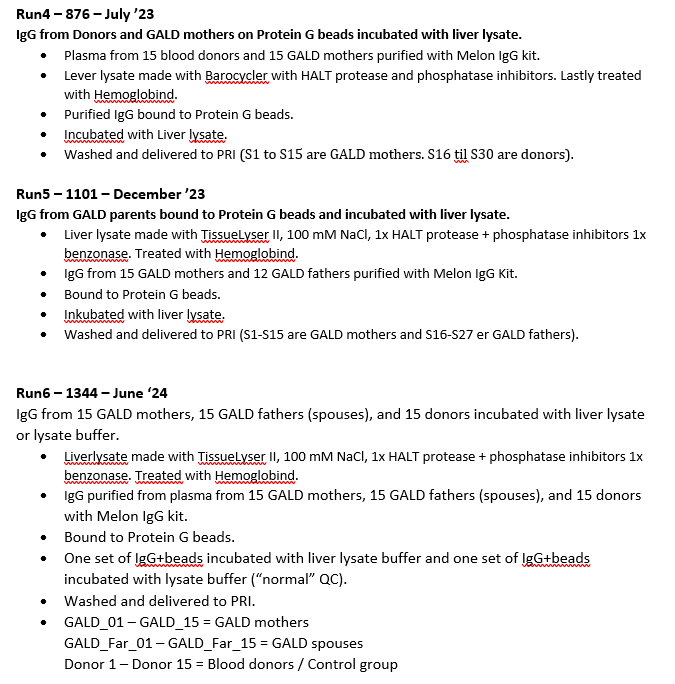

**General course of action**: <br>

1) Find **GALD-exclusive proteins** (Run6, Run5 and Run4) - Using **Fisher's exact test** <br>

2) **Experimentally overlap** of GALD proteins, in the 3 different experiments i.e. 4 subsets <br>

3) **PCA** loading values + random forest prediction model

4) **Volcano plot** - using intensities

5) **Bonus plots**

In [9]:
#Check: Do any proteins overlap between the Proteins Groups?
#Protein-level

import pandas as pd
from collections import defaultdict

print("--- Check: Overlapping Proteins Across Groups (Protein Level) ---")

# 1. Get unique Protein Group strings
# Drop NaNs just in case there are missing values
unique_groups = master_prot_run6_maxQuant_df["Protein Group"].dropna().unique()

print(f"Analyzing {len(unique_groups)} unique Protein Groups in master_prot_run6_maxQuant_df...")

# 2. Dictionary to track which distinct groups each individual protein belongs to
protein_to_groups = defaultdict(set)

for group in unique_groups:
    # Split the string by ';' and strip any accidental whitespace
    individual_proteins = [prot.strip() for prot in str(group).split(';')]
    
    for prot in individual_proteins:
        protein_to_groups[prot].add(group)

# 3. Filter for overlaps (Proteins that appear in >1 distinct group)
overlapping_proteins = {prot: groups for prot, groups in protein_to_groups.items() if len(groups) > 1}

# 4. Report the findings
if not overlapping_proteins:
    print("✅ CHECK PASSED: No individual protein belongs to more than one distinct Protein Group.")
else:
    print(f"⚠️ FOUND OVERLAPS: {len(overlapping_proteins)} individual proteins exist in multiple distinct Protein Groups.\n")
    
    # Create a DataFrame for easy viewing of the overlaps
    overlap_records = []
    for prot, groups in overlapping_proteins.items():
        overlap_records.append({
            "Individual Protein": prot,
            "Number of Groups": len(groups),
            # Join the distinct groups with ' || ' so it's easy to read apart from the ';' inside the groups
            "Associated Protein Groups": "  ||  ".join(groups) 
        })
        
    overlap_df = pd.DataFrame(overlap_records).sort_values("Number of Groups", ascending=False).reset_index(drop=True)
    
    print("Top overlapping proteins:")
    display(overlap_df.head(10)) # Shows the top 10 worst offenders

--- Check: Overlapping Proteins Across Groups (Protein Level) ---
Analyzing 2448 unique Protein Groups in master_prot_run6_maxQuant_df...
✅ CHECK PASSED: No individual protein belongs to more than one distinct Protein Group.


In [10]:
#Amount of GALD, Healthy and GALD spouse samples in the Lysate buffer samples: 
master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Sample_type"] == "Lysate buffer"].groupby("Sample")["Group"].unique().value_counts()


Group
[Healthy donor]    15
[GALD]             14
[GALD_spouse]      12
Name: count, dtype: int64

**Important**: Remove the Lysate Buffer samples before the main analysis

In [11]:
#Removing Lysate Buffer samples before main analysis:

#Peptide-level: 
master_pep_run6_maxQuant_df_LB = master_pep_run6_maxQuant_df.copy() #Make a copy to analyse the Lysate buffer samples, in case we need it. 
master_pep_run6_maxQuant_df = master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Sample_type"] != "Lysate buffer"].copy()

#Protein-level: 
master_prot_run6_maxQuant_df_LB = master_prot_run6_maxQuant_df.copy() #Make a copy to analyse the Lysate buffer samples, in case we need it. 
master_prot_run6_maxQuant_df = master_prot_run6_maxQuant_df[master_prot_run6_maxQuant_df["Sample_type"] != "Lysate buffer"].copy()

print("!The Lysate buffer samples have been successfully removed from the main DataFrames!")


!The Lysate buffer samples have been successfully removed from the main DataFrames!


### **1) Find GALD-exclusive proteins (Run6, Run5 and Run4) - Using Fisher's exact test**

When looking for presence/ absence, we will work with the protein-level data, as identical sequence are unlikely to pass the MS detector in all tests, even if the antigen protein is present. <br>
In other words, looking for repeating, identical peptide sequence is flawed. We can see which protein groups the various peptides will map to in the protein-level output. 
<br>
We could also assess this info from the peptide-level output, but it would be more complex, as peptide-level has not been treated for protein group redundancy and overlaps. 
<br>
Therefore, it is a better approach to look at which protein groups were detected and which were absent in the various samples, only from protein-level output. 

In [12]:
# Presence/ absence analysis - This version also tries to catch the gene IDs in the df (usefull for later analysis) 
# The peptide groups with peptides are highly present in the GALD mothers but underrepresented or absent in healthy and spouses
# The threshold is defined based on Fisher's Exact Test

import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

print("\n--- Calculating Presence/Absence Frequencies (Fisher's Exact Test) ---")

# ==========================================
# 1. DEFINE THE DYNAMIC FUNCTION
# ==========================================
def get_exclusive_targets(df, feature_col, df_name, group_pos='GALD', group_neg='Healthy donor'):
    """
    Calculates presence/absence frequencies using Fisher's Exact Test.
    Returns BOTH the statistically significant targets and the full dataset for look-ups.
    """
    # 1. Use the entire dataset
    target_df = df.copy() 
    
    # Check if both required groups exist in this specific dataframe
    available_groups = target_df['Group'].dropna().unique() #E.g. "GALD", "Healthy donor", "GALD_spouse"
    
    if group_pos not in available_groups or group_neg not in available_groups:
        return None, None
        
    # 2. Determine total samples per group
    pos_samples = target_df[target_df['Group'] == group_pos]['Sample'].unique()
    neg_samples = target_df[target_df['Group'] == group_neg]['Sample'].unique()
    
    total_pos = len(pos_samples)
    total_neg = len(neg_samples)
    
    if total_pos == 0 or total_neg == 0:
        return None, None
    
    # 3. Base summary df (Dynamically grab Description and Gene)
    agg_dict = {'Protein Description': 'first'}
    if 'Gene' in target_df.columns:
        agg_dict['Gene'] = 'first'
        
    summary_df = target_df.groupby(feature_col, as_index=False).agg(agg_dict)
    
    # 4. Calculate Counts and Mean Razor Intensity for Positive Group (GALD)
    pos_stats = target_df[target_df['Group'] == group_pos].groupby(feature_col).agg(
        Pos_Detect_Count=('Sample', 'nunique'),
        Pos_Mean_Int=('Razor Intensity', 'mean') 
    ).reset_index()
    pos_stats.rename(columns={'Pos_Detect_Count': f'{group_pos}_Detect_Count', 'Pos_Mean_Int': f'{group_pos}_Mean_Int'}, inplace=True)
    
    # 5. Calculate Counts and Mean Razor Intensity for Negative Group
    neg_stats = target_df[target_df['Group'] == group_neg].groupby(feature_col).agg(
        Neg_Detect_Count=('Sample', 'nunique'),
        Neg_Mean_Int=('Razor Intensity', 'mean') 
    ).reset_index()
    neg_stats.rename(columns={'Neg_Detect_Count': f'{group_neg}_Detect_Count', 'Neg_Mean_Int': f'{group_neg}_Mean_Int'}, inplace=True)
    
    # 6. Merge into master summary dataframe
    summary_df = summary_df.merge(pos_stats, on=feature_col, how='left')
    summary_df = summary_df.merge(neg_stats, on=feature_col, how='left')
    
    # 7. Fill NaNs for counts and intensities
    summary_df.fillna({
        f'{group_pos}_Detect_Count': 0,
        f'{group_neg}_Detect_Count': 0,
        f'{group_pos}_Mean_Int': 0,
        f'{group_neg}_Mean_Int': 0
    }, inplace=True)
    
    # 8. Convert Counts to Frequencies (%)
    summary_df[f'{group_pos}_Freq_%'] = (summary_df[f'{group_pos}_Detect_Count'] / total_pos) * 100
    summary_df[f'{group_neg}_Freq_%'] = (summary_df[f'{group_neg}_Detect_Count'] / total_neg) * 100
    summary_df['Freq_Difference'] = summary_df[f'{group_pos}_Freq_%'] - summary_df[f'{group_neg}_Freq_%']

    # ==========================================
    # 9. FISHER'S EXACT TEST
    # ==========================================
    def run_fisher(row): 
        pos_present = int(row[f'{group_pos}_Detect_Count'])
        pos_absent = total_pos - pos_present
        
        neg_present = int(row[f'{group_neg}_Detect_Count'])
        neg_absent = total_neg - neg_present
        
        # Contingency Table setup:
        # [ [GALD_Present, GALD_Absent], [Control_Present, Control_Absent] ]
        table = [[pos_present, pos_absent], [neg_present, neg_absent]]
        
        # alternative='greater' tests if the presence is significantly higher in the Positive group
        _, p_val = fisher_exact(table, alternative='greater')
        return p_val

    summary_df['Fisher_P_Value'] = summary_df.apply(run_fisher, axis=1)
    
    # FDR Correction (Benjamini-Hochberg)
    summary_df['FDR_Q_Value'] = multipletests(summary_df['Fisher_P_Value'], method='fdr_bh')[1]
    
    # Sort the full summary df for easier reading
    summary_df.sort_values(by=['Fisher_P_Value', 'Freq_Difference'], ascending=[True, False], inplace=True)
    
    # ==========================================
    # 10. DEFINE EXCLUSIVITY THRESHOLD
    # ==========================================
    # Significant by Fisher's test (p < 0.05) AND enriched in the positive group
    exclusive_mask = (summary_df['Fisher_P_Value'] < 0.05) & (summary_df['Freq_Difference'] > 0) #freq_diff above 0 --> pos group freq. is highest. pos group = GALD Mothers
    
    exclusive_targets = summary_df[exclusive_mask].copy()
    
    print(f"✔️ {df_name} | {group_pos} vs {group_neg}: Identified {len(exclusive_targets)} statistically significant targets out of {len(summary_df)} total features.")
    
    # Return both the filtered targets AND the full list
    return exclusive_targets, summary_df

# ==========================================
# 2. EXECUTE ACROSS ALL DATAFRAMES
# ==========================================

"""
RATIONALE FOR USING PROTEIN-LEVEL DATA:
When searching for whole-protein antigens (presence/absence), we rely exclusively on the protein-level output (`proteinGroups.txt`). 

1. The Stochastic MS Problem: Due to the stochastic nature of mass spectrometry sampling, relying on the detection of a single, identical peptide sequence across all biological replicates is too stringent and will result in high false-negative rates. 
2. The Inference Problem: While we could theoretically group the peptide-level data ourselves, the peptide output has not been fully resolved for protein redundancy. 

By using the protein-level data, we leverage MaxQuant's built-in maximum parsimony algorithms, which aggregate all scattered peptide evidence into high-confidence, non-redundant Protein Groups.
"""

df_list = [
    master_prot_run4_maxQuant_df, master_pep_run4_maxQuant_df,
    master_prot_run5_maxQuant_df, master_pep_run5_maxQuant_df,
    master_prot_run6_maxQuant_df, master_pep_run6_maxQuant_df
]

df_names = [
    "Run 4 (Protein)", "Run 4 (Peptide)",
    "Run 5 (Protein)", "Run 5 (Peptide)",
    "Run 6 (Protein)", "Run 6 (Peptide)"
]

# Dictionaries to store the output dataframes
exclusive_results = {}
all_results = {}

for i, df in enumerate(df_list):
    name = df_names[i]
    
    # Always use Protein Group for the structural grouping
    feature_column = 'Protein Group'
        
    # --- COMPARISON 1: GALD vs Healthy donor ---
    res_healthy_exclusive, res_healthy_all = get_exclusive_targets(df, feature_col=feature_column, df_name=name, group_pos='GALD', group_neg='Healthy donor')
    if res_healthy_exclusive is not None:
        exclusive_results[f"{name} - vs Healthy"] = res_healthy_exclusive
        all_results[f"{name} - vs Healthy"] = res_healthy_all
        
    # --- COMPARISON 2: GALD vs GALD_spouse ---
    res_spouse_exclusive, res_spouse_all = get_exclusive_targets(df, feature_col=feature_column, df_name=name, group_pos='GALD', group_neg='GALD_spouse')
    if res_spouse_exclusive is not None:
        exclusive_results[f"{name} - vs Spouse"] = res_spouse_exclusive
        all_results[f"{name} - vs Spouse"] = res_spouse_all

print("\nProcessing complete!")
print(" - Use the 'exclusive_results' dictionary to access only the statistically significant targets.")
print(" - Use the 'all_results' dictionary to access the full background data for manual look-ups.")



--- Calculating Presence/Absence Frequencies (Fisher's Exact Test) ---
✔️ Run 4 (Protein) | GALD vs Healthy donor: Identified 22 statistically significant targets out of 1128 total features.
✔️ Run 4 (Peptide) | GALD vs Healthy donor: Identified 91 statistically significant targets out of 3918 total features.
✔️ Run 5 (Protein) | GALD vs GALD_spouse: Identified 70 statistically significant targets out of 2350 total features.
✔️ Run 5 (Peptide) | GALD vs GALD_spouse: Identified 326 statistically significant targets out of 8076 total features.
✔️ Run 6 (Protein) | GALD vs Healthy donor: Identified 112 statistically significant targets out of 2393 total features.
✔️ Run 6 (Protein) | GALD vs GALD_spouse: Identified 47 statistically significant targets out of 2393 total features.
✔️ Run 6 (Peptide) | GALD vs Healthy donor: Identified 606 statistically significant targets out of 8520 total features.
✔️ Run 6 (Peptide) | GALD vs GALD_spouse: Identified 306 statistically significant targets 

In [13]:
#Small preview: 

#The keys for the dict with the GALD-exclusive proteins: 
print("Keys:",list(exclusive_results.keys()))
print()

#The GALD exclusive targets get stored in the 'exclusive_results' dict: 
print("Run 4 (Protein) - vs Healthy:")
display(exclusive_results['Run 4 (Protein) - vs Healthy'].head(3))
print()
print("Run 5 (Protein) - vs Spouse:")
display(exclusive_results['Run 5 (Protein) - vs Spouse'].head(3))
print()

print("Run 6 (Protein) - vs Healthy:")
display(exclusive_results.get("Run 6 (Protein) - vs Healthy").head(3))
print()
print("Run 6 (Protein) - vs Spouse:")
display(exclusive_results.get("Run 6 (Protein) - vs Spouse").head(3))


Keys: ['Run 4 (Protein) - vs Healthy', 'Run 4 (Peptide) - vs Healthy', 'Run 5 (Protein) - vs Spouse', 'Run 5 (Peptide) - vs Spouse', 'Run 6 (Protein) - vs Healthy', 'Run 6 (Protein) - vs Spouse', 'Run 6 (Peptide) - vs Healthy', 'Run 6 (Peptide) - vs Spouse']

Run 4 (Protein) - vs Healthy:


,Protein Group,Protein Description,Gene,GALD_Detect_Count,GALD_Mean_Int,Healthy donor_Detect_Count,Healthy donor_Mean_Int,GALD_Freq_%,Healthy donor_Freq_%,Freq_Difference,Fisher_P_Value,FDR_Q_Value
481,P04003;A6PVY5;F2Z2V7,sp|P04003|C4BPA_HUMAN C4b-binding protein alph...,C4BPA,10.0,67075.960000,0.0,0.0,71.428571,0.000000,71.428571,0.000050,0.056372
1070,Q9HC84,sp|Q9HC84|MUC5B_HUMAN Mucin-5B OS=Homo sapiens...,MUC5B,9.0,52608.777778,0.0,0.0,64.285714,0.000000,64.285714,0.000200,0.112744
292,G5E9F8;A0A3B3ISJ1;A0A0S2Z4L3;P07225;A0A3B3IRK9...,"tr|G5E9F8|G5E9F8_HUMAN Isoform of P07225, Prot...",PROS1,10.0,17530.930000,1.0,5720.4,71.428571,6.666667,64.761905,0.000445,0.167137



Run 5 (Protein) - vs Spouse:


,Protein Group,Protein Description,Gene,GALD_Detect_Count,GALD_Mean_Int,GALD_spouse_Detect_Count,GALD_spouse_Mean_Int,GALD_Freq_%,GALD_spouse_Freq_%,Freq_Difference,Fisher_P_Value,FDR_Q_Value
898,P00918;E5RID5;E5RK37,sp|P00918|CAH2_HUMAN Carbonic anhydrase 2 OS=H...,CA2,14.0,68484.107143,0.0,0.0,100.000000,0.000000,100.000000,1.035443e-07,0.000243
897,P00915;E5RHP7;E5RH81;E5RIF9;E5RG43;E5RFE7;E5RF...,sp|P00915|CAH1_HUMAN Carbonic anhydrase 1 OS=H...,CA1,14.0,551477.142857,1.0,1832.1,100.000000,8.333333,91.666667,1.553165e-06,0.001825
1016,P07360;A0A3B3ITK5,sp|P07360|CO8G_HUMAN Complement component C8 g...,C8G,12.0,70385.000000,0.0,0.0,85.714286,0.000000,85.714286,9.422533e-06,0.005536



Run 6 (Protein) - vs Healthy:


,Protein Group,Protein Description,Gene,GALD_Detect_Count,GALD_Mean_Int,Healthy donor_Detect_Count,Healthy donor_Mean_Int,GALD_Freq_%,Healthy donor_Freq_%,Freq_Difference,Fisher_P_Value,FDR_Q_Value
2213,Q9NUB1-4;Q9NUB1-2;Q9NUB1;Q9NUB1-3;Q5TF43,"sp|Q9NUB1-4|ACS2L_HUMAN Isoform of Q9NUB1, Iso...",ACSS1,14.0,32372.857143,2.0,28254.5,100.000000,13.333333,86.666667,0.000002,0.001399
1957,Q8WUY1;H0YAR9,sp|Q8WUY1|THEM6_HUMAN Protein THEM6 OS=Homo sa...,THEM6,12.0,25715.500000,0.0,0.0,85.714286,0.000000,85.714286,0.000002,0.001399
2259,Q9P2B2,sp|Q9P2B2|FPRP_HUMAN Prostaglandin F2 receptor...,PTGFRN,12.0,27615.166667,0.0,0.0,85.714286,0.000000,85.714286,0.000002,0.001399



Run 6 (Protein) - vs Spouse:


,Protein Group,Protein Description,Gene,GALD_Detect_Count,GALD_Mean_Int,GALD_spouse_Detect_Count,GALD_spouse_Mean_Int,GALD_Freq_%,GALD_spouse_Freq_%,Freq_Difference,Fisher_P_Value,FDR_Q_Value
3,A0A067XG54;A0A804HIW2;Q8NB49-2;Q8NB49-3;Q8NB49...,tr|A0A067XG54|A0A067XG54_HUMAN Isoform of Q8NB...,ATP11C,11.0,23166.454545,0.0,0.00,78.571429,0.000000,78.571429,0.000047,0.112741
2259,Q9P2B2,sp|Q9P2B2|FPRP_HUMAN Prostaglandin F2 receptor...,PTGFRN,12.0,27615.166667,1.0,26960.00,85.714286,8.333333,77.380952,0.000106,0.127236
1844,Q6UWM9,sp|Q6UWM9|UD2A3_HUMAN UDP-glucuronosyltransfer...,UGT2A3,14.0,39427.571429,4.0,18569.25,100.000000,33.333333,66.666667,0.000317,0.252737


### **2) Experimental overlap of GALD-exlusive proteins in Fisher's Exact Test analysis**

--- Generating 4-Way Venn Diagram (Custom Colors) ---
Run 4 (vs Healthy):  22 targets
Run 5 (vs Spouse):   70 targets
Run 6 (vs Healthy):  112 targets
Run 6 (vs Spouse):   47 targets


<Figure size 1000x1000 with 0 Axes>

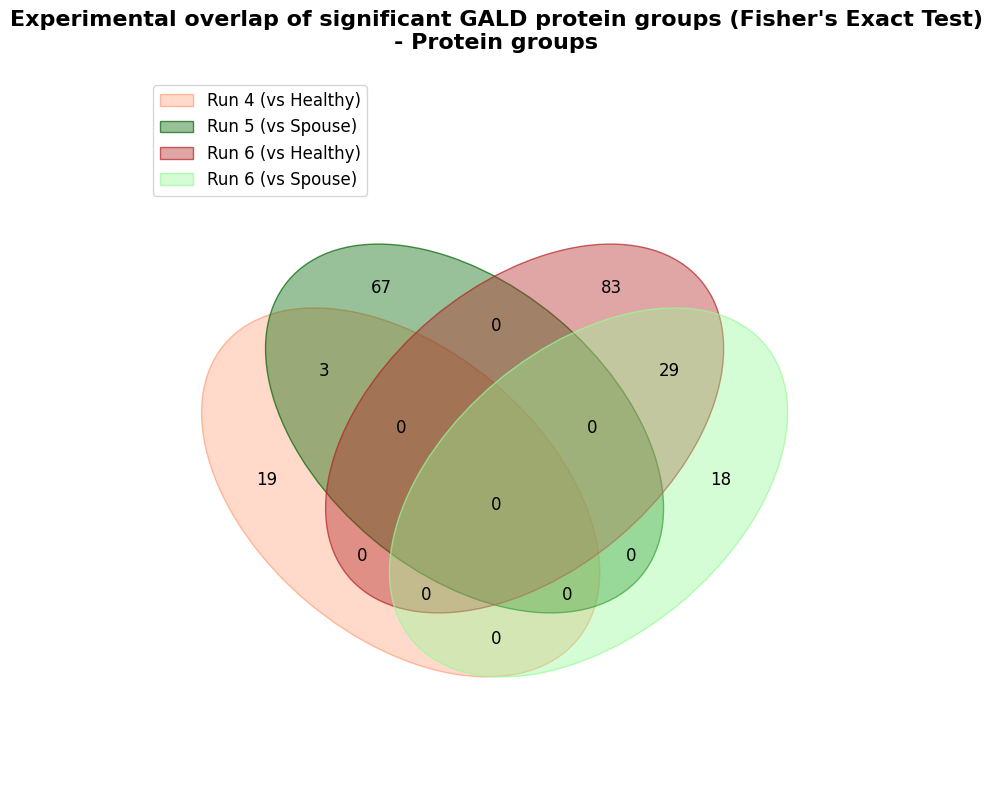


🔥 CORE OVERLAP (Found in all 4 filters): 0 proteins


In [14]:
#Venn diagram of all 4 experiments:
import matplotlib.pyplot as plt
from venn import venn

print("--- Generating 4-Way Venn Diagram (Custom Colors) ---")

# ==========================================
# 1. EXTRACT EXCLUSIVE SETS
# ==========================================
# Run 4: GALD vs Healthy
if "Run 4 (Protein) - vs Healthy" in exclusive_results:
    r4_vs_healthy = set(exclusive_results["Run 4 (Protein) - vs Healthy"]['Protein Group'].dropna())
else:
    r4_vs_healthy = set()

# Run 5: GALD vs Spouse
if "Run 5 (Protein) - vs Spouse" in exclusive_results:
    r5_vs_spouse = set(exclusive_results["Run 5 (Protein) - vs Spouse"]['Protein Group'].dropna())
else:
    r5_vs_spouse = set()

# Run 6: GALD vs Healthy
if "Run 6 (Protein) - vs Healthy" in exclusive_results:
    r6_vs_healthy = set(exclusive_results["Run 6 (Protein) - vs Healthy"]['Protein Group'].dropna())
else:
    r6_vs_healthy = set()

# Run 6: GALD vs Spouse
if "Run 6 (Protein) - vs Spouse" in exclusive_results:
    r6_vs_spouse = set(exclusive_results["Run 6 (Protein) - vs Spouse"]['Protein Group'].dropna())
else:
    r6_vs_spouse = set()

print(f"Run 4 (vs Healthy):  {len(r4_vs_healthy)} targets")
print(f"Run 5 (vs Spouse):   {len(r5_vs_spouse)} targets")
print(f"Run 6 (vs Healthy):  {len(r6_vs_healthy)} targets")
print(f"Run 6 (vs Spouse):   {len(r6_vs_spouse)} targets")

# ==========================================
# 2. FORMAT DATA FOR PYVENN
# ==========================================
# Pyvenn takes a dictionary where the Key is the label and the Value is the set
venn_dict = {
    "Run 4 (vs Healthy)": r4_vs_healthy,
    "Run 5 (vs Spouse)": r5_vs_spouse,
    "Run 6 (vs Healthy)": r6_vs_healthy,
    "Run 6 (vs Spouse)": r6_vs_spouse
}

# ==========================================
# 3. PLOT THE VENN DIAGRAM
# ==========================================
plt.figure(figsize=(10, 10))

# Custom Color Palette
# Order strictly matches the dictionary above: [R4-Healthy, R5-Spouse, R6-Healthy, R6-Spouse]
# We use light red/green for the older runs, and dark red/green for Run 6 to visually separate them.
custom_colors = ['lightsalmon', 'darkgreen', 'firebrick', 'palegreen']

# Generate the plot using the custom colors
venn(
    venn_dict, 
    cmap=custom_colors, 
    fmt="{size}", 
    fontsize=12, 
    legend_loc="upper left"
)

plt.title("Experimental overlap of significant GALD protein groups (Fisher's Exact Test)\n- Protein groups", 
          fontsize=16, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PRINT THE ULTIMATE CORE OVERLAP
# ==========================================
core_antigens = r4_vs_healthy & r5_vs_spouse & r6_vs_healthy & r6_vs_spouse

print("\n=====================================================")
print(f"🔥 CORE OVERLAP (Found in all 4 filters): {len(core_antigens)} proteins")
print("=====================================================")

if len(core_antigens) > 0:
    for target in core_antigens:
        # Pull description safely from Run 6
        try:
            desc = master_prot_run6_maxQuant_df[master_prot_run6_maxQuant_df['Protein Group'] == target]['Protein Description'].iloc[0]
        except IndexError:
            desc = "Description not found in Run 6 dataframe"
            
        print(f"Protein Group: {target}")
        print(f"Description:   {desc}\n")



--- Generating 4-Way Venn Diagram (Individual Proteins) ---
Run 4 (vs Healthy) distinct proteins:  118
Run 5 (vs Spouse) distinct proteins:   387
Run 6 (vs Healthy) distinct proteins:  559
Run 6 (vs Spouse) distinct proteins:   190


<Figure size 1000x1000 with 0 Axes>

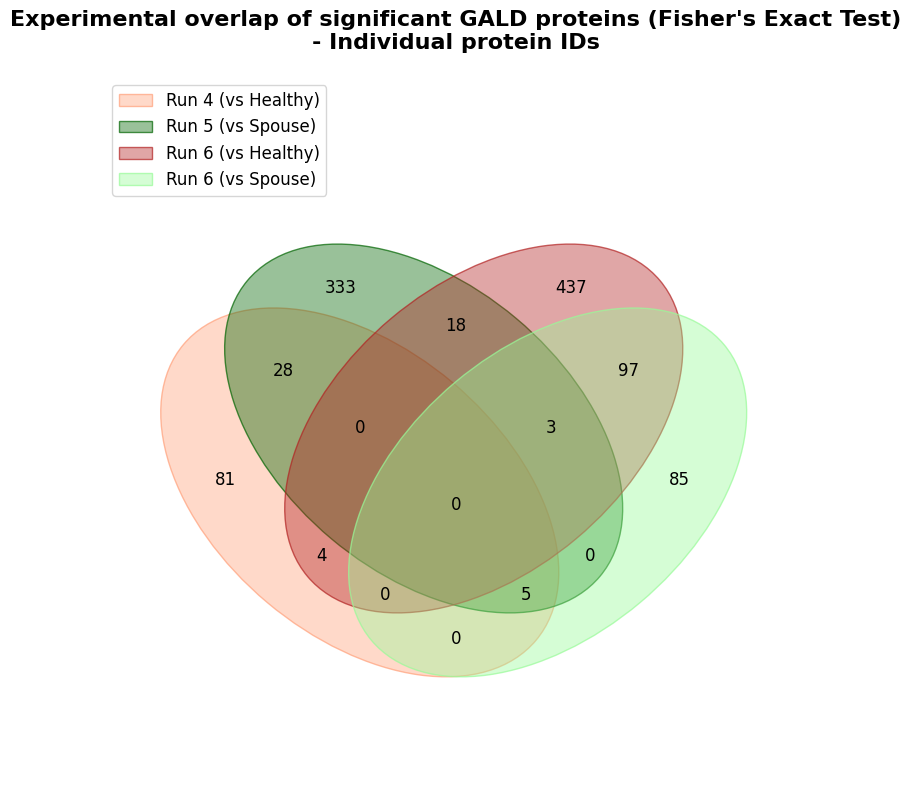


🔥 CORE OVERLAP (Found in all 4 filters): 0 individual proteins


In [15]:
#Venn diagram between 4 experiments when you split up the proteins in the protein groups:
#Individual protein IDs instead of protein groups. 

import pandas as pd
import matplotlib.pyplot as plt
from venn import venn

print("--- Generating 4-Way Venn Diagram (Individual Proteins) ---")

# ==========================================
# 1. HELPER FUNCTION TO SPLIT GROUPS
# ==========================================
def extract_individual_proteins(protein_group_set):
    """Takes a set of 'Protein_A;Protein_B' strings and returns a set of {'Protein_A', 'Protein_B'}"""
    individual_proteins = set()
    for group in protein_group_set:
        prots = [p.strip() for p in str(group).split(';')]
        individual_proteins.update(prots)
    return individual_proteins

# ==========================================
# 2. EXTRACT ORIGINAL EXCLUSIVE SETS
# ==========================================
r4_vs_healthy_raw = set(exclusive_results.get("Run 4 (Protein) - vs Healthy", pd.DataFrame())['Protein Group'].dropna() if "Run 4 (Protein) - vs Healthy" in exclusive_results else [])
r5_vs_spouse_raw = set(exclusive_results.get("Run 5 (Protein) - vs Spouse", pd.DataFrame())['Protein Group'].dropna() if "Run 5 (Protein) - vs Spouse" in exclusive_results else [])
r6_vs_healthy_raw = set(exclusive_results.get("Run 6 (Protein) - vs Healthy", pd.DataFrame())['Protein Group'].dropna() if "Run 6 (Protein) - vs Healthy" in exclusive_results else [])
r6_vs_spouse_raw = set(exclusive_results.get("Run 6 (Protein) - vs Spouse", pd.DataFrame())['Protein Group'].dropna() if "Run 6 (Protein) - vs Spouse" in exclusive_results else [])

# ==========================================
# 3. CONVERT TO INDIVIDUAL PROTEINS
# ==========================================
r4_vs_healthy = extract_individual_proteins(r4_vs_healthy_raw)
r5_vs_spouse = extract_individual_proteins(r5_vs_spouse_raw)
r6_vs_healthy = extract_individual_proteins(r6_vs_healthy_raw)
r6_vs_spouse = extract_individual_proteins(r6_vs_spouse_raw)

print(f"Run 4 (vs Healthy) distinct proteins:  {len(r4_vs_healthy)}")
print(f"Run 5 (vs Spouse) distinct proteins:   {len(r5_vs_spouse)}")
print(f"Run 6 (vs Healthy) distinct proteins:  {len(r6_vs_healthy)}")
print(f"Run 6 (vs Spouse) distinct proteins:   {len(r6_vs_spouse)}")

# ==========================================
# 4. FORMAT DATA FOR PYVENN
# ==========================================
venn_dict = {
    "Run 4 (vs Healthy)": r4_vs_healthy,
    "Run 5 (vs Spouse)": r5_vs_spouse,
    "Run 6 (vs Healthy)": r6_vs_healthy,
    "Run 6 (vs Spouse)": r6_vs_spouse
}

# ==========================================
# 5. PLOT THE VENN DIAGRAM
# ==========================================
plt.figure(figsize=(10, 10))

# Your custom colors!
custom_colors = ['lightsalmon', 'darkgreen', 'firebrick', 'palegreen']

venn(
    venn_dict, 
    cmap=custom_colors, 
    fmt="{size}", 
    fontsize=12, 
    legend_loc="upper left"
)


plt.title("Experimental overlap of significant GALD proteins (Fisher's Exact Test)\n- Individual protein IDs", 
          fontsize=16, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# ==========================================
# 6. PRINT THE ULTIMATE CORE OVERLAP
# ==========================================
core_antigens = r4_vs_healthy & r5_vs_spouse & r6_vs_healthy & r6_vs_spouse

print("\n=====================================================")
print(f"🔥 CORE OVERLAP (Found in all 4 filters): {len(core_antigens)} individual proteins")
print("=====================================================")

if len(core_antigens) > 0:
    for target in core_antigens:
        # Trace the individual ID back to the Run 6 dataframe to get the description
        match = master_prot_run6_maxQuant_df[master_prot_run6_maxQuant_df['Protein Group'].str.contains(target, regex=False, na=False)]
        
        if not match.empty:
            desc = match['Protein Description'].iloc[0]
            original_group = match['Protein Group'].iloc[0]
            print(f"🎯 Individual Hit: {target}")
            print(f"   Run 6 Group:    {original_group}")
            print(f"   Description:    {desc}\n")
        else:
            print(f"🎯 Individual Hit: {target} (Found in Run 4/5, but description missing in Run 6 dataframe)\n")


In [16]:
#Further inspecting the overlapping results:

venn_dict = {
    "Run 4 (vs Healthy)": r4_vs_healthy,
    "Run 5 (vs Spouse)": r5_vs_spouse,
    "Run 6 (vs Healthy)": r6_vs_healthy,
    "Run 6 (vs Spouse)": r6_vs_spouse
}

#Healthy overlap: 
print("Healthy overlap:",r6_vs_healthy & r4_vs_healthy)

#Spouse overlap: 
print("Spouse overlap:",r6_vs_spouse & r5_vs_spouse)

#Run 6 (spouse) and run 5 (spouse) and run 4 (healthy) overlap:
print("Run 4,5,6 (spouse) overlap:",r6_vs_spouse & r4_vs_healthy & r5_vs_spouse)

#Run 5 (spouse) and run 6 (healthy) and run 6 (spouse) overlap:
print("Run 5 and 6 overlap:",r6_vs_spouse & r6_vs_healthy & r5_vs_spouse)


Healthy overlap: {'Q3LXA3', 'Q3LXA3-2', 'I3L252', 'H0YCY6'}
Spouse overlap: {'P63208', 'E5RJR5', 'D6RE86', 'H7C5R1', 'P00450', 'H7C5N5', 'E5RI56', 'E9PFZ2'}
Run 4,5,6 (spouse) overlap: {'D6RE86', 'H7C5R1', 'P00450', 'H7C5N5', 'E9PFZ2'}
Run 5 and 6 overlap: {'P63208', 'E5RJR5', 'E5RI56'}


**Note:** <br>
Run 4,5,6 (spouse) overlap: {'H7C5R1', 'P00450', 'D6RE86', 'E9PFZ2', 'H7C5N5'} <br>
These proteins are **CP**, i.e. Ceruloplasmin, the ferroxidase

E5RJR5, E5RI56, P63208 map to **SKP1**

In [17]:
#Why was CP not detected in run 6 (healthy)? 
all_results.get('Run 6 (Protein) - vs Healthy')[all_results.get('Run 6 (Protein) - vs Healthy')["Gene"] == "CP"]


,Protein Group,Protein Description,Gene,GALD_Detect_Count,GALD_Mean_Int,Healthy donor_Detect_Count,Healthy donor_Mean_Int,GALD_Freq_%,Healthy donor_Freq_%,Freq_Difference,Fisher_P_Value,FDR_Q_Value
830,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,CP,11.0,16834.229091,7.0,631.412857,78.571429,46.666667,31.904762,0.082122,1.0


p value of 0.08 is close to the threshold of p < 0.05 

In [18]:
#Why was SKP1 not detected in run 4 (healthy)? 
display( all_results.get('Run 4 (Protein) - vs Healthy')[all_results.get('Run 4 (Protein) - vs Healthy')["Gene"] == "SKP1"] )


,Protein Group,Protein Description,Gene,GALD_Detect_Count,GALD_Mean_Int,Healthy donor_Detect_Count,Healthy donor_Mean_Int,GALD_Freq_%,Healthy donor_Freq_%,Freq_Difference,Fisher_P_Value,FDR_Q_Value


In [19]:
#Why was SKP1 not detected in run 4 (healthy)? 
#Part 2

pattern = r'E5RJR5|E5RI56|P63208'
filtered_df = master_prot_run4_maxQuant_df[master_prot_run4_maxQuant_df['Protein Group'].str.contains(pattern)]
filtered_df

,Protein,Protein Group,Gene,Protein Description,Protein Name,Score,Q-value,Sample_Col,Razor Intensity,Sample,Group,Sample_type


SKP1 was completely absent in Run 4. 

The fact that CP might be the GALD antigen is really interesting and the enzyme function links well with the GALD pathology. <br>
Let us check if CP was also in any of the Lysate Buffer samples - in that case it would have been transfered as contaminants/ antigens already bound to circulating maternal CP. 

**Checking negative control samples (lysate buffer)**

In [20]:
#How abundant is CP in Lysate buffer (negativ control) samples - ideally it should not be in the negativ control samples

import pandas as pd

print("--- Counting CP (P00450) in Lysate Buffer Samples ---")

# 1. Isolate the Lysate buffer samples (Your code)
LB_prot_run6_df = master_prot_run6_maxQuant_df_LB[master_prot_run6_maxQuant_df_LB["Sample_type"] == "Lysate buffer"].copy()

# 2. Determine total number of unique Lysate buffer runs
total_lb_samples = LB_prot_run6_df["Sample"].nunique()
print(f"Total Lysate Buffer Samples analyzed: {total_lb_samples}")

# 3. Filter for Ceruloplasmin (Target ID: P00450)
target_id = "P00450"
cp_df = LB_prot_run6_df[LB_prot_run6_df['Protein Group'].str.contains(target_id, regex=True, na=False)].copy()

# 4. Count detections
cp_detected_count = cp_df["Sample"].nunique()

# 5. Calculate frequency percentage
if total_lb_samples > 0:
    frequency = (cp_detected_count / total_lb_samples) * 100
else:
    frequency = 0

print(f"CP Detected in: {cp_detected_count} out of {total_lb_samples} LB samples ({frequency:.1f}%)")

# 6. Display the exact breakdown if detected
if cp_detected_count > 0:
    print("\n--- Intensity Breakdown by Sample ---")
    # Sort nicely for display
    display_df = cp_df[['Sample', 'Protein Group', 'Protein Description', 'Razor Intensity', "Group"]].sort_values(by='Sample').reset_index(drop=True)
    display(display_df)
else:
    print("\n✅ Clean Background: CP was completely absent from all Lysate buffer samples!")


--- Counting CP (P00450) in Lysate Buffer Samples ---
Total Lysate Buffer Samples analyzed: 41
CP Detected in: 17 out of 41 LB samples (41.5%)

--- Intensity Breakdown by Sample ---


,Sample,Protein Group,Protein Description,Razor Intensity,Group
0,sample_45,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,37667.00,GALD
1,sample_47,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,2433900.00,GALD
2,sample_48,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,28922.00,GALD
3,sample_49,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,476.04,GALD
4,sample_50,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,77460.00,GALD
5,sample_52,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,1163.20,GALD
6,sample_53,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,5053.80,GALD
7,sample_54,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,7207.30,GALD
8,sample_55,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,1126.90,GALD
9,sample_57,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,1965.60,GALD


In [21]:
#How abundant is SKP1 in Lysate buffer (negativ control) samples - ideally it should not be in the negativ control samples

import pandas as pd

print("--- Counting SKP1 in Lysate Buffer Samples ---")

# 1. Isolate the Lysate buffer samples
LB_prot_run6_df = master_prot_run6_maxQuant_df_LB[master_prot_run6_maxQuant_df_LB["Sample_type"] == "Lysate buffer"].copy()

# 2. Determine total number of unique Lysate buffer runs
total_lb_samples = LB_prot_run6_df["Sample"].nunique()
print(f"Total Lysate Buffer Samples analyzed: {total_lb_samples}")

# 3. Filter for protein
target_id = "P63208" #SKP1 = P63208
#E5RJR5, E5RI56, P63208

target_df = LB_prot_run6_df[LB_prot_run6_df['Protein Group'].str.contains(target_id, regex=True, na=False)].copy()

# 4. Count detections
target_detected_count = target_df["Sample"].nunique()

# 5. Calculate frequency percentage
if total_lb_samples > 0:
    frequency = (target_detected_count / total_lb_samples) * 100
else:
    frequency = 0

print(f"Target protein detected in: {target_detected_count} out of {total_lb_samples} LB samples ({frequency:.1f}%)")

# 6. Display the exact breakdown if detected
if target_detected_count > 0:
    print("\n--- Intensity Breakdown by Sample ---")
    # Sort nicely for display
    display_df = target_df[['Sample', 'Protein Group', 'Protein Description', 'Razor Intensity', "Group"]].sort_values(by='Sample').reset_index(drop=True)
    display(display_df)
else:
    print("\n✅ Clean Background: Target protein was completely absent from all Lysate buffer samples!")



--- Counting SKP1 in Lysate Buffer Samples ---
Total Lysate Buffer Samples analyzed: 41
Target protein detected in: 0 out of 41 LB samples (0.0%)

✅ Clean Background: Target protein was completely absent from all Lysate buffer samples!


**Note**: SKP1 was completely absent from negative controls. Whereas CP was seemingly pretty common in the GALD mother samples for the negative controls... 

In [22]:
#Fisher's Exact Test - On negative controls
#For CP

#Is CP more present in LB GALD samples than LB control samples

import pandas as pd
from scipy.stats import fisher_exact

#Ceruloplasmin (CP / Target ID: P00450
target_id = "P00450"
print(f"--- Fisher's Exact Test: Background CP ({target_id}) in Lysate Buffer ---")

# ==========================================
# 1. GET TOTAL SAMPLES PER GROUP (LB ONLY)
# ==========================================
# We use the raw LB dataframe to count the true denominator (even if CP isn't in them)
LB_raw = master_prot_run6_maxQuant_df_LB[master_prot_run6_maxQuant_df_LB["Sample_type"] == "Lysate buffer"]

total_gald = LB_raw[LB_raw["Group"] == "GALD"]["Sample"].nunique()
total_health = LB_raw[LB_raw["Group"] == "Healthy donor"]["Sample"].nunique()
total_spouse = LB_raw[LB_raw["Group"] == "GALD_spouse"]["Sample"].nunique()

# ==========================================
# 2. COUNT CP DETECTIONS (PRESENT)
# ==========================================
cp_df = LB_prot_run6_df[LB_prot_run6_df['Protein Group'].str.contains(target_id, regex=True, na=False)]

gald_present = cp_df[cp_df["Group"] == "GALD"]["Sample"].nunique()
health_present = cp_df[cp_df["Group"] == "Healthy donor"]["Sample"].nunique()
spouse_present = cp_df[cp_df["Group"] == "GALD_spouse"]["Sample"].nunique()

# ==========================================
# 3. CALCULATE ABSENCES
# ==========================================
gald_absent = total_gald - gald_present
health_absent = total_health - health_present
spouse_absent = total_spouse - spouse_present

# ==========================================
# 4. RUN FISHER'S EXACT TESTS
# ==========================================
# Test 1: GALD vs Healthy
table_health = [[gald_present, gald_absent], [health_present, health_absent]]
_, p_health = fisher_exact(table_health, alternative='greater')

# Test 2: GALD vs Spouse
table_spouse = [[gald_present, gald_absent], [spouse_present, spouse_absent]]
_, p_spouse = fisher_exact(table_spouse, alternative='greater')

# ==========================================
# 5. PRINT RESULTS
# ==========================================
print("\n[ Contingency Tables ]")
print(f"GALD:    {gald_present} Present, {gald_absent} Absent (Total: {total_gald})")
print(f"Healthy: {health_present} Present, {health_absent} Absent (Total: {total_health})")
print(f"Spouse:  {spouse_present} Present, {spouse_absent} Absent (Total: {total_spouse})")

print("\n[ Statistical Significance ]")
print(f"GALD vs Healthy P-value: {p_health:.4f}")
print(f"GALD vs Spouse P-value:  {p_spouse:.4f}")

if p_health < 0.05 or p_spouse < 0.05:
    print("\n⚠️ WARNING: CP is significantly enriched in the GALD Lysate Buffers!")
    print("This indicates a severe batch effect or washing inconsistency in the GALD prep.")
else:
    print("\n✅ CLEAN: There is no statistically significant difference in background CP levels across the cohorts.")


--- Fisher's Exact Test: Background CP (P00450) in Lysate Buffer ---

[ Contingency Tables ]
GALD:    10 Present, 4 Absent (Total: 14)
Healthy: 3 Present, 12 Absent (Total: 15)
Spouse:  4 Present, 8 Absent (Total: 12)

[ Statistical Significance ]
GALD vs Healthy P-value: 0.0073
GALD vs Spouse P-value:  0.0602

⚠️ WARNING: CP is significantly enriched in the GALD Lysate Buffers!
This indicates a severe batch effect or washing inconsistency in the GALD prep.


In [23]:
#Checking whether any of the Lysate buffer protein groups are more present in GALD than control samples
#Fisher's Exact Test

#(!) ALL (!) proteins in the negative control


import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

print("--- Global Quality Control: Lysate Buffer Batch Effects ---")

# ==========================================
# 1. ISOLATE LYSATE BUFFER DATA
# ==========================================
LB_df = master_prot_run6_maxQuant_df_LB[master_prot_run6_maxQuant_df_LB["Sample_type"] == "Lysate buffer"].copy()

# Get total sample counts for the denominators
total_gald = LB_df[LB_df["Group"] == "GALD"]["Sample"].nunique()
total_health = LB_df[LB_df["Group"] == "Healthy donor"]["Sample"].nunique()
total_spouse = LB_df[LB_df["Group"] == "GALD_spouse"]["Sample"].nunique()

print(f"Lysate Buffers Analyzed: GALD ({total_gald}), Healthy ({total_health}), Spouse ({total_spouse})")

if total_gald == 0 or total_health == 0 or total_spouse == 0:
    print("Error: Missing Lysate Buffer samples for one or more cohorts.")
else:
    # ==========================================
    # 2. COUNT DETECTIONS PER PROTEIN
    # ==========================================
    # Group by Protein Group to get the descriptive text
    qc_df = LB_df.groupby('Protein Group', as_index=False).agg({
        'Protein Description': 'first'
    })
    
    # Count occurrences in each group
    gald_counts = LB_df[LB_df["Group"] == "GALD"].groupby('Protein Group')['Sample'].nunique().reset_index(name='GALD_Present')
    health_counts = LB_df[LB_df["Group"] == "Healthy donor"].groupby('Protein Group')['Sample'].nunique().reset_index(name='Health_Present')
    spouse_counts = LB_df[LB_df["Group"] == "GALD_spouse"].groupby('Protein Group')['Sample'].nunique().reset_index(name='Spouse_Present')
    
    # Merge counts back into the main QC dataframe
    qc_df = qc_df.merge(gald_counts, on='Protein Group', how='left')
    qc_df = qc_df.merge(health_counts, on='Protein Group', how='left')
    qc_df = qc_df.merge(spouse_counts, on='Protein Group', how='left')
    
    # Fill missing values with 0
    qc_df.fillna({'GALD_Present': 0, 'Health_Present': 0, 'Spouse_Present': 0}, inplace=True)
    
    # ==========================================
    # 3. RUN TWO-SIDED FISHER'S EXACT TESTS
    # ==========================================
    def run_qc_fisher(row, present_col, total_samples):
        gald_present = int(row['GALD_Present'])
        gald_absent = total_gald - gald_present
        
        comp_present = int(row[present_col])
        comp_absent = total_samples - comp_present
        
        table = [[gald_present, gald_absent], [comp_present, comp_absent]]
        
        # 'two-sided' checks for ANY significant imbalance (either GALD > Comp OR Comp > GALD)
        _, p_val = fisher_exact(table, alternative='two-sided')
        return p_val

    # Test GALD vs Healthy
    qc_df['P_Val_vs_Health'] = qc_df.apply(lambda row: run_qc_fisher(row, 'Health_Present', total_health), axis=1)
    
    # Test GALD vs Spouse
    qc_df['P_Val_vs_Spouse'] = qc_df.apply(lambda row: run_qc_fisher(row, 'Spouse_Present', total_spouse), axis=1)
    
    # ==========================================
    # 4. FILTER FOR SIGNIFICANT BATCH EFFECTS
    # ==========================================
    # Flag anything with a p-value < 0.05 in either comparison
    suspicious_mask = (qc_df['P_Val_vs_Health'] < 0.05) | (qc_df['P_Val_vs_Spouse'] < 0.05)
    suspicious_proteins = qc_df[suspicious_mask].sort_values(by=['P_Val_vs_Health', 'P_Val_vs_Spouse'])
    
    # ==========================================
    # 5. DISPLAY RESULTS
    # ==========================================
    print("\n====================================================================")
    print(f"🚨 FLAG: Found {len(suspicious_proteins)} proteins with significant baseline bias.")
    print("====================================================================")
    
    if len(suspicious_proteins) > 0:
        print("These proteins appear at significantly different frequencies in the negative controls:")
        display(suspicious_proteins.reset_index(drop=True))
    else:
        print("✅ EXCELLENT! The Lysate Buffers are statistically balanced.")
        print("No protein groups showed a significant detection bias between the cohorts.")


--- Global Quality Control: Lysate Buffer Batch Effects ---
Lysate Buffers Analyzed: GALD (14), Healthy (15), Spouse (12)

🚨 FLAG: Found 146 proteins with significant baseline bias.
These proteins appear at significantly different frequencies in the negative controls:


,Protein Group,Protein Description,GALD_Present,Health_Present,Spouse_Present,P_Val_vs_Health,P_Val_vs_Spouse
0,P04040,sp|P04040|CATA_HUMAN Catalase OS=Homo sapiens ...,14.0,1.0,11.0,2.062952e-07,0.461538
1,Q32Q12;P22392-2;J3KPD9;P22392;E7ERL0;E5RHP0;O6...,"tr|Q32Q12|Q32Q12_HUMAN Isoform of P22392, Nucl...",13.0,0.0,11.0,2.062952e-07,1.000000
2,P60174;P60174-3;P60174-4;U3KPZ0;U3KQF3;U3KPS5,sp|P60174|TPIS_HUMAN Triosephosphate isomerase...,13.0,1.0,12.0,2.913920e-06,1.000000
3,P61160;P61160-2;A0A1B0GWD0;A0A1B0GWH0,sp|P61160|ARP2_HUMAN Actin-related protein 2 O...,13.0,1.0,12.0,2.913920e-06,1.000000
4,P10620;F5H7F6;F5H6X2;P10620-2;F5GX73;F5H613;F5...,sp|P10620|MGST1_HUMAN Microsomal glutathione S...,11.0,0.0,2.0,1.052106e-05,0.004832
...,...,...,...,...,...,...,...
141,P02771;J3KMX3;CON__Q3SZ57,sp|P02771|FETA_HUMAN Alpha-fetoprotein OS=Homo...,12.0,7.0,5.0,5.017491e-02,0.037529
142,P49755;G3V2K7,sp|P49755|TMEDA_HUMAN Transmembrane emp24 doma...,5.0,1.0,0.0,8.007663e-02,0.042475
143,A0A075B6I9,sp|A0A075B6I9|LV746_HUMAN Immunoglobulin lambd...,6.0,3.0,0.0,2.450775e-01,0.017057
144,P27338;P27338-2,sp|P27338|AOFB_HUMAN Amine oxidase [flavin-con...,7.0,4.0,0.0,2.635419e-01,0.006421


In [24]:
#Fisher's Exact Test on CP in Lysate Buffer: 
suspicious_proteins[suspicious_proteins["Protein Group"].str.contains("P00450")] 

,Protein Group,Protein Description,GALD_Present,Health_Present,Spouse_Present,P_Val_vs_Health,P_Val_vs_Spouse
264,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,10.0,3.0,4.0,0.009221,0.113144


In [25]:
#All protein groups found significantly more frequent in GALD negative controls relative to other negative controls: 
for i, protein_group in enumerate(suspicious_proteins["Protein Group"]): 
    print(f"{i+1})", protein_group) 

1) P04040
2) Q32Q12;P22392-2;J3KPD9;P22392;E7ERL0;E5RHP0;O60361;F6XY72;C9K028
3) P60174;P60174-3;P60174-4;U3KPZ0;U3KQF3;U3KPS5
4) P61160;P61160-2;A0A1B0GWD0;A0A1B0GWH0
5) P10620;F5H7F6;F5H6X2;P10620-2;F5GX73;F5H613;F5H760
6) A0A1W2PNV4;E9PF58;F8WFD3
7) O15143;C9JEY1;C9K057;F8VXW2;C9JBJ7;C9JTT6;C9JM51
8) P05062;A0A3B3IS80;A0A3B3ITZ0
9) Q9Y490;Q9Y490-2;Q9Y4G6;H0YMT1;A0A1B0GVU7
10) A0A8V8TNZ5;A0A8V8TQC0;P84077;P61204;A0A8V8TNZ0;A0A8V8TQP8;F5H423;F5H0C7;A0A8V8TP92;A0A8V8TP99;P61204-2;H0YGG7
11) P49773
12) Q14376;Q5QPP4;Q5QPP3;Q14376-2;Q5QPP1;Q5QPP9
13) F8WCF6;P59998;P59998-3;H7C0A3;R4GN08;P59998-4
14) O15144;C9JTV5;G5E9J0;H7C3F9;G5E9S7
15) P37802;P37802-2;X6RJP6;C9J5W6;Q9UI15
16) A0A8V8TME2;A0A8V8TP41;Q86UX7-2;Q86UX7;A0A8V8TNT4;A0A8V8TMD7;F5H3I6;A0A8V8TMU1;A0A8V8TMT4;A0A8V8TMB3;F5H1C6;A0A8V8TP46;H0YFT5;A0A8V8TNT9;A0A8V8TMS8;A0A8V8TMT7
17) P04746;P0DUB6;P0DTE8;P0DTE7;P19961;P19961-2;P04746-2;A0A804HHZ3;CON__Q3MHH8;C9JWK7;C9J2Z5;Q5T084;H7BZQ8
18) P61158;B4DXW1;F8WDR7;F8WEW2;F8WE84;Q9P1U1-2;Q

In [26]:
#Bonus
#All peptides from CP - are any peptides prefered

import pandas as pd
from scipy.stats import fisher_exact

print("--- Analyzing Ceruloplasmin (CP) Nested Peptides (Runs 4, 5, 6) ---")

# ==========================================
# 1. COMBINE PEPTIDE DATA ACROSS RUNS
# ==========================================
# Add run prefixes to samples to ensure no accidental overlap between batches
df4 = master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Gene"].str.contains("CP", na=False)].copy()
df4['Sample_ID'] = 'R4_' + df4['Sample']

df5 = master_pep_run5_maxQuant_df[master_pep_run5_maxQuant_df["Gene"].str.contains("CP", na=False)].copy()
df5['Sample_ID'] = 'R5_' + df5['Sample']

df6 = master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Gene"].str.contains("CP", na=False)].copy()
df6['Sample_ID'] = 'R6_' + df6['Sample']

# Combine into one master dataframe
cp_all = pd.concat([df4, df5, df6], ignore_index=True)

# Unify target groups (GALD vs Unified Controls for maximum statistical power)
cp_all['Binary_Target'] = cp_all['Group'].apply(lambda x: 'GALD' if x == 'GALD' else 'Control')

# Total samples analyzed across all runs (need this for Fisher's test denominators)
# We must calculate this from the MAIN dataframes to include samples where CP was entirely absent
total_gald = (master_prot_run4_maxQuant_df[master_prot_run4_maxQuant_df['Group'] == 'GALD']['Sample'].nunique() + 
              master_prot_run5_maxQuant_df[master_prot_run5_maxQuant_df['Group'] == 'GALD']['Sample'].nunique() + 
              master_prot_run6_maxQuant_df[master_prot_run6_maxQuant_df['Group'] == 'GALD']['Sample'].nunique())

total_control = (master_prot_run4_maxQuant_df[master_prot_run4_maxQuant_df['Group'] != 'GALD']['Sample'].nunique() + 
                 master_prot_run5_maxQuant_df[master_prot_run5_maxQuant_df['Group'] != 'GALD']['Sample'].nunique() + 
                 master_prot_run6_maxQuant_df[master_prot_run6_maxQuant_df['Group'] != 'GALD']['Sample'].nunique())

print(f"Total Cohort Size: {total_gald} GALD Samples | {total_control} Control Samples")

# ==========================================
# 2. THE NESTED PEPTIDE GROUPING ALGORITHM
# ==========================================
# Get all unique peptide sequences detected
unique_peptides = cp_all['Peptide Sequence'].dropna().unique()

# Sort by length descending (longest peptides first)
unique_peptides = sorted(unique_peptides, key=len, reverse=True)

# Dictionary to hold { 'Master_Sequence': ['sub_seq1', 'sub_seq2'] }
peptide_families = {}
peptide_mapping = {}

for pep in unique_peptides:
    placed = False
    for master in peptide_families.keys():
        # If this shorter peptide is found perfectly inside a longer master peptide
        if pep in master:
            peptide_families[master].append(pep)
            peptide_mapping[pep] = master
            placed = True
            break
            
    # If it fits inside nothing, it becomes a new Master sequence
    if not placed:
        peptide_families[pep] = [pep]
        peptide_mapping[pep] = pep

# Apply the mapping to the dataframe
cp_all['Master_Sequence'] = cp_all['Peptide Sequence'].map(peptide_mapping)

print(f"Collapsed {len(unique_peptides)} raw peptides into {len(peptide_families)} Master Families.\n")

# ==========================================
# 3. COUNT DETECTIONS & FISHER'S EXACT TEST
# ==========================================
results = []

for master_seq, family in peptide_families.items():
    # Isolate data for this specific family
    family_df = cp_all[cp_all['Master_Sequence'] == master_seq]
    
    # Count UNIQUE samples that have at least one peptide from this family
    gald_present = family_df[family_df['Binary_Target'] == 'GALD']['Sample_ID'].nunique()
    control_present = family_df[family_df['Binary_Target'] == 'Control']['Sample_ID'].nunique()
    
    gald_absent = total_gald - gald_present
    control_absent = total_control - control_present
    
    # Fisher's Exact Test (Looking for enrichment in GALD)
    table = [[gald_present, gald_absent], [control_present, control_absent]]
    _, p_val = fisher_exact(table, alternative='greater')
    
    # Calculate Frequencies
    gald_freq = (gald_present / total_gald) * 100 if total_gald > 0 else 0
    ctrl_freq = (control_present / total_control) * 100 if total_control > 0 else 0
    
    results.append({
        'Master Peptide Sequence': master_seq,
        'Variants Detected': len(family),
        'GALD Detections': f"{gald_present}/{total_gald} ({gald_freq:.1f}%)",
        'Control Detections': f"{control_present}/{total_control} ({ctrl_freq:.1f}%)",
        'Fisher_P_Value': p_val
    })

# ==========================================
# 4. DISPLAY RESULTS
# ==========================================
results_df = pd.DataFrame(results).sort_values(by='Fisher_P_Value', ascending=True)

print("====================================================================")
print("🔍 TOP ENRICHED CERULOPLASMIN PEPTIDE REGIONS (GALD vs Controls) 🔍")
print("====================================================================")
display(results_df.head(15).reset_index(drop=True))

# Optional: Print the exact sub-peptides that make up the top hit to see the ragged ends
top_master = results_df.iloc[0]['Master Peptide Sequence']
print(f"\nSub-peptides grouped under the top hit ({top_master}):")
print(peptide_families[top_master])

--- Analyzing Ceruloplasmin (CP) Nested Peptides (Runs 4, 5, 6) ---
Total Cohort Size: 42 GALD Samples | 54 Control Samples
Collapsed 493 raw peptides into 355 Master Families.

🔍 TOP ENRICHED CERULOPLASMIN PEPTIDE REGIONS (GALD vs Controls) 🔍


,Master Peptide Sequence,Variants Detected,GALD Detections,Control Detections,Fisher_P_Value
0,TYCSEPEKVDKDNEDFQESNR,1,16/42 (38.1%),0/54 (0.0%),2.514295e-07
1,KLISVDTEHSNIYLQNGPDR,2,17/42 (40.5%),2/54 (3.7%),6.838087e-06
2,MFTTAPDQVDKEDEDFQESNK,1,14/42 (33.3%),1/54 (1.9%),2.257478e-05
3,DITDTLVAVTISEGAHHLDLR,1,11/42 (26.2%),0/54 (0.0%),4.853876e-05
4,TYSDHPEKVNKDDEEFIESNK,2,13/42 (31.0%),2/54 (3.7%),3.017266e-04
5,ERGPEEEHLGILGPVIWAEVGDTIR,1,11/42 (26.2%),1/54 (1.9%),3.877391e-04
6,KAEEEHLGILGPQLHADVGDKVK,3,18/42 (42.9%),6/54 (11.1%),4.108742e-04
7,TLETANCMSSQTK,1,22/42 (52.4%),10/54 (18.5%),5.080194e-04
8,FNKNNEGTYYSPNYNPQSR,2,26/42 (61.9%),15/54 (27.8%),7.836695e-04
9,ACIENGASCIDISGEPQFLELMQLK,1,14/42 (33.3%),6/54 (11.1%),8.033897e-03



Sub-peptides grouped under the top hit (TYCSEPEKVDKDNEDFQESNR):
['TYCSEPEKVDKDNEDFQESNR']


In [27]:
#Peptide counts of CP (from Run 6) - needs to pull it from the more raw MaxQuant output data: 
prot_df[prot_df["Gene names"] == "CP"] 
#Peptide count varries between 44 and 4 between the five protein IDs. The major ones are P00450;E9PFZ2;H7C5R1. 


#Bonus note - if only 1 peptide is detected, the intensity will be set to 0: 

#Unique peptides 73_S2-G1_1_10451 = 2
#Unique peptides 74_S2-G2_1_10452 = 1

#LFQ intensity 72_S2-F12_1_10450 = 0.0
#LFQ intensity 73_S2-G1_1_10451 = 1408.5


,Protein IDs,Majority protein IDs,Peptide counts (all),Peptide counts (razor+unique),Peptide counts (unique),Protein names,Gene names,Fasta headers,Number of proteins,Peptides,Razor + unique peptides,Unique peptides,Peptides 01_S2-A1_1_10366,Peptides 02_S2-A2_1_10367,Peptides 03_S2-A3_1_10368,Peptides 04_S2-A4_1_10369,Peptides 05_S2-A5_1_10370,Peptides 06_S2-A6_1_10371,Peptides 07_S2-A7_1_10372,Peptides 08_S2-A8_1_10373,Peptides 09_S2-A9_1_10374,Peptides 10_S2-A10_1_10375,Peptides 11_S2-A11_1_10376,Peptides 12_S2-A12_1_10377,Peptides 13_S2-B1_1_10378,Peptides 14_S2-B2_1_10379,Peptides 15_S2-B3_1_10380,Peptides 16_S2-B4_1_10383,Peptides 17_S2-B5_1_10384,Peptides 18_S2-B6_1_10385,Peptides 19_S2-B7_1_10386,Peptides 20_S2-B8_1_10387,Peptides 21_S2-B9_1_10388,Peptides 22_S2-B10_1_10389,Peptides 23_S2-B11_1_10390,Peptides 24_S2-B12_1_10391,Peptides 25_S2-C1_1_10392,Peptides 26_S2-C2_1_10393,Peptides 27_S2-C3_1_10394,Peptides 28_S2-C4_1_10397,Peptides 29_S2-C5_1_10398,Peptides 30_S2-C6_1_10399,Peptides 31_S2-C7_1_10400,Peptides 32_S2-C8_1_10401,Peptides 33_S2-C9_1_10402,Peptides 34_S2-C10_1_10403,Peptides 35_S2-C11_1_10404,Peptides 36_S2-C12_1_10405,Peptides 37_S2-D1_1_10406,Peptides 38_S2-D2_1_10407,Peptides 39_S2-D3_1_10408,Peptides 40_S2-D4_1_10409,Peptides 41_S2-D5_1_10410,Peptides 42_S2-D6_1_10411,Peptides 43_S2-D7_1_10417,Peptides 44_S2-D8_1_10418,Peptides 45_S2-D9_1_10419,Peptides 46_S2-D10_1_10420,Peptides 47_S2-D11_1_10421,Peptides 48_S2-D12_1_10422,Peptides 49_S2-E1_1_10423,Peptides 50_S2-E2_1_10424,Peptides 51_S2-E3_1_10425,Peptides 52_S2-E4_1_10426,Peptides 53_S2-E5_1_10427,Peptides 54_S2-E6_1_10428,Peptides 55_S2-E7_1_10429,Peptides 56_S2-E8_1_10430,Peptides 57_S2-E9_1_10431,Peptides 58_S2-E10_1_10434,Peptides 59_S2-E11_1_10435,Peptides 60_S2-E12_1_10436,Peptides 61_S2-F1_1_10437,Peptides 62_S2-F2_1_10438,Peptides 63_S2-F3_1_10439,Peptides 64_S2-F4_1_10440,Peptides 65_S2-F5_1_10441,Peptides 66_S2-F6_1_10442,Peptides 67_S2-F7_1_10443,Peptides 68_S2-F8_1_10444,Peptides 69_S2-F9_1_10445,Peptides 70_S2-F10_1_10448,Peptides 71_S2-F11_1_10449,Peptides 72_S2-F12_1_10450,Peptides 73_S2-G1_1_10451,Peptides 74_S2-G2_1_10452,Peptides 75_S2-G3_1_10453,Peptides 76_S2-G4_1_10454,Peptides 77_S2-G5_1_10455,Peptides 78_S2-G6_1_10456,Peptides 79_S2-G7_1_10457,Peptides 80_S2-G8_1_10458,Peptides 81_S2-G9_1_10459,Peptides 82_S2-G10_1_10460,Peptides 83_S2-G11_1_10461,Peptides 84_S2-G12_1_10462,Razor + unique peptides 01_S2-A1_1_10366,Razor + unique peptides 02_S2-A2_1_10367,Razor + unique peptides 03_S2-A3_1_10368,Razor + unique peptides 04_S2-A4_1_10369,Razor + unique peptides 05_S2-A5_1_10370,Razor + unique peptides 06_S2-A6_1_10371,Razor + unique peptides 07_S2-A7_1_10372,Razor + unique peptides 08_S2-A8_1_10373,Razor + unique peptides 09_S2-A9_1_10374,Razor + unique peptides 10_S2-A10_1_10375,Razor + unique peptides 11_S2-A11_1_10376,Razor + unique peptides 12_S2-A12_1_10377,Razor + unique peptides 13_S2-B1_1_10378,Razor + unique peptides 14_S2-B2_1_10379,Razor + unique peptides 15_S2-B3_1_10380,Razor + unique peptides 16_S2-B4_1_10383,Razor + unique peptides 17_S2-B5_1_10384,Razor + unique peptides 18_S2-B6_1_10385,Razor + unique peptides 19_S2-B7_1_10386,Razor + unique peptides 20_S2-B8_1_10387,Razor + unique peptides 21_S2-B9_1_10388,Razor + unique peptides 22_S2-B10_1_10389,Razor + unique peptides 23_S2-B11_1_10390,Razor + unique peptides 24_S2-B12_1_10391,Razor + unique peptides 25_S2-C1_1_10392,Razor + unique peptides 26_S2-C2_1_10393,Razor + unique peptides 27_S2-C3_1_10394,Razor + unique peptides 28_S2-C4_1_10397,Razor + unique peptides 29_S2-C5_1_10398,Razor + unique peptides 30_S2-C6_1_10399,Razor + unique peptides 31_S2-C7_1_10400,Razor + unique peptides 32_S2-C8_1_10401,Razor + unique peptides 33_S2-C9_1_10402,Razor + unique peptides 34_S2-C10_1_10403,Razor + unique peptides 35_S2-C11_1_10404,Razor + unique peptides 36_S2-C12_1_10405,Razor + unique peptides 37_S2-D1_1_10406,Razor + unique peptides 38_S2-D2_1_10407,Razor + uniq

In [28]:
#Peptide count of Run 4, Run 5 and Run 6 for SKP1 and CP: 

#Run 4: 
prot_df = pd.read_csv("/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run4_PRI_MaxQuant_P0249_R0876_X957/txt/proteinGroups.txt", sep='\t')

print("Run 4:")
display( prot_df[prot_df["Gene names"].isin(["CP","SKP1"])] )

#Run 5: 
prot_df = pd.read_csv("/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run5_PRI_MaxQuant_P0249_R1101_X1367/txt/proteinGroups.txt", sep='\t')

print("Run 5:")
display( prot_df[prot_df["Gene names"].isin(["CP","SKP1"])] )

#Run 6: 
prot_df = pd.read_csv("/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run6_PRI_MaxQuant_P0249_R1344_X1882/txt/proteinGroups.txt", sep='\t')

print("Run 6:")
display( prot_df[prot_df["Gene names"].isin(["CP","SKP1"])] )

Run 4:


,Protein IDs,Majority protein IDs,Peptide counts (all),Peptide counts (razor+unique),Peptide counts (unique),Protein names,Gene names,Fasta headers,Number of proteins,Peptides,Razor + unique peptides,Unique peptides,Peptides 1_S3-A1_1_9338,Peptides 10_S3-A10_1_9347,Peptides 11_S3-A11_1_9348,Peptides 12_S3-A12_1_9349,Peptides 13_S3-B1_1_9350,Peptides 14_S3-B2_1_9351,Peptides 15_S3-B3_1_9352,Peptides 16_S3-B4_1_9353,Peptides 17_S3-B5_1_9354,Peptides 18_S3-B6_1_9355,Peptides 19_S3-B7_1_9356,Peptides 2_S3-A2_1_9339,Peptides 20_S3-B8_1_9357,Peptides 21_S3-B9_1_9358,Peptides 22_S3-B10_1_9359,Peptides 23_S3-B11_1_9360,Peptides 24_S3-B12_1_9361,Peptides 25_S3-C1_1_9362,Peptides 26_S3-C2_1_9363,Peptides 27_S3-C3_1_9364,Peptides 28_S3-C4_1_9365,Peptides 29_S3-C5_1_9366,Peptides 3_S3-A3_1_9340,Peptides 30_S3-C6_1_9367,Peptides 4_S3-A4_1_9341,Peptides 5_S3-A5_1_9342,Peptides 6_S3-A6_1_9343,Peptides 7_S3-A7_1_9344,Peptides 8_S3-A8_1_9345,Peptides 9_S3-A9_1_9346,Razor + unique peptides 1_S3-A1_1_9338,Razor + unique peptides 10_S3-A10_1_9347,Razor + unique peptides 11_S3-A11_1_9348,Razor + unique peptides 12_S3-A12_1_9349,Razor + unique peptides 13_S3-B1_1_9350,Razor + unique peptides 14_S3-B2_1_9351,Razor + unique peptides 15_S3-B3_1_9352,Razor + unique peptides 16_S3-B4_1_9353,Razor + unique peptides 17_S3-B5_1_9354,Razor + unique peptides 18_S3-B6_1_9355,Razor + unique peptides 19_S3-B7_1_9356,Razor + unique peptides 2_S3-A2_1_9339,Razor + unique peptides 20_S3-B8_1_9357,Razor + unique peptides 21_S3-B9_1_9358,Razor + unique peptides 22_S3-B10_1_9359,Razor + unique peptides 23_S3-B11_1_9360,Razor + unique peptides 24_S3-B12_1_9361,Razor + unique peptides 25_S3-C1_1_9362,Razor + unique peptides 26_S3-C2_1_9363,Razor + unique peptides 27_S3-C3_1_9364,Razor + unique peptides 28_S3-C4_1_9365,Razor + unique peptides 29_S3-C5_1_9366,Razor + unique peptides 3_S3-A3_1_9340,Razor + unique peptides 30_S3-C6_1_9367,Razor + unique peptides 4_S3-A4_1_9341,Razor + unique peptides 5_S3-A5_1_9342,Razor + unique peptides 6_S3-A6_1_9343,Razor + unique peptides 7_S3-A7_1_9344,Razor + unique peptides 8_S3-A8_1_9345,Razor + unique peptides 9_S3-A9_1_9346,Unique peptides 1_S3-A1_1_9338,Unique peptides 10_S3-A10_1_9347,Unique peptides 11_S3-A11_1_9348,Unique peptides 12_S3-A12_1_9349,Unique peptides 13_S3-B1_1_9350,Unique peptides 14_S3-B2_1_9351,Unique peptides 15_S3-B3_1_9352,Unique peptides 16_S3-B4_1_9353,Unique peptides 17_S3-B5_1_9354,Unique peptides 18_S3-B6_1_9355,Unique peptides 19_S3-B7_1_9356,Unique peptides 2_S3-A2_1_9339,Unique peptides 20_S3-B8_1_9357,Unique peptides 21_S3-B9_1_9358,Unique peptides 22_S3-B10_1_9359,Unique peptides 23_S3-B11_1_9360,Unique peptides 24_S3-B12_1_9361,Unique peptides 25_S3-C1_1_9362,Unique peptides 26_S3-C2_1_9363,Unique peptides 27_S3-C3_1_9364,Unique peptides 28_S3-C4_1_9365,Unique peptides 29_S3-C5_1_9366,Unique peptides 3_S3-A3_1_9340,Unique peptides 30_S3-C6_1_9367,Unique peptides 4_S3-A4_1_9341,Unique peptides 5_S3-A5_1_9342,Unique peptides 6_S3-A6_1_9343,Unique peptides 7_S3-A7_1_9344,Unique peptides 8_S3-A8_1_9345,Unique peptides 9_S3-A9_1_9346,Sequence coverage [%],Unique + razor sequence coverage [%],Unique sequence coverage [%],Mol. weight [kDa],Sequence length,Sequence lengths,Q-value,Score,Identification type 1_S3-A1_1_9338,Identification type 10_S3-A10_1_9347,Identification type 11_S3-A11_1_9348,Identification type 12_S3-A12_1_9349,Identification type 13_S3-B1_1_9350,Identification type 14_S3-B2_1_9351,Identification type 15_S3-B3_1_9352,Identification type 16_S3-B4_1_9353,Identification type 17_S3-B5_1_9354,Identification type 18_S3-B6_1_9355,Identification type 19_S3-B7_1_9356,Identification type 2_S3-A2_1_9339,Identification type 20_S3-B8_1_9357,Identification type 21_S3-B9_1_9358,Identification type 22_S3-B10_1_9359,Identification type 23_S3-B11_1_9360,Identification type 24_S3-B12_1_9361,Identification type 25_S3-C1_1_9362,Identification type 26_S3-C2_1_9363,Identification type 27_S3-C3_1_9364,Identi

Run 5:


,Protein IDs,Majority protein IDs,Peptide counts (all),Peptide counts (razor+unique),Peptide counts (unique),Protein names,Gene names,Fasta headers,Number of proteins,Peptides,Razor + unique peptides,Unique peptides,Peptides 1_S2-A8_1_5949,Peptides 10_S2-B9_1_5958,Peptides 11_S2-C9_1_5959,Peptides 12_S2-D9_1_5960,Peptides 13_S2-E9_1_5961,Peptides 14_S2-F9_1_5962,Peptides 15_S2-G9_1_5963,Peptides 16_S2-H9_1_5964,Peptides 17_S2-A10_1_5965,Peptides 18_S2-B10_1_5966,Peptides 19_S2-C10_1_5967,Peptides 2_S2-B8_1_5950,Peptides 20_S2-D10_1_5968,Peptides 21_S2-E10_1_5969,Peptides 22_S2-F10_1_5970,Peptides 23_S2-G10_1_5971,Peptides 24_S2-H10_1_5972,Peptides 25_S2-A11_1_5973,Peptides 26_S2-B11_1_5974,Peptides 27_S2-C11_1_5975,Peptides 3_S2-C8_1_5951,Peptides 4_S2-D8_1_5952,Peptides 5_S2-E8_1_5953,Peptides 6_S2-F8_1_5954,Peptides 7_S2-G8_1_5955,Peptides 8_S2-H8_1_5956,Peptides 9_S2-A9_1_5957,Razor + unique peptides 1_S2-A8_1_5949,Razor + unique peptides 10_S2-B9_1_5958,Razor + unique peptides 11_S2-C9_1_5959,Razor + unique peptides 12_S2-D9_1_5960,Razor + unique peptides 13_S2-E9_1_5961,Razor + unique peptides 14_S2-F9_1_5962,Razor + unique peptides 15_S2-G9_1_5963,Razor + unique peptides 16_S2-H9_1_5964,Razor + unique peptides 17_S2-A10_1_5965,Razor + unique peptides 18_S2-B10_1_5966,Razor + unique peptides 19_S2-C10_1_5967,Razor + unique peptides 2_S2-B8_1_5950,Razor + unique peptides 20_S2-D10_1_5968,Razor + unique peptides 21_S2-E10_1_5969,Razor + unique peptides 22_S2-F10_1_5970,Razor + unique peptides 23_S2-G10_1_5971,Razor + unique peptides 24_S2-H10_1_5972,Razor + unique peptides 25_S2-A11_1_5973,Razor + unique peptides 26_S2-B11_1_5974,Razor + unique peptides 27_S2-C11_1_5975,Razor + unique peptides 3_S2-C8_1_5951,Razor + unique peptides 4_S2-D8_1_5952,Razor + unique peptides 5_S2-E8_1_5953,Razor + unique peptides 6_S2-F8_1_5954,Razor + unique peptides 7_S2-G8_1_5955,Razor + unique peptides 8_S2-H8_1_5956,Razor + unique peptides 9_S2-A9_1_5957,Unique peptides 1_S2-A8_1_5949,Unique peptides 10_S2-B9_1_5958,Unique peptides 11_S2-C9_1_5959,Unique peptides 12_S2-D9_1_5960,Unique peptides 13_S2-E9_1_5961,Unique peptides 14_S2-F9_1_5962,Unique peptides 15_S2-G9_1_5963,Unique peptides 16_S2-H9_1_5964,Unique peptides 17_S2-A10_1_5965,Unique peptides 18_S2-B10_1_5966,Unique peptides 19_S2-C10_1_5967,Unique peptides 2_S2-B8_1_5950,Unique peptides 20_S2-D10_1_5968,Unique peptides 21_S2-E10_1_5969,Unique peptides 22_S2-F10_1_5970,Unique peptides 23_S2-G10_1_5971,Unique peptides 24_S2-H10_1_5972,Unique peptides 25_S2-A11_1_5973,Unique peptides 26_S2-B11_1_5974,Unique peptides 27_S2-C11_1_5975,Unique peptides 3_S2-C8_1_5951,Unique peptides 4_S2-D8_1_5952,Unique peptides 5_S2-E8_1_5953,Unique peptides 6_S2-F8_1_5954,Unique peptides 7_S2-G8_1_5955,Unique peptides 8_S2-H8_1_5956,Unique peptides 9_S2-A9_1_5957,Sequence coverage [%],Unique + razor sequence coverage [%],Unique sequence coverage [%],Mol. weight [kDa],Sequence length,Sequence lengths,Q-value,Score,Identification type 1_S2-A8_1_5949,Identification type 10_S2-B9_1_5958,Identification type 11_S2-C9_1_5959,Identification type 12_S2-D9_1_5960,Identification type 13_S2-E9_1_5961,Identification type 14_S2-F9_1_5962,Identification type 15_S2-G9_1_5963,Identification type 16_S2-H9_1_5964,Identification type 17_S2-A10_1_5965,Identification type 18_S2-B10_1_5966,Identification type 19_S2-C10_1_5967,Identification type 2_S2-B8_1_5950,Identification type 20_S2-D10_1_5968,Identification type 21_S2-E10_1_5969,Identification type 22_S2-F10_1_5970,Identification type 23_S2-G10_1_5971,Identification type 24_S2-H10_1_5972,Identification type 25_S2-A11_1_5973,Identification type 26_S2-B11_1_5974,Identification type 27_S2-C11_1_5975,Identification type 3_S2-C8_1_5951,Identification type 4_S2-D8_1_5952,Identification type 5_S2-E8_1_5953,Identification type 6_S2-F8_1_5954,Identification type 7_S2-G8_1_5955,Identification type 8_S2-H8_1_5956,Identification type 9_S2-A9_1_5957,Sequence coverage 1_S2-A8_1_5949

/tmp/ipykernel_1908/3155887454.py:16: DtypeWarning: Columns (695) have mixed types. Specify dtype option on import or set low_memory=False.
  prot_df = pd.read_csv("/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run6_PRI_MaxQuant_P0249_R1344_X1882/txt/proteinGroups.txt", sep='\t')


Run 6:


,Protein IDs,Majority protein IDs,Peptide counts (all),Peptide counts (razor+unique),Peptide counts (unique),Protein names,Gene names,Fasta headers,Number of proteins,Peptides,Razor + unique peptides,Unique peptides,Peptides 01_S2-A1_1_10366,Peptides 02_S2-A2_1_10367,Peptides 03_S2-A3_1_10368,Peptides 04_S2-A4_1_10369,Peptides 05_S2-A5_1_10370,Peptides 06_S2-A6_1_10371,Peptides 07_S2-A7_1_10372,Peptides 08_S2-A8_1_10373,Peptides 09_S2-A9_1_10374,Peptides 10_S2-A10_1_10375,Peptides 11_S2-A11_1_10376,Peptides 12_S2-A12_1_10377,Peptides 13_S2-B1_1_10378,Peptides 14_S2-B2_1_10379,Peptides 15_S2-B3_1_10380,Peptides 16_S2-B4_1_10383,Peptides 17_S2-B5_1_10384,Peptides 18_S2-B6_1_10385,Peptides 19_S2-B7_1_10386,Peptides 20_S2-B8_1_10387,Peptides 21_S2-B9_1_10388,Peptides 22_S2-B10_1_10389,Peptides 23_S2-B11_1_10390,Peptides 24_S2-B12_1_10391,Peptides 25_S2-C1_1_10392,Peptides 26_S2-C2_1_10393,Peptides 27_S2-C3_1_10394,Peptides 28_S2-C4_1_10397,Peptides 29_S2-C5_1_10398,Peptides 30_S2-C6_1_10399,Peptides 31_S2-C7_1_10400,Peptides 32_S2-C8_1_10401,Peptides 33_S2-C9_1_10402,Peptides 34_S2-C10_1_10403,Peptides 35_S2-C11_1_10404,Peptides 36_S2-C12_1_10405,Peptides 37_S2-D1_1_10406,Peptides 38_S2-D2_1_10407,Peptides 39_S2-D3_1_10408,Peptides 40_S2-D4_1_10409,Peptides 41_S2-D5_1_10410,Peptides 42_S2-D6_1_10411,Peptides 43_S2-D7_1_10417,Peptides 44_S2-D8_1_10418,Peptides 45_S2-D9_1_10419,Peptides 46_S2-D10_1_10420,Peptides 47_S2-D11_1_10421,Peptides 48_S2-D12_1_10422,Peptides 49_S2-E1_1_10423,Peptides 50_S2-E2_1_10424,Peptides 51_S2-E3_1_10425,Peptides 52_S2-E4_1_10426,Peptides 53_S2-E5_1_10427,Peptides 54_S2-E6_1_10428,Peptides 55_S2-E7_1_10429,Peptides 56_S2-E8_1_10430,Peptides 57_S2-E9_1_10431,Peptides 58_S2-E10_1_10434,Peptides 59_S2-E11_1_10435,Peptides 60_S2-E12_1_10436,Peptides 61_S2-F1_1_10437,Peptides 62_S2-F2_1_10438,Peptides 63_S2-F3_1_10439,Peptides 64_S2-F4_1_10440,Peptides 65_S2-F5_1_10441,Peptides 66_S2-F6_1_10442,Peptides 67_S2-F7_1_10443,Peptides 68_S2-F8_1_10444,Peptides 69_S2-F9_1_10445,Peptides 70_S2-F10_1_10448,Peptides 71_S2-F11_1_10449,Peptides 72_S2-F12_1_10450,Peptides 73_S2-G1_1_10451,Peptides 74_S2-G2_1_10452,Peptides 75_S2-G3_1_10453,Peptides 76_S2-G4_1_10454,Peptides 77_S2-G5_1_10455,Peptides 78_S2-G6_1_10456,Peptides 79_S2-G7_1_10457,Peptides 80_S2-G8_1_10458,Peptides 81_S2-G9_1_10459,Peptides 82_S2-G10_1_10460,Peptides 83_S2-G11_1_10461,Peptides 84_S2-G12_1_10462,Razor + unique peptides 01_S2-A1_1_10366,Razor + unique peptides 02_S2-A2_1_10367,Razor + unique peptides 03_S2-A3_1_10368,Razor + unique peptides 04_S2-A4_1_10369,Razor + unique peptides 05_S2-A5_1_10370,Razor + unique peptides 06_S2-A6_1_10371,Razor + unique peptides 07_S2-A7_1_10372,Razor + unique peptides 08_S2-A8_1_10373,Razor + unique peptides 09_S2-A9_1_10374,Razor + unique peptides 10_S2-A10_1_10375,Razor + unique peptides 11_S2-A11_1_10376,Razor + unique peptides 12_S2-A12_1_10377,Razor + unique peptides 13_S2-B1_1_10378,Razor + unique peptides 14_S2-B2_1_10379,Razor + unique peptides 15_S2-B3_1_10380,Razor + unique peptides 16_S2-B4_1_10383,Razor + unique peptides 17_S2-B5_1_10384,Razor + unique peptides 18_S2-B6_1_10385,Razor + unique peptides 19_S2-B7_1_10386,Razor + unique peptides 20_S2-B8_1_10387,Razor + unique peptides 21_S2-B9_1_10388,Razor + unique peptides 22_S2-B10_1_10389,Razor + unique peptides 23_S2-B11_1_10390,Razor + unique peptides 24_S2-B12_1_10391,Razor + unique peptides 25_S2-C1_1_10392,Razor + unique peptides 26_S2-C2_1_10393,Razor + unique peptides 27_S2-C3_1_10394,Razor + unique peptides 28_S2-C4_1_10397,Razor + unique peptides 29_S2-C5_1_10398,Razor + unique peptides 30_S2-C6_1_10399,Razor + unique peptides 31_S2-C7_1_10400,Razor + unique peptides 32_S2-C8_1_10401,Razor + unique peptides 33_S2-C9_1_10402,Razor + unique peptides 34_S2-C10_1_10403,Razor + unique peptides 35_S2-C11_1_10404,Razor + unique peptides 36_S2-C12_1_10405,Razor + unique peptides 37_S2-D1_1_10406,Razor + unique peptides 38_S2-D2_1_10407,Razor + uniq

## **Step 3 - PCA plot and random forest prediction model**

PCA plot from protein-level data from run 4,5,6: <br>
Note: I previously experimented with using CLR values, but the PCA separation seemed to worsen, so I moved away from it <br>
Impute data which is split into train and test sets. <br>
<br>
Note: We use protein-level and not peptide-level, as the peptide-detection has a more stochastic nature. Whereas protein-level detection is more translatable across experiments. 

--- Processing Run 6 PCA: Peptide vs Protein Level ---


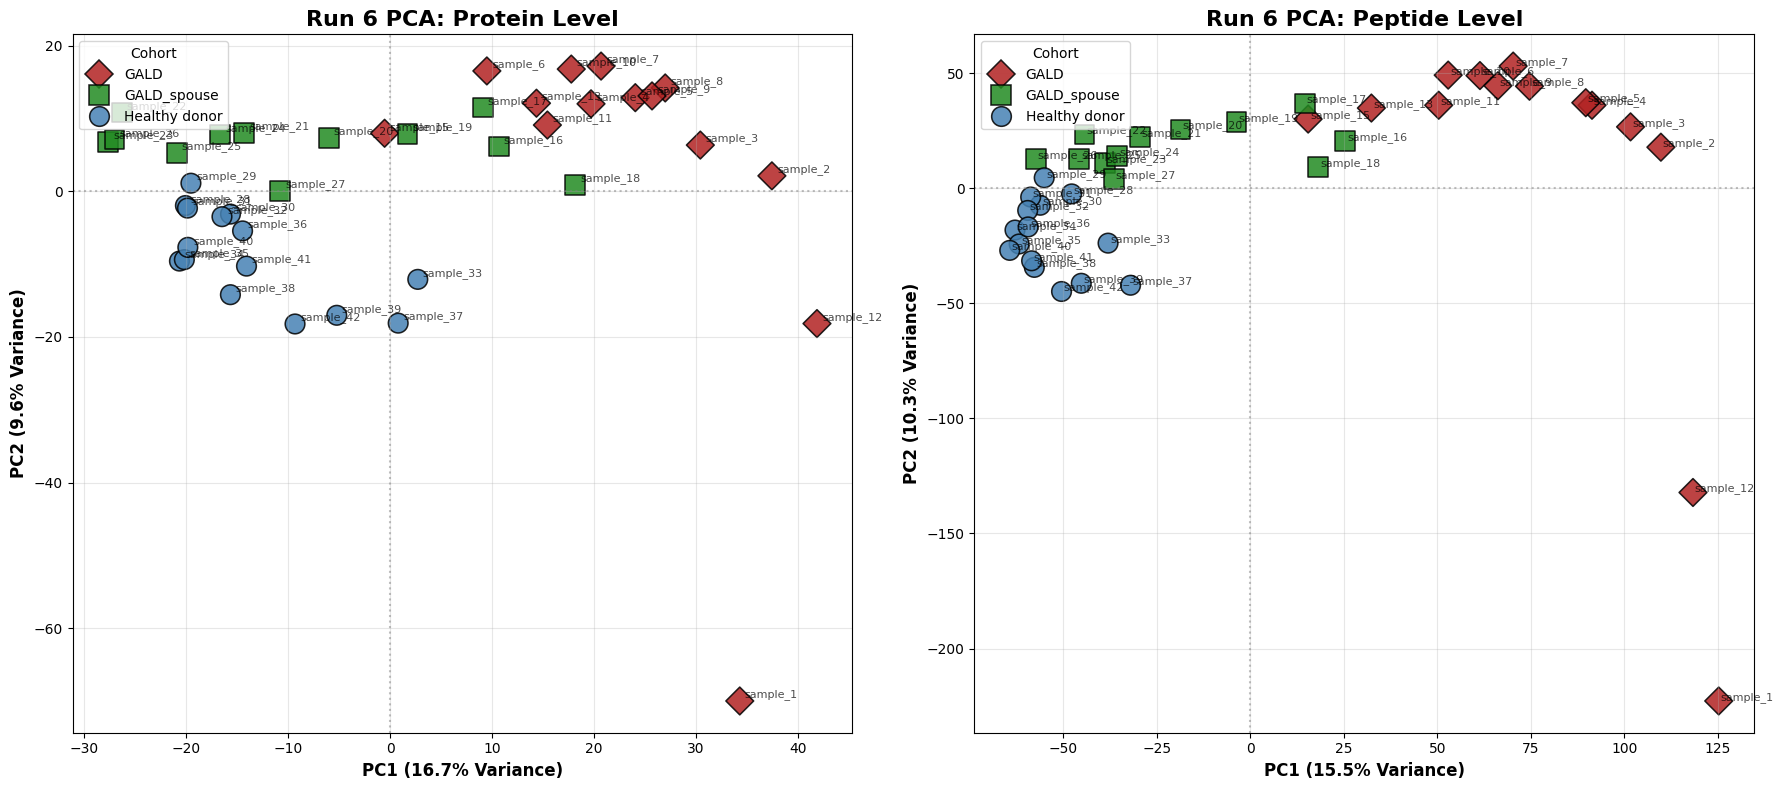


📊 TOP PCA LOADINGS: PROTEIN LEVEL

--- PC1 DRIVERS ---


,Feature,Loading Score,Direction
0,O00461;F8W785,0.047306,Positive (Drives PC1 +)
1,P30519;A0A087WT44;I3L159;I3L1F5;P30519-2;I3L27...,0.047029,Positive (Drives PC1 +)
2,O00748;O00748-4;O00748-2;O00748-5;J3QSC0,0.046324,Positive (Drives PC1 +)
3,Q96KP4;Q96KP4-2;J3QQN6;J3QR27;J3QLU1;J3QKQ0;J3...,0.045849,Positive (Drives PC1 +)
4,P46940;H0YLE8;A0A0J9YXZ5;A0A087X225;A0A087WWP1,0.045789,Positive (Drives PC1 +)
5,P67809;H0Y449;C9J5V9,0.045438,Positive (Drives PC1 +)
6,Q9UJA5;Q9UJA5-2;Q9UJA5-3;Q9UJA5-4,0.045368,Positive (Drives PC1 +)
7,H0Y9G6;E7ETU7;P09001;E9PF06;D6RC14;D6RBQ5,0.045192,Positive (Drives PC1 +)
8,Q13813-3;Q13813;A0A994J4G5;A0A0D9SF54;A0A0D9SF...,0.044766,Positive (Drives PC1 +)
9,A0A7P0T861;K7EL50;P27797;K7EJB9,0.044590,Positive (Drives PC1 +)



--- PC2 DRIVERS ---


,Feature,Loading Score,Direction
0,Q99956,0.054680,Positive (Drives PC2 +)
1,A0A1W2PQT3;A0A1W2PPH1;A0A1W2PQH3;A0A1W2PQY8;P2...,0.053793,Positive (Drives PC2 +)
2,P61224;P61224-3;F5GZG1;B7ZB78;F5H823;P61224-4;...,0.053696,Positive (Drives PC2 +)
3,P14209;P14209-3;A0A096LP69,0.052397,Positive (Drives PC2 +)
4,A0A024R4K9;A0A087X266;Q9BXJ8-2;Q9BXJ8;A0A087WZA9,0.052011,Positive (Drives PC2 +)
5,P51589;A0A3B3IT99;A0A3B3IU95,0.050715,Positive (Drives PC2 +)
6,V9GYE3;V9GYG9;V9GYM3;P02652;V9GYC1;V9GYS1,0.050645,Positive (Drives PC2 +)
7,P06310,0.050255,Positive (Drives PC2 +)
8,P28066;P28066-2,0.050217,Positive (Drives PC2 +)
9,J3QL71;Q96FV2-2;Q96FV2;J3QQM9;J3QRJ1;J3KT79;J3...,0.050193,Positive (Drives PC2 +)



📊 TOP PCA LOADINGS: PEPTIDE LEVEL

--- PC1 DRIVERS ---


,Feature,Loading Score,Direction
0,DMLLANKVPAAAR,0.015826,Positive (Drives PC1 +)
1,TGEEIFGTIGMRPNAK,0.015543,Positive (Drives PC1 +)
2,EQLEEEEEAKHNLEK,0.015521,Positive (Drives PC1 +)
3,YVVISQGLDKPR,0.015430,Positive (Drives PC1 +)
4,YDGKWEVEEMKESK,0.015082,Positive (Drives PC1 +)
5,IVLDSDAAEYGGHQR,0.015075,Positive (Drives PC1 +)
6,NRELAILLGMLDPAEKDEK,0.015068,Positive (Drives PC1 +)
7,TYEDIKENLESR,0.014992,Positive (Drives PC1 +)
8,KFEEEGNPYYSSAR,0.014982,Positive (Drives PC1 +)
9,VLADSLHVGPSARPPPSLSLR,0.014935,Positive (Drives PC1 +)



--- PC2 DRIVERS ---


,Feature,Loading Score,Direction
0,DKNQDLCQQEAVK,0.017943,Positive (Drives PC2 +)
1,SVHGFQMLYADCYMNR,0.017875,Positive (Drives PC2 +)
2,HLLGVEDLLQK,0.017677,Positive (Drives PC2 +)
3,SDTPAMLNPANVPTHLMVLCCVLR,0.017486,Positive (Drives PC2 +)
4,LNAGEIVIGDGGFVFALEKR,0.017475,Positive (Drives PC2 +)
5,EALMAHGLGNR,0.017455,Positive (Drives PC2 +)
6,ADIDLTKR,0.017370,Positive (Drives PC2 +)
7,DEADVLEVDQGFDDHNLPCDVIWLDIEHADGKR,0.017363,Positive (Drives PC2 +)
8,NNLRDWLR,0.017331,Positive (Drives PC2 +)
9,KEGGLGPLNIPLLADVTRR,0.017330,Positive (Drives PC2 +)


In [29]:
#PCA plot
#No CLR transformation. log(x+1) imputation. 
#Run 6
#Both protein and peptide-level

#Bonus: Loading values - for appendix

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Processing Run 6 PCA: Peptide vs Protein Level ---")

# ==========================================
# 1. PIVOT AND PREPARE DATAFRAMES
# ==========================================
def prepare_pca_data(df, feature_col):
    # Pivot: Samples as rows, Features as columns
    pivot_df = df.pivot_table(
        index=['Sample', 'Group'], 
        columns=feature_col, 
        values='Razor Intensity', 
        aggfunc='sum'
    )
    
    # Extract labels and sample names
    labels = pivot_df.index.get_level_values('Group')
    samples = pivot_df.index.get_level_values('Sample')
    
    # 0-fill and Log2 transform
    X_filled = pivot_df.fillna(0)
    X_log = np.log2(X_filled + 1)
    
    return X_log, labels, samples

# Prepare Protein-Level Data
X_prot, y_prot, samples_prot = prepare_pca_data(master_prot_run6_maxQuant_df, 'Protein Group')

# Prepare Peptide-Level Data
X_pep, y_pep, samples_pep = prepare_pca_data(master_pep_run6_maxQuant_df, 'Peptide Sequence')

# ==========================================
# 2. RUN PCA FUNCTION
# ==========================================
def run_pca(X_data, labels, samples):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plot_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Group': labels,
        'Sample': samples
    })
    
    # Return the fitted pca model as well so we can extract the loadings!
    return plot_df, pca.explained_variance_ratio_ * 100, pca

prot_plot_df, prot_variance, prot_pca = run_pca(X_prot, y_prot, samples_prot)
pep_plot_df, pep_variance, pep_pca = run_pca(X_pep, y_pep, samples_pep)

# ==========================================
# 3. VISUALIZATION (SIDE-BY-SIDE)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

palette = {'Healthy donor': 'steelblue', 'GALD_spouse': 'forestgreen', 'GALD': 'firebrick'}
markers = {'Healthy donor': 'o', 'GALD_spouse': 's', 'GALD': 'D'}

# --- Plot 1: PROTEIN LEVEL ---
sns.scatterplot(
    ax=axes[0], data=prot_plot_df, x='PC1', y='PC2', 
    hue='Group', style='Group', palette=palette, markers=markers,
    s=200, edgecolor='k', alpha=0.85
)
for i in range(prot_plot_df.shape[0]):
    axes[0].text(prot_plot_df['PC1'].iloc[i] + 0.5, prot_plot_df['PC2'].iloc[i] + 0.5, 
                 prot_plot_df['Sample'].iloc[i], fontsize=8, alpha=0.7)

axes[0].set_title("Run 6 PCA: Protein Level", fontsize=16, weight='bold')
axes[0].set_xlabel(f"PC1 ({prot_variance[0]:.1f}% Variance)", fontsize=12, weight='bold')
axes[0].set_ylabel(f"PC2 ({prot_variance[1]:.1f}% Variance)", fontsize=12, weight='bold')
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# --- Plot 2: PEPTIDE LEVEL ---
sns.scatterplot(
    ax=axes[1], data=pep_plot_df, x='PC1', y='PC2', 
    hue='Group', style='Group', palette=palette, markers=markers,
    s=200, edgecolor='k', alpha=0.85
)
for i in range(pep_plot_df.shape[0]):
    axes[1].text(pep_plot_df['PC1'].iloc[i] + 0.5, pep_plot_df['PC2'].iloc[i] + 0.5, 
                 pep_plot_df['Sample'].iloc[i], fontsize=8, alpha=0.7)

axes[1].set_title("Run 6 PCA: Peptide Level", fontsize=16, weight='bold')
axes[1].set_xlabel(f"PC1 ({pep_variance[0]:.1f}% Variance)", fontsize=12, weight='bold')
axes[1].set_ylabel(f"PC2 ({pep_variance[1]:.1f}% Variance)", fontsize=12, weight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle=':', alpha=0.5)

axes[0].legend(title="Cohort", loc='upper left')
axes[1].legend(title="Cohort", loc='upper left')

plt.tight_layout()
plt.show()

# ==========================================
# 4. EXTRACT AND DISPLAY PCA LOADINGS
# ==========================================
def display_top_loadings(pca_model, feature_names, level_title):
    print(f"\n==========================================================")
    print(f"📊 TOP PCA LOADINGS: {level_title.upper()}")
    print(f"==========================================================")
    
    # PCs in sklearn are accessed via pca_model.components_
    # component[0] = PC1, component[1] = PC2
    for pc_idx, pc_name in enumerate(['PC1', 'PC2']):
        # Map the loadings back to the original feature names
        loadings_series = pd.Series(pca_model.components_[pc_idx], index=feature_names)
        
        # Extract Top 10 Positive (Drives sample to the Right/Up)
        top_pos = loadings_series.nlargest(10).reset_index()
        top_pos.columns = ['Feature', 'Loading Score']
        top_pos['Direction'] = f'Positive (Drives {pc_name} +)'
        
        # Extract Top 10 Negative (Drives sample to the Left/Down)
        top_neg = loadings_series.nsmallest(10).reset_index()
        top_neg.columns = ['Feature', 'Loading Score']
        top_neg['Direction'] = f'Negative (Drives {pc_name} -)'
        
        # Combine and display cleanly
        combined_df = pd.concat([top_pos, top_neg], ignore_index=True)
        print(f"\n--- {pc_name} DRIVERS ---")
        
        # Use display() if in Jupyter, otherwise fallback to print()
        try:
            display(combined_df)
        except NameError:
            print(combined_df.to_string(index=False))

# Run the loadings extractor for Protein Level
display_top_loadings(prot_pca, X_prot.columns, "Protein Level")

# Run the loadings extractor for Peptide Level
display_top_loadings(pep_pca, X_pep.columns, "Peptide Level")


**Run 5 and Run 4 PCA plot:**

--- Processing Run 5 PCA: Peptide vs Protein Level ---


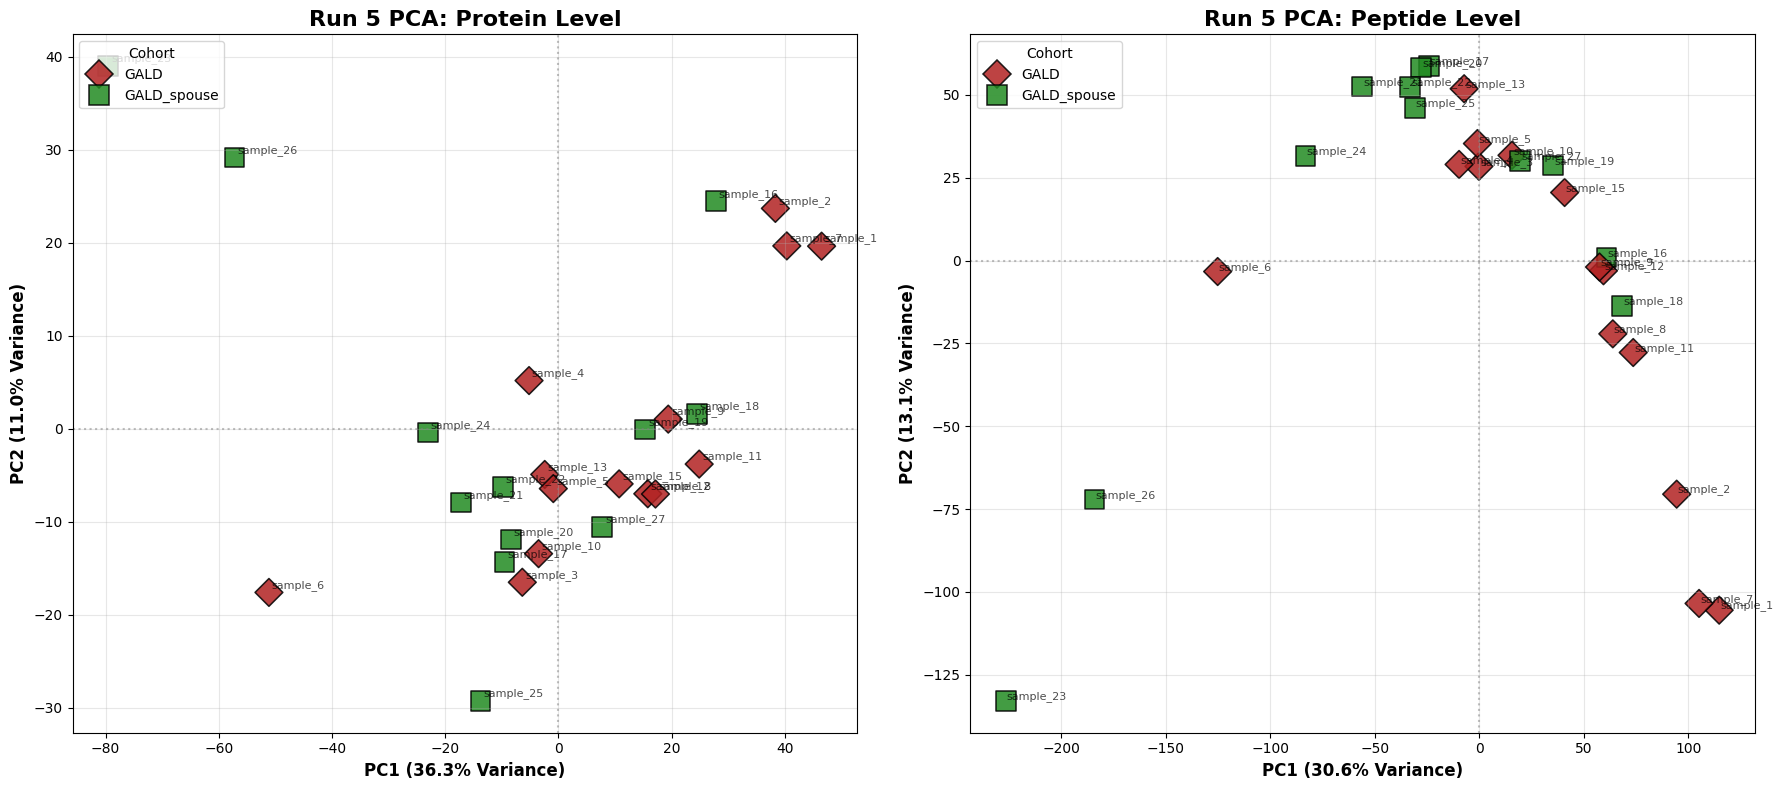

In [30]:
#PCA plot
#No CLR transformation. log(x+1) imputation. 
#Run 5
#Both protein and peptide-level

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Processing Run 5 PCA: Peptide vs Protein Level ---")

# ==========================================
# 1. PIVOT AND PREPARE DATAFRAMES
# ==========================================
# Use Razor Intensity as the value, fill missing biological dropouts with 0
def prepare_pca_data(df, feature_col):
    # Pivot: Samples as rows, Features as columns
    pivot_df = df.pivot_table(
        index=['Sample', 'Group'], 
        columns=feature_col, 
        values='Razor Intensity', 
        aggfunc='sum'
    )
    
    # Extract labels and sample names
    labels = pivot_df.index.get_level_values('Group')
    samples = pivot_df.index.get_level_values('Sample')
    
    # 0-fill (No artificial imputation for IP data) and Log2 transform
    X_filled = pivot_df.fillna(0)
    X_log = np.log2(X_filled + 1)
    
    return X_log, labels, samples

# Prepare Protein-Level Data
X_prot, y_prot, samples_prot = prepare_pca_data(master_prot_run5_maxQuant_df, 'Protein Group')

# Prepare Peptide-Level Data
X_pep, y_pep, samples_pep = prepare_pca_data(master_pep_run5_maxQuant_df, 'Peptide Sequence')

# ==========================================
# 2. RUN PCA FUNCTION
# ==========================================
def run_pca(X_data, labels, samples):
    # Standard scale to prevent massive structural proteins/antibodies from monopolizing the variance
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Create plot dataframe
    plot_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Group': labels,
        'Sample': samples
    })
    
    return plot_df, pca.explained_variance_ratio_ * 100

prot_plot_df, prot_variance = run_pca(X_prot, y_prot, samples_prot)
pep_plot_df, pep_variance = run_pca(X_pep, y_pep, samples_pep)

# ==========================================
# 3. VISUALIZATION (SIDE-BY-SIDE)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Custom Aesthetic Palette & Markers
# Note: If spouses are not in Run 5, seaborn will just ignore the unused palette keys
palette = {
    'Healthy donor': 'steelblue', 
    'GALD_spouse': 'forestgreen',
    'GALD': 'firebrick'
}
markers = {
    'Healthy donor': 'o', 
    'GALD_spouse': 's',   # Squares for spouses
    'GALD': 'D'           # Diamonds for GALD
}

# --- Plot 1: PROTEIN LEVEL ---
sns.scatterplot(
    ax=axes[0], data=prot_plot_df, x='PC1', y='PC2', 
    hue='Group', style='Group', palette=palette, markers=markers,
    s=200, edgecolor='k', alpha=0.85
)
# Add Labels
for i in range(prot_plot_df.shape[0]):
    axes[0].text(prot_plot_df['PC1'].iloc[i] + 0.5, prot_plot_df['PC2'].iloc[i] + 0.5, 
                 prot_plot_df['Sample'].iloc[i], fontsize=8, alpha=0.7)

axes[0].set_title("Run 5 PCA: Protein Level", fontsize=16, weight='bold')
axes[0].set_xlabel(f"PC1 ({prot_variance[0]:.1f}% Variance)", fontsize=12, weight='bold')
axes[0].set_ylabel(f"PC2 ({prot_variance[1]:.1f}% Variance)", fontsize=12, weight='bold')
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# --- Plot 2: PEPTIDE LEVEL ---
sns.scatterplot(
    ax=axes[1], data=pep_plot_df, x='PC1', y='PC2', 
    hue='Group', style='Group', palette=palette, markers=markers,
    s=200, edgecolor='k', alpha=0.85
)
# Add Labels
for i in range(pep_plot_df.shape[0]):
    axes[1].text(pep_plot_df['PC1'].iloc[i] + 0.5, pep_plot_df['PC2'].iloc[i] + 0.5, 
                 pep_plot_df['Sample'].iloc[i], fontsize=8, alpha=0.7)

axes[1].set_title("Run 5 PCA: Peptide Level", fontsize=16, weight='bold')
axes[1].set_xlabel(f"PC1 ({pep_variance[0]:.1f}% Variance)", fontsize=12, weight='bold')
axes[1].set_ylabel(f"PC2 ({pep_variance[1]:.1f}% Variance)", fontsize=12, weight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# Adjust legends
axes[0].legend(title="Cohort", loc='upper left')
axes[1].legend(title="Cohort", loc='upper left')

plt.tight_layout()
plt.show()


--- Processing Run 4 PCA: Peptide vs Protein Level ---


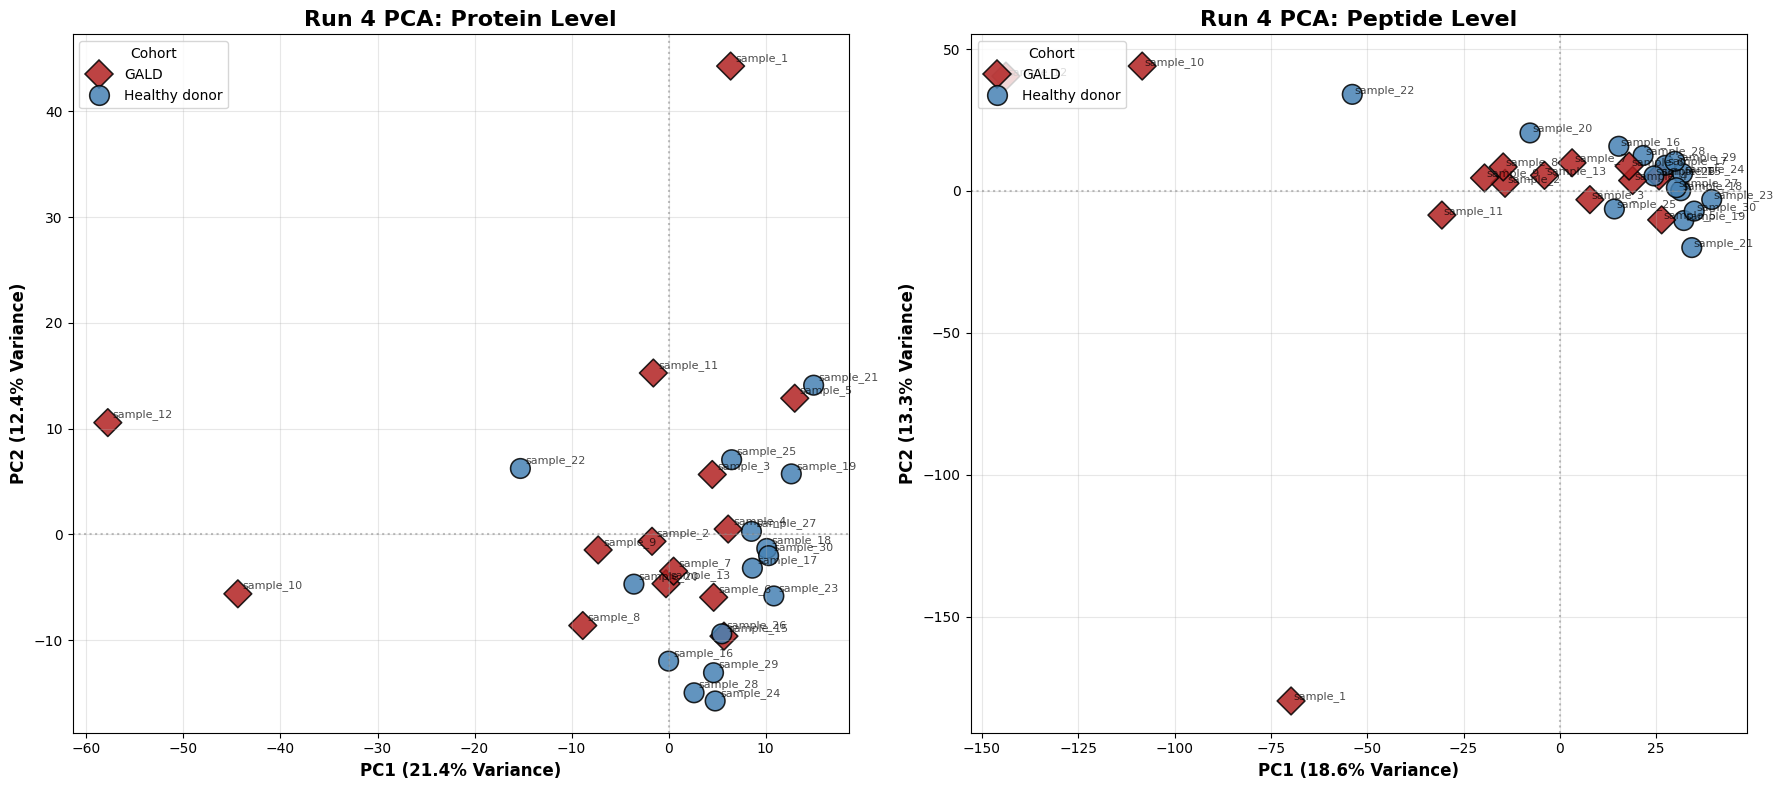

In [31]:
#PCA plot
#No CLR transformation. log(x+1) imputation. 
#Run 4
#Both protein and peptide-level

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Processing Run 4 PCA: Peptide vs Protein Level ---")

# ==========================================
# 1. PIVOT AND PREPARE DATAFRAMES
# ==========================================
# Use Razor Intensity as the value, fill missing biological dropouts with 0
def prepare_pca_data(df, feature_col):
    # Pivot: Samples as rows, Features as columns
    pivot_df = df.pivot_table(
        index=['Sample', 'Group'], 
        columns=feature_col, 
        values='Razor Intensity', 
        aggfunc='sum'
    )
    
    # Extract labels and sample names
    labels = pivot_df.index.get_level_values('Group')
    samples = pivot_df.index.get_level_values('Sample')
    
    # 0-fill (No artificial imputation for IP data) and Log2 transform
    X_filled = pivot_df.fillna(0)
    X_log = np.log2(X_filled + 1)
    
    return X_log, labels, samples

# Prepare Protein-Level Data
X_prot, y_prot, samples_prot = prepare_pca_data(master_prot_run4_maxQuant_df, 'Protein Group')

# Prepare Peptide-Level Data
X_pep, y_pep, samples_pep = prepare_pca_data(master_pep_run4_maxQuant_df, 'Peptide Sequence')

# ==========================================
# 2. RUN PCA FUNCTION
# ==========================================
def run_pca(X_data, labels, samples):
    # Standard scale to prevent massive structural proteins/antibodies from monopolizing the variance
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_data)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Create plot dataframe
    plot_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Group': labels,
        'Sample': samples
    })
    
    return plot_df, pca.explained_variance_ratio_ * 100

prot_plot_df, prot_variance = run_pca(X_prot, y_prot, samples_prot)
pep_plot_df, pep_variance = run_pca(X_pep, y_pep, samples_pep)

# ==========================================
# 3. VISUALIZATION (SIDE-BY-SIDE)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Custom Aesthetic Palette & Markers
palette = {
    'Healthy donor': 'steelblue', 
    'GALD_spouse': 'forestgreen',
    'GALD': 'firebrick'
}
markers = {
    'Healthy donor': 'o', 
    'GALD_spouse': 's',   # Squares for spouses
    'GALD': 'D'           # Diamonds for GALD
}

# --- Plot 1: PROTEIN LEVEL ---
sns.scatterplot(
    ax=axes[0], data=prot_plot_df, x='PC1', y='PC2', 
    hue='Group', style='Group', palette=palette, markers=markers,
    s=200, edgecolor='k', alpha=0.85
)
# Add Labels
for i in range(prot_plot_df.shape[0]):
    axes[0].text(prot_plot_df['PC1'].iloc[i] + 0.5, prot_plot_df['PC2'].iloc[i] + 0.5, 
                 prot_plot_df['Sample'].iloc[i], fontsize=8, alpha=0.7)

axes[0].set_title("Run 4 PCA: Protein Level", fontsize=16, weight='bold')
axes[0].set_xlabel(f"PC1 ({prot_variance[0]:.1f}% Variance)", fontsize=12, weight='bold')
axes[0].set_ylabel(f"PC2 ({prot_variance[1]:.1f}% Variance)", fontsize=12, weight='bold')
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# --- Plot 2: PEPTIDE LEVEL ---
sns.scatterplot(
    ax=axes[1], data=pep_plot_df, x='PC1', y='PC2', 
    hue='Group', style='Group', palette=palette, markers=markers,
    s=200, edgecolor='k', alpha=0.85
)
# Add Labels
for i in range(pep_plot_df.shape[0]):
    axes[1].text(pep_plot_df['PC1'].iloc[i] + 0.5, pep_plot_df['PC2'].iloc[i] + 0.5, 
                 pep_plot_df['Sample'].iloc[i], fontsize=8, alpha=0.7)

axes[1].set_title("Run 4 PCA: Peptide Level", fontsize=16, weight='bold')
axes[1].set_xlabel(f"PC1 ({pep_variance[0]:.1f}% Variance)", fontsize=12, weight='bold')
axes[1].set_ylabel(f"PC2 ({pep_variance[1]:.1f}% Variance)", fontsize=12, weight='bold')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# Adjust legends
axes[0].legend(title="Cohort", loc='upper left')
axes[1].legend(title="Cohort", loc='upper left')

plt.tight_layout()
plt.show()


**Updated approach: Decision tree prediction model**

PCA prediciton models no longer seems as a great model - based on the complexity of the PCA, which can no longer be solved using simple linear approaches. Instead we can use more advanced infrastucture, such as decision trees. <br>
A challenge is that the LFQ intensities are not necessarily going to be the same if you repeat the experiment. 

* The best mmodel: A Random Forest Classifier (an ensemble of many decision trees). A single decision tree will wildly overfit the small sample size. A Random Forest builds 100 different trees using random subsets of the proteins and averages them, making it highly robust. 

Strategy 1: The Binary Model (Presence / Absence) <br>
This seemingly makes sense for Immunoprecipitation data.
In an IP, we care primarily about whether an antigen was physically pulled down by the antibody (1) or washed away (0). By converting the LFQ intensities into a binary matrix (Intensity > 0 = 1, NaN/0 = 0), the model becomes 100% immune to LFQ intensity shifts. 
<br>

Strategy 2: Intra-Sample Ranking<br>
Without losing the quantitative aspect this approach e.g. still allows us to determine whether Protein A is more abundant than Protein B, even if both are present. This approach converts the data to ranks. 
Instead of telling the model: "Protein A has an intensity of 4,000,000", you tell it: "Protein A is the 5th most abundant protein in this sample." If the mass spec is running differently next week and Protein A jumps to 40,000,000, it will likely still be the 5th most abundant protein. The rank stays stable across batches. 

**Data conversion, leading razor protein instead of protein group, training random forest, and testing on Run 4 and 5 data:**

Note: We use leading razor proteins, as protein groups are not generalizable across experiments. Thus, in order to get a more generalizing model, it is relevant to use the leading razor proteins as labels. 

--- Robust Cross-Run Binary Random Forest Predictor ---

Preparing Run 6 (Training Data)...
Training on 32 samples from Run 6.
Run 6 Internal Holdout Accuracy: 100.0%

--- Testing Model on Unseen Experiments ---
Run 4 Accuracy (29 samples): 48.3%
Run 5 Accuracy (26 samples): 53.8%

🌳 TOP PROTEINS DRIVING THE DECISION TREES (Cross-Run Stable) 🌳


,Razor_Protein_ID,Importance,Protein Description,Gene
0,Q9UHD8-3,0.032263,"sp|Q9UHD8-3|SEPT9_HUMAN Isoform of Q9UHD8, Iso...",SEPT9
1,Q9BT73,0.026414,sp|Q9BT73|PSMG3_HUMAN Proteasome assembly chap...,PSMG3
2,O00483,0.025290,sp|O00483|NDUA4_HUMAN Cytochrome c oxidase sub...,NDUFA4
3,I3L448,0.024413,"tr|I3L448|I3L448_HUMAN Isoform of Q5TC12, ATP ...",ATPAF1
4,O60313-10,0.022961,"sp|O60313-10|OPA1_HUMAN Isoform of O60313, Iso...",OPA1
5,Q9NQ50,0.021798,sp|Q9NQ50|RM40_HUMAN Large ribosomal subunit p...,MRPL40
6,Q14197,0.020566,sp|Q14197|ICT1_HUMAN Large ribosomal subunit p...,ICT1
7,Q9P2B2,0.015647,sp|Q9P2B2|FPRP_HUMAN Prostaglandin F2 receptor...,PTGFRN
8,Q9NY15,0.014362,sp|Q9NY15|STAB1_HUMAN Stabilin-1 OS=Homo sapie...,STAB1
9,Q9BQ39,0.013474,sp|Q9BQ39|DDX50_HUMAN ATP-dependent RNA helica...,DDX50


/tmp/ipykernel_1908/2412818901.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


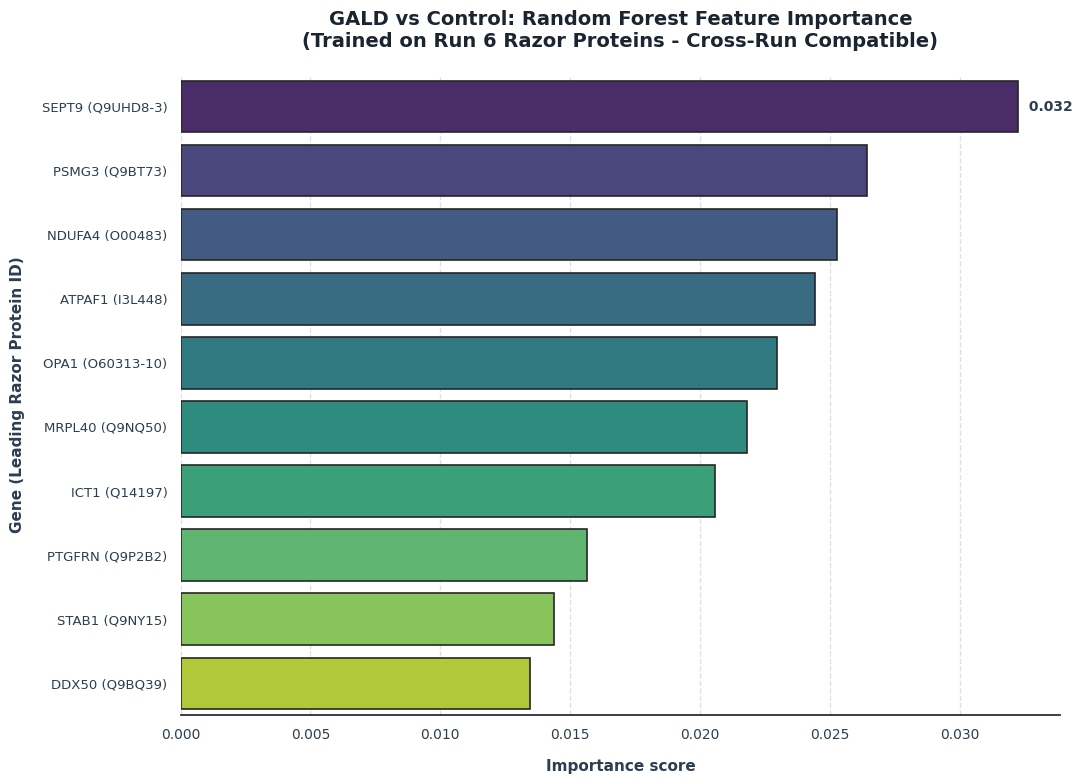

In [32]:
# Robust Binary Random Forest Predictor (Cross-Run Compatible) 
import pandas as pd
import numpy as np
import textwrap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Robust Cross-Run Binary Random Forest Predictor ---")

# ==========================================
# 1. HELPER FUNCTIONS FOR CROSS-RUN PREP
# ==========================================

def extract_razor_protein(protein_group_string):
    """Extracts the leading razor protein (the first ID) from a MaxQuant group string."""
    return str(protein_group_string).split(';')[0].strip()

def prepare_binary_dataset(df, intensity_col='Razor Intensity', target_groups=['GALD', 'Healthy donor', 'GALD_spouse']):
    """Filters cohorts, extracts razor proteins, and converts to a binary presence/absence matrix."""
    df_clean = df.copy()
    
    # 1. Extract stable identifier
    df_clean['Razor_Protein_ID'] = df_clean['Protein Group'].apply(extract_razor_protein)
    
    # 2. Filter groups and standardize to GALD vs Control
    filtered_df = df_clean[df_clean['Group'].isin(target_groups)].copy()
    filtered_df['Group'] = filtered_df['Group'].replace({'Healthy donor': 'Control', 'GALD_spouse': 'Control'})
    
    # 3. Pivot data
    X_raw = filtered_df.pivot_table(index=['Sample', 'Group'], columns='Razor_Protein_ID', values=intensity_col, aggfunc='sum')
    
    # 4. Extract labels and reset index
    y_labels = X_raw.index.get_level_values('Group')
    X_raw.index = X_raw.index.get_level_values('Sample')
    
    # 5. Convert to Binary ( > 0 becomes 1, NaNs/0s become 0 )
    X_binary = (X_raw.fillna(0) > 0).astype(int)
    
    return X_binary, y_labels

def align_features_to_model(X_new, training_features):
    """
    Ensures a new dataset has the exact same columns as the training dataset.
    Missing proteins are added as 0 (Absent). Extra proteins are ignored.
    """
    return X_new.reindex(columns=training_features, fill_value=0)

# ==========================================
# 2. PREPARE TRAINING DATA (RUN 6)
# ==========================================
print("\nPreparing Run 6 (Training Data)...")
X_r6, y_r6 = prepare_binary_dataset(master_prot_run6_maxQuant_df)

# Save the exact feature list the model will learn from
TRAINING_FEATURES = X_r6.columns

# Standard 80/20 split on Run 6 for internal validation
RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_r6, y_r6, test_size=0.20, random_state=RANDOM_SEED, stratify=y_r6
)

print(f"Training on {len(X_train)} samples from Run 6.")

# ==========================================
# 3. TRAIN THE RANDOM FOREST
# ==========================================
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, class_weight='balanced') #Builds 100 trees
rf_clf.fit(X_train, y_train)

# Internal Validation on Run 6 20% holdout
y_pred_test = rf_clf.predict(X_test)
print(f"Run 6 Internal Holdout Accuracy: {accuracy_score(y_test, y_pred_test) * 100:.1f}%")

# ==========================================
# 4. TEST MODEL ON ENTIRELY NEW DATASETS (RUN 4 & 5)
# ==========================================
# This proves the model can handle any number of samples, as long as we align the features!
print("\n--- Testing Model on Unseen Experiments ---")

# Run 4
try:
    X_r4_raw, y_r4 = prepare_binary_dataset(master_prot_run4_maxQuant_df) 
    X_r4_aligned = align_features_to_model(X_r4_raw, TRAINING_FEATURES) #Reindexing with proper leading razor proteins.  
    r4_predictions = rf_clf.predict(X_r4_aligned) 
    print(f"Run 4 Accuracy ({len(y_r4)} samples): {accuracy_score(y_r4, r4_predictions) * 100:.1f}%") 
except NameError: 
    print("Run 4 dataframe not found in memory.") 

# Run 5
try:
    X_r5_raw, y_r5 = prepare_binary_dataset(master_prot_run5_maxQuant_df)
    X_r5_aligned = align_features_to_model(X_r5_raw, TRAINING_FEATURES) 
    r5_predictions = rf_clf.predict(X_r5_aligned)
    print(f"Run 5 Accuracy ({len(y_r5)} samples): {accuracy_score(y_r5, r5_predictions) * 100:.1f}%")
except NameError:
    print("Run 5 dataframe not found in memory.")

# Example: Predicting a single sample
# single_sample = X_r5_aligned.iloc[[0]] 
# single_pred = rf_clf.predict(single_sample)

# ==========================================
# 5. EXTRACT THE "SMOKING GUNS" (Feature Importance)
# ==========================================
importances = rf_clf.feature_importances_

importance_df = pd.DataFrame({
    'Razor_Protein_ID': TRAINING_FEATURES,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Keep top 10 most important proteins
top_features = importance_df[importance_df['Importance'] > 0].head(10).copy()

# Trace back to descriptions and genes (using Run 6 dictionary)
# Re-extract razor IDs to build the dictionary cleanly
df6_dict = master_prot_run6_maxQuant_df.copy()
df6_dict['Razor_Protein_ID'] = df6_dict['Protein Group'].apply(extract_razor_protein)
info_dict = df6_dict[['Razor_Protein_ID', 'Protein Description', 'Gene']].drop_duplicates(subset='Razor_Protein_ID')

top_features = pd.merge(top_features, info_dict, on='Razor_Protein_ID', how='left')

print("\n====================================================================")
print("🌳 TOP PROTEINS DRIVING THE DECISION TREES (Cross-Run Stable) 🌳")
print("====================================================================")
display(top_features)

# ==========================================
# 6. VISUALIZE FEATURE IMPORTANCE 
# ==========================================
sns.set_theme(style="white")

def wrap_protein_names(row):
    """Combines Gene and Razor ID for a clean plot label"""
    gene = row['Gene'] if pd.notna(row['Gene']) else 'Unknown'
    label = f"{gene} ({row['Razor_Protein_ID']})"
    return '\n'.join(textwrap.wrap(label, width=40))

top_features['Plot Label'] = top_features.apply(wrap_protein_names, axis=1)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=top_features, 
    x='Importance', 
    y='Plot Label', 
    palette='viridis', 
    edgecolor='.15', 
    linewidth=1.2,
    ax=ax
)

ax.bar_label(ax.containers[0], fmt=' %.3f', padding=4, color='#2c3e50', weight='semibold', size=10)

ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#cccccc')
ax.set_axisbelow(True) 
sns.despine(left=True, bottom=False)

plt.yticks(fontsize=9.5, color='#2c3e50', weight='medium')
plt.xticks(fontsize=10, color='#2c3e50')

plt.title("GALD vs Control: Random Forest Feature Importance\n(Trained on Run 6 Razor Proteins - Cross-Run Compatible)", 
          weight='bold', fontsize=14, pad=20, color='#1a252f')
plt.xlabel("Importance score", fontsize=11, labelpad=12, weight='semibold', color='#2c3e50')
plt.ylabel("Gene (Leading Razor Protein ID)", fontsize=11, labelpad=12, weight='semibold', color='#2c3e50')

plt.tight_layout()
plt.show()


--- Robust Cross-Run Rank-Based Random Forest Predictor ---

Preparing Run 6 (Training Data)...
Training on 32 samples from Run 6 (Rank-Transformed Features).
Run 6 Internal Holdout Accuracy: 100.0%

--- Testing Model on Unseen Experiments ---
Run 4 Accuracy (29 samples): 48.3%
Run 5 Accuracy (26 samples): 53.8%

📈 TOP RANK-DRIVEN PROTEINS (Cross-Run Stable) 📈


,Razor_Protein_ID,Importance,Protein Description,Gene
0,Q9BT73,0.040000,sp|Q9BT73|PSMG3_HUMAN Proteasome assembly chap...,PSMG3
1,P61158,0.025729,sp|P61158|ARP3_HUMAN Actin-related protein 3 O...,ACTR3
2,Q9Y617,0.020000,sp|Q9Y617|SERC_HUMAN Phosphoserine aminotransf...,PSAT1
3,A0A0B4J1W3,0.020000,tr|A0A0B4J1W3|A0A0B4J1W3_HUMAN Isoform of Q9BX...,NAA15
4,O60313-10,0.018281,"sp|O60313-10|OPA1_HUMAN Isoform of O60313, Iso...",OPA1
5,K7EQ23,0.018270,"tr|K7EQ23|K7EQ23_HUMAN Isoform of O15118, NPC ...",NPC1
6,O95278,0.018146,"sp|O95278|EPM2A_HUMAN Isoform of B3EWF7, Lafor...",EPM2A
7,P54687-4,0.018101,"sp|P54687-4|BCAT1_HUMAN Isoform of P54687, Iso...",BCAT1
8,P09488,0.017633,sp|P09488|GSTM1_HUMAN Glutathione S-transferas...,GSTM1
9,O95864,0.016817,sp|O95864|FADS2_HUMAN Acyl-CoA 6-desaturase OS...,FADS2


/tmp/ipykernel_1908/2616781959.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


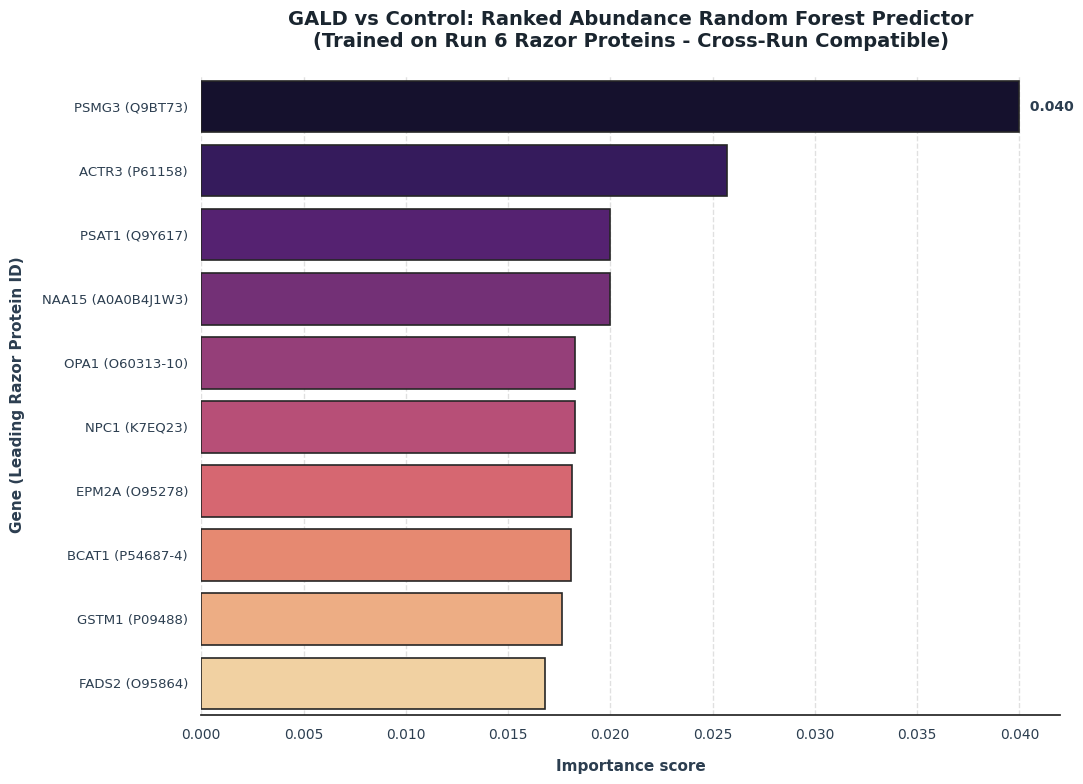

In [33]:
# Robust Intra-Sample Rank Random Forest Predictor (Cross-Run Compatible)
import pandas as pd
import numpy as np
import textwrap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Robust Cross-Run Rank-Based Random Forest Predictor ---")

# ==========================================
# 1. HELPER FUNCTIONS FOR CROSS-RUN PREP
# ==========================================

def extract_razor_protein(protein_group_string):
    """Extracts the leading razor protein (the first ID) from a MaxQuant group string."""
    return str(protein_group_string).split(';')[0].strip()

def prepare_raw_dataset(df, intensity_col='Razor Intensity', target_groups=['GALD', 'Healthy donor', 'GALD_spouse']):
    """Filters cohorts, extracts razor proteins, and returns the unranked raw pivot matrix."""
    df_clean = df.copy()
    
    # 1. Extract stable identifier
    df_clean['Razor_Protein_ID'] = df_clean['Protein Group'].apply(extract_razor_protein)
    
    # 2. Filter groups and standardize to GALD vs Control
    filtered_df = df_clean[df_clean['Group'].isin(target_groups)].copy()
    filtered_df['Group'] = filtered_df['Group'].replace({'Healthy donor': 'Control', 'GALD_spouse': 'Control'})
    
    # 3. Pivot data
    X_raw = filtered_df.pivot_table(index=['Sample', 'Group'], columns='Razor_Protein_ID', values=intensity_col, aggfunc='sum')
    
    # 4. Extract labels and reset index
    y_labels = X_raw.index.get_level_values('Group')
    X_raw.index = X_raw.index.get_level_values('Sample')
    
    return X_raw, y_labels

def align_and_rank_features(X_raw, training_features=None):
    """
    Aligns the columns to match the training set EXACTLY, then applies Dense Ranking.
    This ensures missing proteins safely tie for Rank 1, and extra proteins are dropped.
    """
    X_filled = X_raw.fillna(0)
    
    if training_features is not None:
        X_aligned = X_filled.reindex(columns=training_features, fill_value=0)
    else:
        X_aligned = X_filled
        
    # Apply Dense Ranking across the rows (axis=1)
    # 'dense' means all 0s tie for Rank 1. The smallest detected protein is Rank 2.
    X_ranked = X_aligned.rank(axis=1, method='dense', ascending=True)
    
    return X_ranked

# ==========================================
# 2. PREPARE TRAINING DATA (RUN 6)
# ==========================================
print("\nPreparing Run 6 (Training Data)...")
X_r6_raw, y_r6 = prepare_raw_dataset(master_prot_run6_maxQuant_df)

# Rank the data and save the exact feature list the model will learn from
X_r6_ranked = align_and_rank_features(X_r6_raw, training_features=None)
TRAINING_FEATURES = X_r6_ranked.columns

# Standard 80/20 split on Run 6 for internal validation
RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_r6_ranked, y_r6, test_size=0.20, random_state=RANDOM_SEED, stratify=y_r6
)

print(f"Training on {len(X_train)} samples from Run 6 (Rank-Transformed Features).")

# ==========================================
# 3. TRAIN THE RANDOM FOREST
# ==========================================
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, class_weight='balanced')
rf_clf.fit(X_train, y_train)

# Internal Validation on Run 6 20% holdout
y_pred_test = rf_clf.predict(X_test)
print(f"Run 6 Internal Holdout Accuracy: {accuracy_score(y_test, y_pred_test) * 100:.1f}%")

# ==========================================
# 4. TEST MODEL ON ENTIRELY NEW DATASETS (RUN 4 & 5)
# ==========================================
print("\n--- Testing Model on Unseen Experiments ---")

# Run 4
try:
    X_r4_raw, y_r4 = prepare_raw_dataset(master_prot_run4_maxQuant_df)
    X_r4_ranked = align_and_rank_features(X_r4_raw, TRAINING_FEATURES) # Aligns BEFORE ranking!
    r4_predictions = rf_clf.predict(X_r4_ranked)
    print(f"Run 4 Accuracy ({len(y_r4)} samples): {accuracy_score(y_r4, r4_predictions) * 100:.1f}%")
except NameError:
    print("Run 4 dataframe not found in memory.")

# Run 5
try:
    X_r5_raw, y_r5 = prepare_raw_dataset(master_prot_run5_maxQuant_df)
    X_r5_ranked = align_and_rank_features(X_r5_raw, TRAINING_FEATURES) 
    r5_predictions = rf_clf.predict(X_r5_ranked)
    print(f"Run 5 Accuracy ({len(y_r5)} samples): {accuracy_score(y_r5, r5_predictions) * 100:.1f}%")
except NameError:
    print("Run 5 dataframe not found in memory.")

# ==========================================
# 5. EXTRACT THE FEATURE IMPORTANCES
# ==========================================
importances = rf_clf.feature_importances_

importance_df = pd.DataFrame({
    'Razor_Protein_ID': TRAINING_FEATURES,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Keep top 10 most important proteins
top_features = importance_df[importance_df['Importance'] > 0].head(10).copy()

# Trace back to descriptions and genes (using Run 6 dictionary)
df6_dict = master_prot_run6_maxQuant_df.copy()
df6_dict['Razor_Protein_ID'] = df6_dict['Protein Group'].apply(extract_razor_protein)
info_dict = df6_dict[['Razor_Protein_ID', 'Protein Description', 'Gene']].drop_duplicates(subset='Razor_Protein_ID')

top_features = pd.merge(top_features, info_dict, on='Razor_Protein_ID', how='left')

print("\n====================================================================")
print("📈 TOP RANK-DRIVEN PROTEINS (Cross-Run Stable) 📈")
print("====================================================================")
display(top_features)

# ==========================================
# 6. VISUALIZE FEATURE IMPORTANCE 
# ==========================================
sns.set_theme(style="white")

def wrap_protein_names(row):
    """Combines Gene and Razor ID for a clean plot label"""
    gene = row['Gene'] if pd.notna(row['Gene']) else 'Unknown'
    label = f"{gene} ({row['Razor_Protein_ID']})"
    return '\n'.join(textwrap.wrap(label, width=40))

top_features['Plot Label'] = top_features.apply(wrap_protein_names, axis=1)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=top_features, 
    x='Importance', 
    y='Plot Label', 
    palette='magma', 
    edgecolor='.15', 
    linewidth=1.2,
    ax=ax
)

ax.bar_label(ax.containers[0], fmt=' %.3f', padding=4, color='#2c3e50', weight='semibold', size=10)

ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#cccccc')
ax.set_axisbelow(True) 
sns.despine(left=True, bottom=False)

plt.yticks(fontsize=9.5, color='#2c3e50', weight='medium')
plt.xticks(fontsize=10, color='#2c3e50')

plt.title("GALD vs Control: Ranked Abundance Random Forest Predictor\n(Trained on Run 6 Razor Proteins - Cross-Run Compatible)", 
          weight='bold', fontsize=14, pad=20, color='#1a252f')
plt.xlabel("Importance score", fontsize=11, labelpad=12, weight='semibold', color='#2c3e50')
plt.ylabel("Gene (Leading Razor Protein ID)", fontsize=11, labelpad=12, weight='semibold', color='#2c3e50')

plt.tight_layout()
plt.show()


**Bonus - CLR random forest prediction:**

--- Robust Cross-Run CLR Random Forest Predictor ---

Preparing Run 6 (Training Data)...
Training on 32 samples from Run 6.
Run 6 Internal Holdout Accuracy: 100.0%

--- Testing Model on Unseen Experiments (CLR Transformed) ---
Run 4 Accuracy (29 samples): 51.7%
Run 5 Accuracy (26 samples): 46.2%

🌳 TOP CLR PROTEINS DRIVING THE DECISION TREES 🌳


,Razor_Protein_ID,Importance,Protein Description,Gene
0,O95674,0.031114,sp|O95674|CDS2_HUMAN Phosphatidate cytidylyltr...,CDS2
1,Q9BT73,0.030000,sp|Q9BT73|PSMG3_HUMAN Proteasome assembly chap...,PSMG3
2,Q9HDC9,0.024023,sp|Q9HDC9|APMAP_HUMAN Adipocyte plasma membran...,APMAP
3,O14949,0.019091,sp|O14949|QCR8_HUMAN Cytochrome b-c1 complex s...,UQCRQ
4,Q13617-2,0.018178,"sp|Q13617-2|CUL2_HUMAN Isoform of Q13617, Isof...",CUL2
5,Q9P2T1-2,0.018097,"sp|Q9P2T1-2|GMPR2_HUMAN Isoform of Q9P2T1, Iso...",GMPR2
6,Q9P2B2,0.017511,sp|Q9P2B2|FPRP_HUMAN Prostaglandin F2 receptor...,PTGFRN
7,A0A0D9SF63,0.017416,tr|A0A0D9SF63|A0A0D9SF63_HUMAN Isoform of Q9BZ...,TBL1XR1
8,P61769,0.017370,sp|P61769|B2MG_HUMAN Beta-2-microglobulin OS=H...,B2M
9,Q9Y276,0.017350,sp|Q9Y276|BCS1_HUMAN Mitochondrial chaperone B...,BCS1L


/tmp/ipykernel_1908/4023568628.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


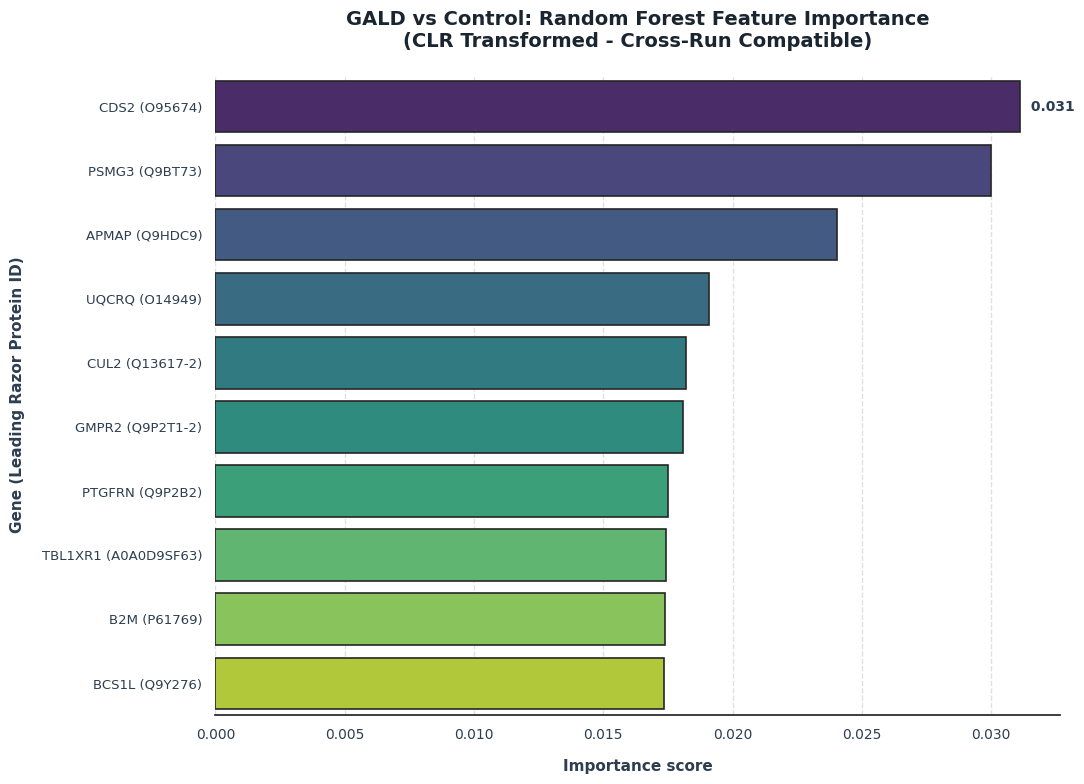

In [34]:
# Robust CLR-Transformed Random Forest Predictor (Cross-Run Compatible) 
import pandas as pd
import numpy as np
import textwrap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Robust Cross-Run CLR Random Forest Predictor ---")

# ==========================================
# 1. HELPER FUNCTIONS FOR CROSS-RUN PREP
# ==========================================

def extract_razor_protein(protein_group_string):
    """Extracts the leading razor protein (the first ID) from a MaxQuant group string."""
    return str(protein_group_string).split(';')[0].strip()

def prepare_raw_dataset(df, intensity_col='Razor Intensity', target_groups=['GALD', 'Healthy donor', 'GALD_spouse']):
    """Filters cohorts, extracts razor proteins, and returns a RAW intensity matrix."""
    df_clean = df.copy()
    
    # 1. Extract stable identifier
    df_clean['Razor_Protein_ID'] = df_clean['Protein Group'].apply(extract_razor_protein)
    
    # 2. Filter groups and standardize to GALD vs Control
    filtered_df = df_clean[df_clean['Group'].isin(target_groups)].copy()
    filtered_df['Group'] = filtered_df['Group'].replace({'Healthy donor': 'Control', 'GALD_spouse': 'Control'})
    
    # 3. Pivot data
    X_raw = filtered_df.pivot_table(index=['Sample', 'Group'], columns='Razor_Protein_ID', values=intensity_col, aggfunc='sum')
    
    # 4. Extract labels and reset index
    y_labels = X_raw.index.get_level_values('Group')
    X_raw.index = X_raw.index.get_level_values('Sample')
    
    # Fill NAs with 0
    return X_raw.fillna(0), y_labels

def align_features_to_model(X_new, training_features):
    """
    Ensures a new dataset has the exact same columns as the training dataset.
    Missing proteins are added as 0. Extra proteins are dropped.
    *CRITICAL*: Must be done BEFORE CLR transformation!
    """
    return X_new.reindex(columns=training_features, fill_value=0)

def apply_clr_transformation(X):
    """
    Applies Centered Log-Ratio (CLR) transformation.
    Adds a pseudo-count of 1 to handle zeros.
    """
    # Add pseudo-count to handle log(0)
    X_pseudo = X + 1
    
    # Natural log transformation
    X_log = np.log(X_pseudo)
    
    # Subtract the row mean (mean across all proteins for a given sample)
    X_clr = X_log.sub(X_log.mean(axis=1), axis=0)
    
    return X_clr

# ==========================================
# 2. PREPARE TRAINING DATA (RUN 6)
# ==========================================
print("\nPreparing Run 6 (Training Data)...")

# Get RAW data first
X_r6_raw, y_r6 = prepare_raw_dataset(master_prot_run6_maxQuant_df)

# Save the exact feature list BEFORE CLR so we can align future runs
TRAINING_FEATURES = X_r6_raw.columns

# Apply CLR
X_r6_clr = apply_clr_transformation(X_r6_raw)

# Standard 80/20 split on Run 6 for internal validation
RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_r6_clr, y_r6, test_size=0.20, random_state=RANDOM_SEED, stratify=y_r6
)

print(f"Training on {len(X_train)} samples from Run 6.")

# ==========================================
# 3. TRAIN THE RANDOM FOREST
# ==========================================
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, class_weight='balanced')
rf_clf.fit(X_train, y_train)

# Internal Validation on Run 6 20% holdout
y_pred_test = rf_clf.predict(X_test)
print(f"Run 6 Internal Holdout Accuracy: {accuracy_score(y_test, y_pred_test) * 100:.1f}%")

# ==========================================
# 4. TEST MODEL ON ENTIRELY NEW DATASETS (RUN 4 & 5)
# ==========================================
print("\n--- Testing Model on Unseen Experiments (CLR Transformed) ---")

# Run 4
try:
    X_r4_raw, y_r4 = prepare_raw_dataset(master_prot_run4_maxQuant_df)
    X_r4_aligned = align_features_to_model(X_r4_raw, TRAINING_FEATURES) # Align FIRST
    X_r4_clr = apply_clr_transformation(X_r4_aligned)                   # CLR SECOND
    r4_predictions = rf_clf.predict(X_r4_clr)
    print(f"Run 4 Accuracy ({len(y_r4)} samples): {accuracy_score(y_r4, r4_predictions) * 100:.1f}%")
except NameError:
    print("Run 4 dataframe not found in memory.")

# Run 5
try:
    X_r5_raw, y_r5 = prepare_raw_dataset(master_prot_run5_maxQuant_df)
    X_r5_aligned = align_features_to_model(X_r5_raw, TRAINING_FEATURES) # Align FIRST
    X_r5_clr = apply_clr_transformation(X_r5_aligned)                   # CLR SECOND
    r5_predictions = rf_clf.predict(X_r5_clr)
    print(f"Run 5 Accuracy ({len(y_r5)} samples): {accuracy_score(y_r5, r5_predictions) * 100:.1f}%")
except NameError:
    print("Run 5 dataframe not found in memory.")

# ==========================================
# 5. EXTRACT THE "SMOKING GUNS" (Feature Importance)
# ==========================================
importances = rf_clf.feature_importances_

importance_df = pd.DataFrame({
    'Razor_Protein_ID': TRAINING_FEATURES,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Keep top 10 most important proteins
top_features = importance_df[importance_df['Importance'] > 0].head(10).copy()

# Trace back to descriptions and genes (using Run 6 dictionary)
df6_dict = master_prot_run6_maxQuant_df.copy()
df6_dict['Razor_Protein_ID'] = df6_dict['Protein Group'].apply(extract_razor_protein)
info_dict = df6_dict[['Razor_Protein_ID', 'Protein Description', 'Gene']].drop_duplicates(subset='Razor_Protein_ID')

top_features = pd.merge(top_features, info_dict, on='Razor_Protein_ID', how='left')

print("\n====================================================================")
print("🌳 TOP CLR PROTEINS DRIVING THE DECISION TREES 🌳")
print("====================================================================")
display(top_features)

# ==========================================
# 6. VISUALIZE FEATURE IMPORTANCE 
# ==========================================
sns.set_theme(style="white")

def wrap_protein_names(row):
    """Combines Gene and Razor ID for a clean plot label"""
    gene = row['Gene'] if pd.notna(row['Gene']) else 'Unknown'
    label = f"{gene} ({row['Razor_Protein_ID']})"
    return '\n'.join(textwrap.wrap(label, width=40))

top_features['Plot Label'] = top_features.apply(wrap_protein_names, axis=1)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=top_features, 
    x='Importance', 
    y='Plot Label', 
    palette='viridis', 
    edgecolor='.15', 
    linewidth=1.2,
    ax=ax
)

ax.bar_label(ax.containers[0], fmt=' %.3f', padding=4, color='#2c3e50', weight='semibold', size=10)

ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#cccccc')
ax.set_axisbelow(True) 
sns.despine(left=True, bottom=False)

plt.yticks(fontsize=9.5, color='#2c3e50', weight='medium')
plt.xticks(fontsize=10, color='#2c3e50')

plt.title("GALD vs Control: Random Forest Feature Importance\n(CLR Transformed - Cross-Run Compatible)", 
          weight='bold', fontsize=14, pad=20, color='#1a252f')
plt.xlabel("Importance score", fontsize=11, labelpad=12, weight='semibold', color='#2c3e50')
plt.ylabel("Gene (Leading Razor Protein ID)", fontsize=11, labelpad=12, weight='semibold', color='#2c3e50')

plt.tight_layout()
plt.show()

### **Step 4 - Volcano plot**:

**With imputation:**

--- Running Global Volcano Pipeline (Exact Imputation Parity) ---

⚙️ PREPPING & IMPUTING: Run 4
Imputed 0 missing values for Run 4.

📊 Plotting Run 4: GALD vs Healthy mother...


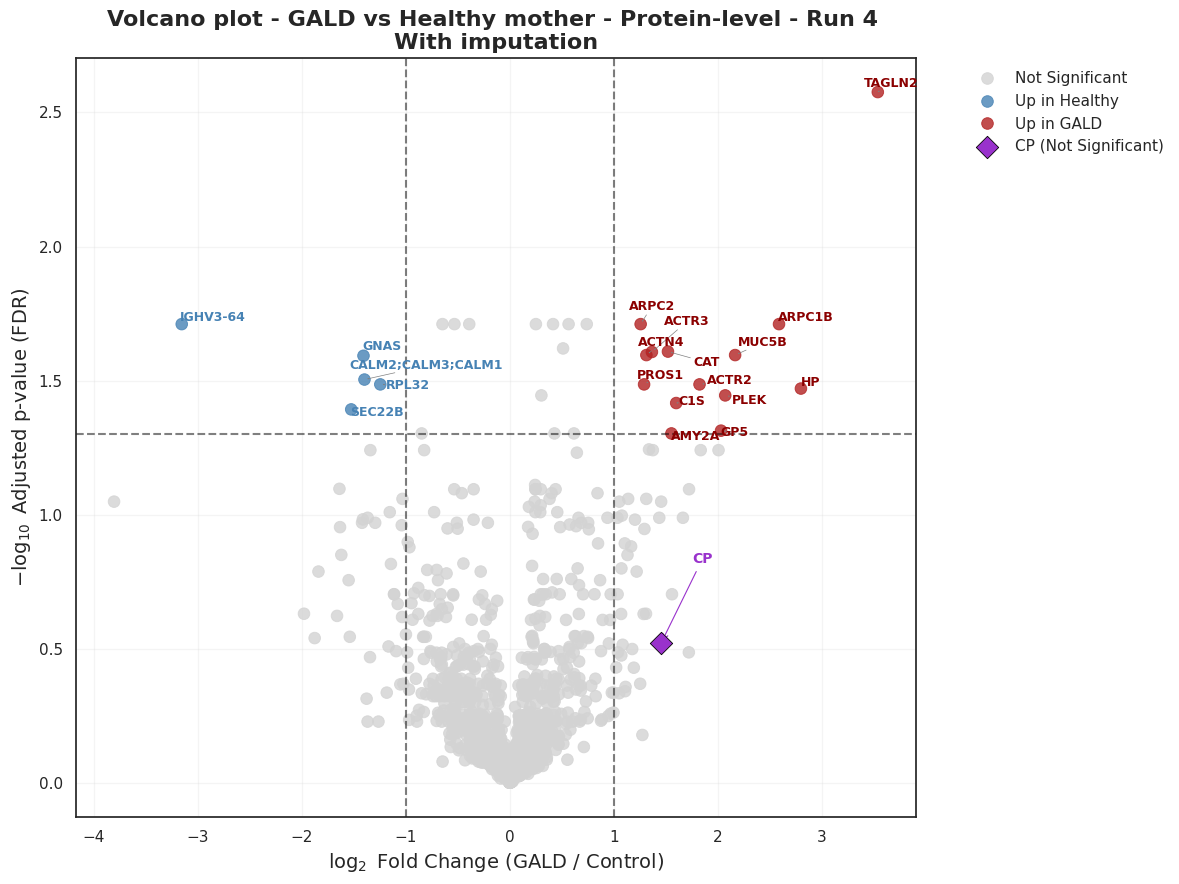

⏩ Skipping GALD vs Spouses (Cohort missing)

⚙️ PREPPING & IMPUTING: Run 5
Imputed 0 missing values for Run 5.
⏩ Skipping GALD vs Healthy mother (Cohort missing)

📊 Plotting Run 5: GALD vs Spouses...


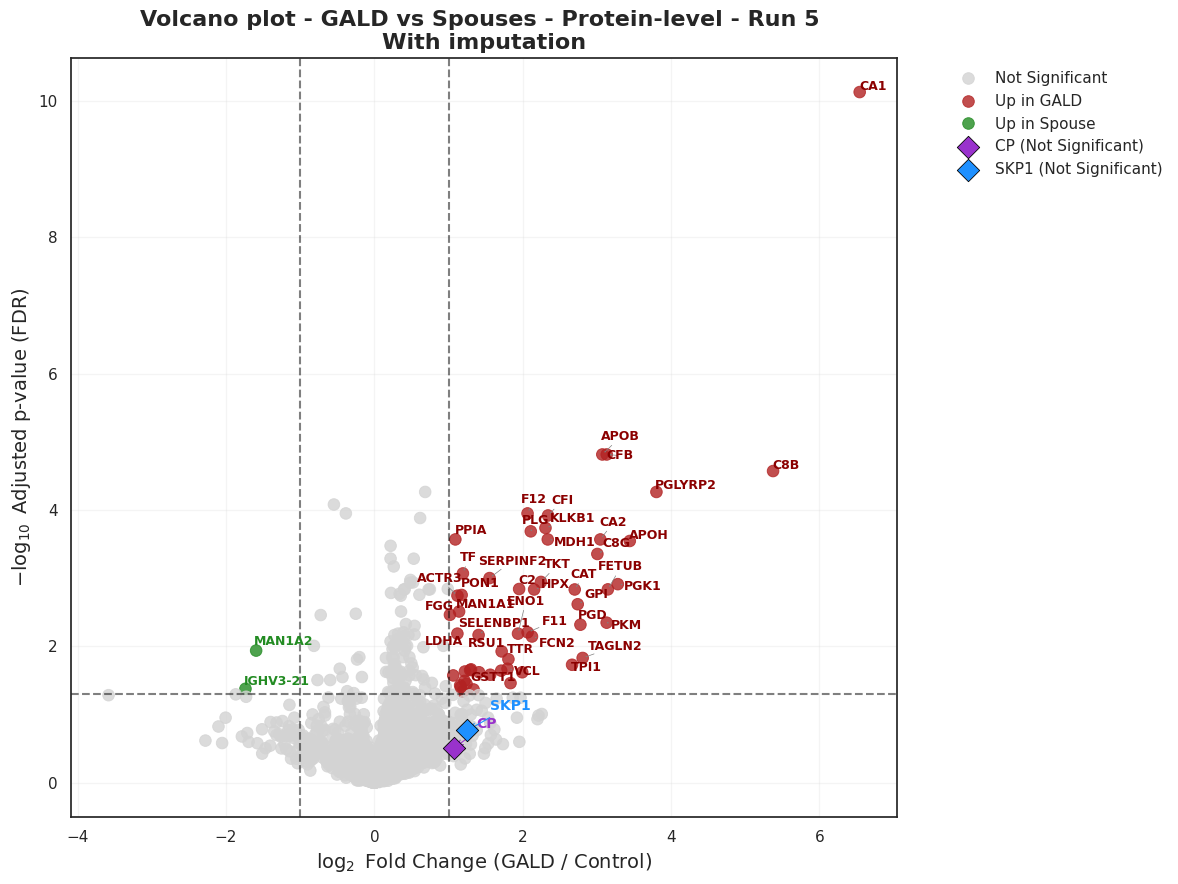


⚙️ PREPPING & IMPUTING: Run 6
Imputed 0 missing values for Run 6.

📊 Plotting Run 6: GALD vs Healthy mother...


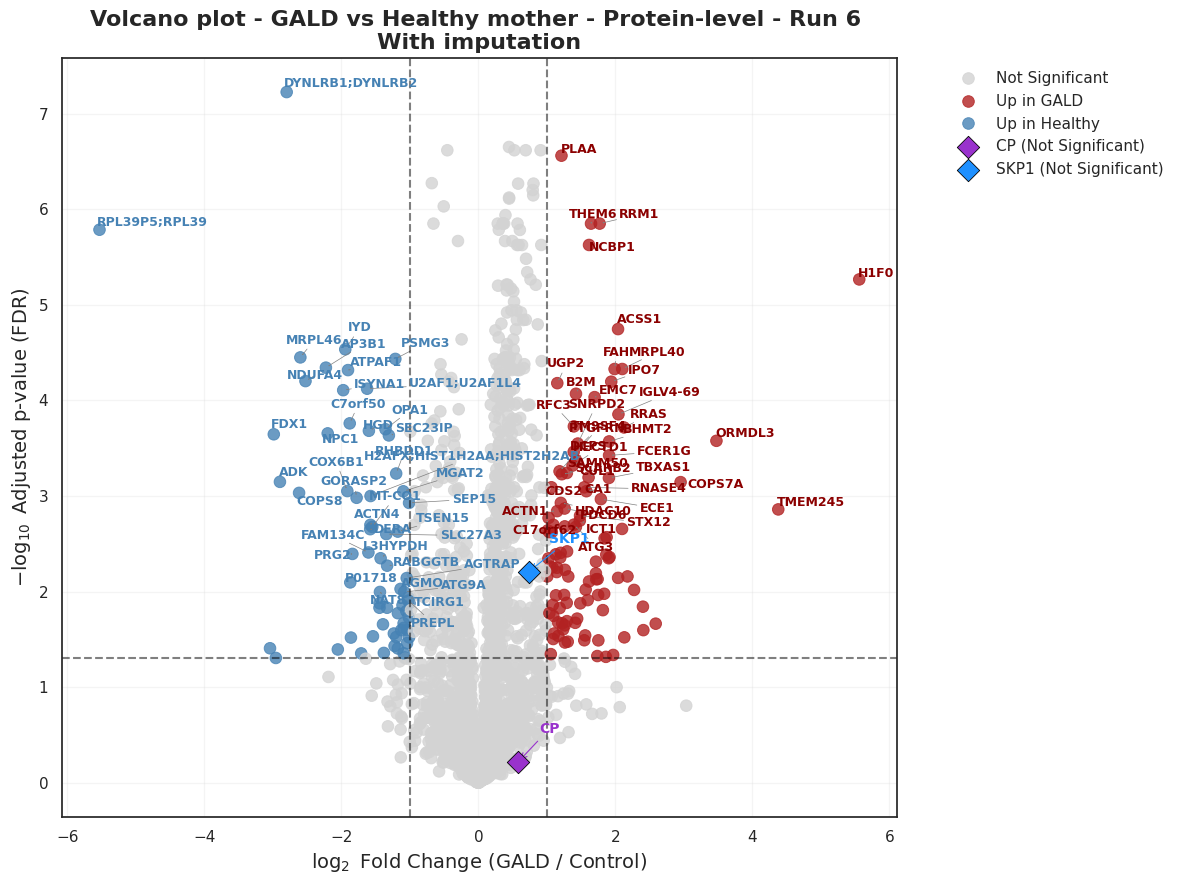


📊 Plotting Run 6: GALD vs Spouses...


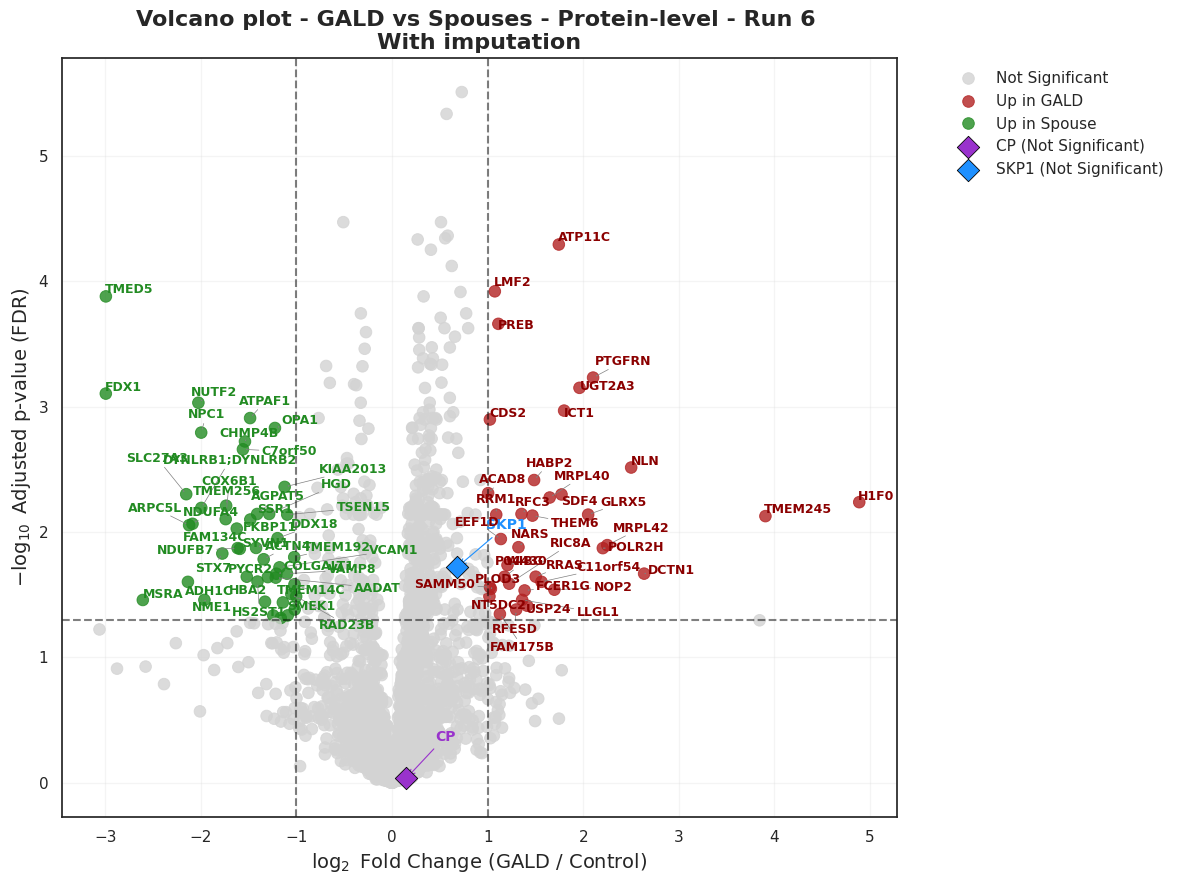


🏆 MASTER SIGNIFICANT GENES LIST (IMPUTED - ALL RUNS)


,Experiment_Run,Comparison,Protein Group,Gene,Significance,Log2_Fold_Change,P_Value,Adjusted_P_Value
13,Run 4,GALD vs Healthy mother,P37802;X6RJP6;P37802-2;C9J5W6;Q9UI15,TAGLN2,Up in GALD,3.538278,0.000002,0.002654
0,Run 4,GALD vs Healthy mother,A0A075B6Q5,IGHV3-64,Up in Healthy,-3.156935,0.000070,0.019469
4,Run 4,GALD vs Healthy mother,O15143;C9JEY1;C9K057;F8VXW2;C9JBJ7;C9JTT6;C9JM51,ARPC1B,Up in GALD,2.588088,0.000103,0.019469
5,Run 4,GALD vs Healthy mother,O15144;H7C3F9;C9JTV5;G5E9J0,ARPC2,Up in GALD,1.257140,0.000159,0.019469
8,Run 4,GALD vs Healthy mother,P04040,CAT,Up in GALD,1.519932,0.000284,0.024646
...,...,...,...,...,...,...,...,...
265,Run 6,GALD vs Spouses,D6RJG8;D6RBY0;Q8TAC1;Q8TAC1-2,RFESD,Up in GALD,1.299104,0.008128,0.041544
304,Run 6,GALD vs Spouses,Q15018,FAM175B,Up in GALD,1.128197,0.009208,0.045059
309,Run 6,GALD vs Spouses,Q86YS6;Q86YS6-2,RAB43,Up in Spouse,-1.090982,0.009512,0.046263
264,Run 6,GALD vs Spouses,D6RBW8;D6RAC7;D6RB17;A0A7I2YQS2;A0A7I2V3E2;Q9U...,G3BP2,Up in Spouse,-1.242605,0.009567,0.046344


In [35]:
#Volcano plot for all experiments
#With imputation

# Master Volcano Plot Pipeline: All Runs & All Cohort Comparisons (IMPUTED DATA)
# EXACT MATCH to Standalone script: Imputes globally before pairwise statistical testing.

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

print("--- Running Global Volcano Pipeline (Exact Imputation Parity) ---")

# ==========================================
# CONFIGURATION
# ==========================================
SHIFT = 1.8
SCALE = 0.3
lfc_threshold = 1.0
p_adj_threshold = 0.05
log10_p_threshold = -np.log10(p_adj_threshold)

runs = [
    ('Run 4', master_prot_run4_maxQuant_df),
    ('Run 5', master_prot_run5_maxQuant_df),
    ('Run 6', master_prot_run6_maxQuant_df)
]

# (Control Group Name, Display Name, Plot Color, Significance Label)
comparisons = [
    ('Healthy donor', 'Healthy mother', 'steelblue', 'Up in Healthy'),
    ('GALD_spouse', 'Spouses', 'forestgreen', 'Up in Spouse')
]

all_significant_hits = []

# ==========================================
# MASTER LOOP
# ==========================================
for run_name, df_raw in runs:
    
    print(f"\n==========================================")
    print(f"⚙️ PREPPING & IMPUTING: {run_name}")
    print(f"==========================================")
    
    # 1. Extract Descriptions once per run
    cols_to_keep = ['Protein Group', 'Protein Description']
    if 'Gene' in df_raw.columns:
        cols_to_keep.insert(1, 'Gene')
    info_dict = df_raw[cols_to_keep].drop_duplicates(subset='Protein Group')
    
    # 2. Pivot & Log2 Transform the ENTIRE run (Global Imputation)
    raw_df = df_raw.pivot_table(index='Protein Group', columns='Sample', values='Razor Intensity', aggfunc='sum')
    log_df = np.log2(raw_df.replace(0, np.nan))
    
    # 3. Stochastic Imputation (Globally)
    np.random.seed(42) # Seed set here so Run 6 exactly matches the standalone script
    imputed_df = log_df.copy()
    
    for col in imputed_df.columns:
        sample_data = imputed_df[col].dropna()
        if sample_data.empty: continue
        
        sample_median = sample_data.median()
        sample_sd = sample_data.std()
        num_nans = imputed_df[col].isna().sum()
        
        if num_nans > 0:
            fake_data = np.random.normal(
                loc=sample_median - (SHIFT * sample_sd),
                scale=sample_sd * SCALE,
                size=num_nans
            )
            imputed_df.loc[imputed_df[col].isna(), col] = fake_data
            
    print(f"Imputed {imputed_df.isna().sum().sum()} missing values for {run_name}.")

    # ==========================================
    # PAIRWISE COMPARISONS
    # ==========================================
    for ctrl_group, ctrl_display, ctrl_color, ctrl_label in comparisons:
        
        gald_cols = df_raw[df_raw['Group'] == 'GALD']['Sample'].unique().tolist()
        ctrl_cols = df_raw[df_raw['Group'] == ctrl_group]['Sample'].unique().tolist()
        
        if not gald_cols or not ctrl_cols:
            print(f"⏩ Skipping GALD vs {ctrl_display} (Cohort missing)")
            continue
            
        print(f"\n📊 Plotting {run_name}: GALD vs {ctrl_display}...")

        # 4. Statistical Testing
        log2_fc = imputed_df[gald_cols].mean(axis=1) - imputed_df[ctrl_cols].mean(axis=1)
        
        with np.errstate(invalid='ignore'):
            _, p_vals = ttest_ind(imputed_df[gald_cols], imputed_df[ctrl_cols], axis=1, equal_var=False)
            
        _, p_adj, _, _ = multipletests(pd.Series(p_vals).fillna(1.0), method='fdr_bh')

        results_df = pd.DataFrame({
            'Protein Group': imputed_df.index,
            'Log2_Fold_Change': log2_fc.values,
            'P_Value': p_vals,
            'Adjusted_P_Value': p_adj,
            '-Log10_P_Adj': -np.log10(p_adj)
        })

        results_df = pd.merge(results_df, info_dict, on='Protein Group', how='left')

        # 5. Significance Categorization
        def categorize(row):
            if row['-Log10_P_Adj'] >= log10_p_threshold and row['Log2_Fold_Change'] >= lfc_threshold:
                return 'Up in GALD'
            elif row['-Log10_P_Adj'] >= log10_p_threshold and row['Log2_Fold_Change'] <= -lfc_threshold:
                return ctrl_label
            else:
                return 'Not Significant'

        results_df['Significance'] = results_df.apply(categorize, axis=1)

        # 6. Save Significant Hits for Master Table
        sig_df = results_df[results_df['Significance'] != 'Not Significant'].copy()
        if not sig_df.empty:
            sig_df['Experiment_Run'] = run_name
            sig_df['Comparison'] = f"GALD vs {ctrl_display}"
            all_significant_hits.append(sig_df)

        # ==========================================
        # 7. DRAW THE VOLCANO PLOT
        # ==========================================
        fig, ax = plt.subplots(figsize=(12, 9))
        palette = {'Not Significant': 'lightgray', 'Up in GALD': 'firebrick', ctrl_label: ctrl_color}

        # Separate CP and SKP1
        cp_mask = results_df['Gene'] == 'CP' if 'Gene' in results_df.columns else pd.Series([False] * len(results_df))
        skp1_mask = results_df['Gene'] == 'SKP1' if 'Gene' in results_df.columns else pd.Series([False] * len(results_df))
        combined_mask = cp_mask | skp1_mask

        cp_row = results_df[cp_mask]
        skp1_row = results_df[skp1_mask]
        non_target_df = results_df[~combined_mask]

        # Plot background dots
        sns.scatterplot(
            data=non_target_df, x='Log2_Fold_Change', y='-Log10_P_Adj',
            hue='Significance', palette=palette, s=70, alpha=0.8,
            edgecolor=None, ax=ax
        )

        # Highlight CP
        if not cp_row.empty:
            cp_sig = cp_row['Significance'].values[0]
            ax.scatter(cp_row['Log2_Fold_Change'], cp_row['-Log10_P_Adj'], color='darkorchid', marker='D', s=130, zorder=5, edgecolor='black', linewidth=0.6, label=f'CP ({cp_sig})')
            ax.annotate('CP', xy=(cp_row['Log2_Fold_Change'].values[0], cp_row['-Log10_P_Adj'].values[0]),
                        xytext=(cp_row['Log2_Fold_Change'].values[0] + 0.3, cp_row['-Log10_P_Adj'].values[0] + 0.3),
                        fontsize=10, weight='bold', color='darkorchid', arrowprops=dict(arrowstyle='->', color='darkorchid', lw=0.8))

        # Highlight SKP1
        if not skp1_row.empty:
            skp1_sig = skp1_row['Significance'].values[0]
            ax.scatter(skp1_row['Log2_Fold_Change'], skp1_row['-Log10_P_Adj'], color='dodgerblue', marker='D', s=130, zorder=5, edgecolor='black', linewidth=0.6, label=f'SKP1 ({skp1_sig})')
            ax.annotate('SKP1', xy=(skp1_row['Log2_Fold_Change'].values[0], skp1_row['-Log10_P_Adj'].values[0]),
                        xytext=(skp1_row['Log2_Fold_Change'].values[0] + 0.3, skp1_row['-Log10_P_Adj'].values[0] + 0.3),
                        fontsize=10, weight='bold', color='dodgerblue', arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=0.8))

        # Threshold lines
        ax.axvline(x=lfc_threshold, color='black', linestyle='--', alpha=0.5)
        ax.axvline(x=-lfc_threshold, color='black', linestyle='--', alpha=0.5)
        ax.axhline(y=log10_p_threshold, color='black', linestyle='--', alpha=0.5)

        # Text Labels (GALD side - Red) - removed .head(10) to label all hits
        top_hits_gald = results_df[results_df['Significance'] == 'Up in GALD'].sort_values(by=['-Log10_P_Adj', 'Log2_Fold_Change'], ascending=[False, False]).head(40)
        texts = []
        for _, row in top_hits_gald.iterrows():
            label_name = row['Gene'] if ('Gene' in row and pd.notna(row['Gene'])) else row['Protein Group']
            if label_name in ['CP', 'SKP1']: continue 
            texts.append(ax.text(row['Log2_Fold_Change'], row['-Log10_P_Adj'], str(label_name), fontsize=9, weight='bold', color='darkred'))

        # Text Labels (Control side - Dynamic Color) - removed .head(10) to label all hits
        top_hits_ctrl = results_df[results_df['Significance'] == ctrl_label].sort_values(by=['-Log10_P_Adj', 'Log2_Fold_Change'], ascending=[False, False]).head(40)
        for _, row in top_hits_ctrl.iterrows():
            label_name = row['Gene'] if ('Gene' in row and pd.notna(row['Gene'])) else row['Protein Group']
            if label_name in ['CP', 'SKP1']: continue 
            texts.append(ax.text(row['Log2_Fold_Change'], row['-Log10_P_Adj'], str(label_name), fontsize=9, weight='bold', color=ctrl_color))

        try:
            adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), ax=ax)
        except NameError:
            pass

        # Formatting
        ax.set_title(f"Volcano plot - GALD vs {ctrl_display} - Protein-level - {run_name} \nWith imputation", fontsize=16, weight='bold')
        ax.set_xlabel(r'$\log_2$ Fold Change (GALD / Control)', fontsize=14)
        ax.set_ylabel(r'$-\log_{10}$ Adjusted p-value (FDR)', fontsize=14)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
        ax.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()

# ==========================================
# 8. COMPILE MASTER RESULTS DATAFRAME
# ==========================================
print("\n====================================================================")
print("🏆 MASTER SIGNIFICANT GENES LIST (IMPUTED - ALL RUNS)")
print("====================================================================")

if all_significant_hits:
    master_sig_df = pd.concat(all_significant_hits, ignore_index=True)
    
    # Reorder columns
    master_sig_df = master_sig_df[['Experiment_Run', 'Comparison', 'Protein Group', 'Gene', 'Significance', 'Log2_Fold_Change', 'P_Value', 'Adjusted_P_Value']]
    
    # Sort by Run -> Comparison -> Adjusted P-Value
    master_sig_df = master_sig_df.sort_values(by=['Experiment_Run', 'Comparison', 'Adjusted_P_Value'], ascending=[True, True, True])
    
    display(master_sig_df)
else:
    print("No significant hits found across any experiments using the current thresholds.")
    master_sig_df = pd.DataFrame()

In [36]:
#What are the volcano plot values of the CP protein group: 
results_df_fixed = results_df.reset_index().copy()
results_df_fixed[results_df_fixed["Protein Group"].str.contains("H7C5R1")]


,index,Protein Group,Log2_Fold_Change,P_Value,Adjusted_P_Value,-Log10_P_Adj,Gene,Protein Description,Significance
830,830,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5,0.150424,0.853138,0.920036,0.036195,CP,sp|P00450|CERU_HUMAN Ceruloplasmin OS=Homo sap...,Not Significant


In [37]:
#What are the volcano plot values of the SPK1 protein group: 
results_df_fixed[results_df_fixed["Protein Group"].str.contains("E5RJR5")]

,index,Protein Group,Log2_Fold_Change,P_Value,Adjusted_P_Value,-Log10_P_Adj,Gene,Protein Description,Significance
406,406,E5RI56;E5RJR5;P63208,0.682329,0.002485,0.019057,1.719957,SKP1,"tr|E5RI56|E5RI56_HUMAN readthrough, S-phase ki...",Not Significant


**When imputing the datasets, and making volcano plots - what is the overlap?**

--- Generating 4-Way Venn Diagram (Imputed Datasets) ---
Run 4 (vs Healthy) imputed distinct proteins:  60
Run 5 (vs Spouse) imputed distinct proteins:   334
Run 6 (vs Healthy) imputed distinct proteins:  544
Run 6 (vs Spouse) imputed distinct proteins:   143


<Figure size 1000x1000 with 0 Axes>

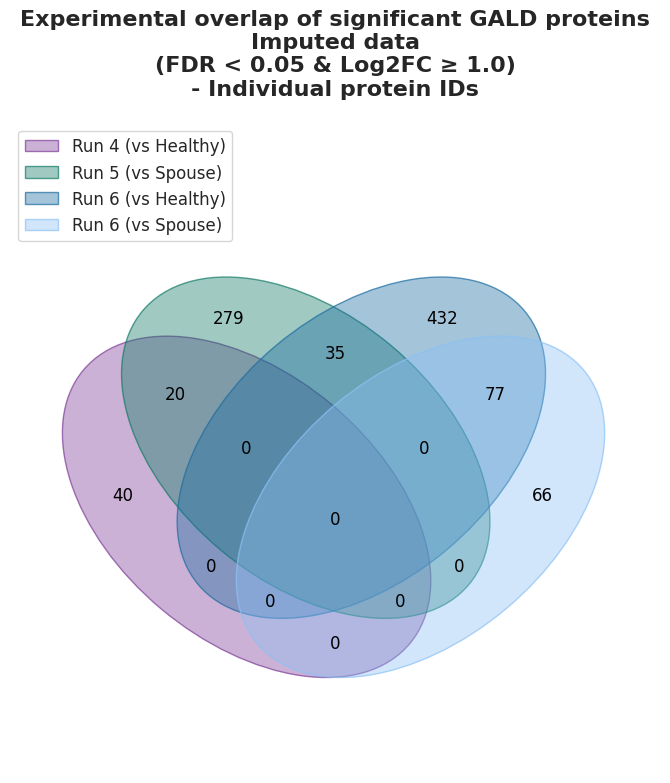


🔥 CORE OVERLAP (Found in all 4 IMPUTED filters): 0 individual proteins
No individual proteins survived all 4 strict statistical filters concurrently in the imputed dataset.


In [38]:
# =====================================================================
# Overlap of significant volcano plot proteins (IMPUTED DATA)
# 4-Way Venn diagram of individual proteins from GALD-upregulated targets
# =====================================================================

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from venn import venn

print("--- Generating 4-Way Venn Diagram (Imputed Datasets) ---")

# ==========================================
# 0. MASTER DICTIONARY FOR TRACING GENES
# ==========================================
# We will populate this to map individual proteins back to their genes for the final printout
protein_to_gene_map = {}

def update_gene_map(df):
    """Saves the Gene and Protein Group info for later lookup."""
    if 'Gene' not in df.columns:
        return
    for _, row in df[['Protein Group', 'Gene']].drop_duplicates().dropna(subset=['Protein Group']).iterrows():
        group = str(row['Protein Group'])
        gene = str(row['Gene'])
        for p in group.split(';'):
            protein_to_gene_map[p.strip()] = {'Gene': gene, 'Parent Group': group}

# Update map with all available dataframes
# (Assuming you have these DataFrames loaded in your environment)
update_gene_map(master_prot_run4_maxQuant_df)
update_gene_map(master_prot_run5_maxQuant_df)
update_gene_map(master_prot_run6_maxQuant_df)

# ==========================================
# 1. THE IMPUTATION & STATS ENGINE
# ==========================================
def extract_imputed_gald_targets(df, control_group_name):
    """
    Takes a raw MaxQuant dataframe, performs stochastic imputation, 
    calculates stats vs the specified control group, and returns 
    a set of individual proteins significantly upregulated in GALD.
    """
    # 1. Identify Columns
    gald_cols = df[df['Group'] == 'GALD']['Sample'].unique().tolist()
    control_cols = df[df['Group'] == control_group_name]['Sample'].unique().tolist()
    
    if not gald_cols or not control_cols:
        print(f"⚠️ Warning: Missing samples for GALD vs {control_group_name}. Returning empty set.")
        return set()

    # 2. Pivot to Wide Format
    raw_df = df.pivot_table(index='Protein Group', columns='Sample', values='Razor Intensity', aggfunc='sum')
    
    # 3. Log2 Transform & Impute
    log_df = np.log2(raw_df.replace(0, np.nan))
    imputed_df = log_df.copy()
    
    SHIFT = 1.8
    SCALE = 0.3
    np.random.seed(42) # Keep seed consistent for reproducible imputation
    
    for col in imputed_df.columns:
        if col not in gald_cols + control_cols:
            continue # Skip samples not in this specific comparison
            
        sample_data = imputed_df[col].dropna()
        if sample_data.empty: continue
            
        sample_median = sample_data.median()
        sample_sd = sample_data.std()
        num_nans = imputed_df[col].isna().sum()
        
        if num_nans > 0:
            fake_data = np.random.normal(
                loc=sample_median - (SHIFT * sample_sd),
                scale=sample_sd * SCALE,
                size=num_nans
            )
            imputed_df.loc[imputed_df[col].isna(), col] = fake_data
            
    # 4. Statistical Testing
    log2_fc = imputed_df[gald_cols].mean(axis=1) - imputed_df[control_cols].mean(axis=1)
    
    # Run T-test (suppress warnings for rows with 0 variance)
    with np.errstate(invalid='ignore'):
        _, p_vals = ttest_ind(imputed_df[gald_cols], imputed_df[control_cols], axis=1, equal_var=False)
        
    _, p_adj, _, _ = multipletests(pd.Series(p_vals).fillna(1.0), method='fdr_bh')
    
    # 5. Filter for "Up in GALD" (LFC >= 1.0 & FDR < 0.05)
    sig_mask = (log2_fc >= 1.0) & (p_adj < 0.05)
    sig_protein_groups = imputed_df.index[sig_mask]
    
    # 6. Split into individual proteins
    individual_proteins = set()
    for group in sig_protein_groups:
        prots = [p.strip() for p in str(group).split(';')]
        individual_proteins.update(prots)
        
    return individual_proteins

# ==========================================
# 2. GENERATE THE 4 TARGET SETS
# ==========================================
# Note: Ensure the string 'Healthy' matches exactly what is in your df['Group'] column. 
# It might be 'Healthy_mother' or 'Healthy' depending on your annotation file.
r4_vs_healthy = extract_imputed_gald_targets(master_prot_run4_maxQuant_df, 'Healthy donor')
r5_vs_spouse  = extract_imputed_gald_targets(master_prot_run5_maxQuant_df, 'GALD_spouse')
r6_vs_healthy = extract_imputed_gald_targets(master_prot_run6_maxQuant_df, 'Healthy donor')
r6_vs_spouse  = extract_imputed_gald_targets(master_prot_run6_maxQuant_df, 'GALD_spouse')

print(f"Run 4 (vs Healthy) imputed distinct proteins:  {len(r4_vs_healthy)}")
print(f"Run 5 (vs Spouse) imputed distinct proteins:   {len(r5_vs_spouse)}")
print(f"Run 6 (vs Healthy) imputed distinct proteins:  {len(r6_vs_healthy)}")
print(f"Run 6 (vs Spouse) imputed distinct proteins:   {len(r6_vs_spouse)}")

# ==========================================
# 3. FORMAT DATA FOR PYVENN
# ==========================================
venn_dict = {
    "Run 4 (vs Healthy)": r4_vs_healthy,
    "Run 5 (vs Spouse)": r5_vs_spouse,
    "Run 6 (vs Healthy)": r6_vs_healthy,
    "Run 6 (vs Spouse)": r6_vs_spouse
}

# ==========================================
# 4. PLOT THE VENN DIAGRAM
# ==========================================
plt.figure(figsize=(10, 10))
custom_colors = ["#7D3C98", "#117A65", "#1B6CA1", "#8CC1F5"]

venn(
    venn_dict, 
    cmap=custom_colors, 
    fmt="{size}", 
    fontsize=12, 
    legend_loc="upper left"
)

plt.title("Experimental overlap of significant GALD proteins\nImputed data\n(FDR < 0.05 & Log2FC ≥ 1.0)\n- Individual protein IDs", 
          fontsize=16, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# ==========================================
# 5. PRINT THE ULTIMATE CORE OVERLAP
# ==========================================
core_antigens = r4_vs_healthy & r5_vs_spouse & r6_vs_healthy & r6_vs_spouse

print("\n=====================================================")
print(f"🔥 CORE OVERLAP (Found in all 4 IMPUTED filters): {len(core_antigens)} individual proteins")
print("=====================================================")

if len(core_antigens) > 0:
    for target in core_antigens:
        # Retrieve info from our master lookup dictionary
        info = protein_to_gene_map.get(target, {'Gene': 'Unknown', 'Parent Group': 'Unknown'})
        
        print(f"🎯 Individual Hit: {target}")
        print(f"   Gene Name:      {info['Gene']}")
        print(f"   Parent Group:   {info['Parent Group']}\n")
else:
    print("No individual proteins survived all 4 strict statistical filters concurrently in the imputed dataset.")


In [39]:
#Inspecting the overlapping significant protein IDs for the volcano plot: 

# ==========================================
# 6. PRINT SPECIFIC RUN OVERLAPS
# ==========================================
overlap_4_5 = r4_vs_healthy & r5_vs_spouse
print(f"Overlap between Run 4 and Run 5: ({len(overlap_4_5)})")
for protein_id in overlap_4_5:
    # Look up the gene name, default to 'Unknown' if not found
    gene_name = protein_to_gene_map.get(protein_id, {}).get('Gene', 'Unknown')
    print(f"{protein_id} ({gene_name})", end=", ")

print() #Empty line for readability
print()

overlap_5_6_healthy = r5_vs_spouse & r6_vs_healthy
print(f"Overlap between Run 6 (healthy mothers) and Run 5: ({len(overlap_5_6_healthy)})")
for protein_id in overlap_5_6_healthy:
    # Look up the gene name, default to 'Unknown' if not found
    gene_name = protein_to_gene_map.get(protein_id, {}).get('Gene', 'Unknown')
    print(f"{protein_id} ({gene_name})", end=", ")

print() #Empty line for readability
print()

overlap_6 = r6_vs_spouse & r6_vs_healthy
print(f"Overlap between Run 6 (healthy mothers) and Run 6 (spouses): ({len(overlap_6)})")
for protein_id in overlap_6:
    # Look up the gene name, default to 'Unknown' if not found
    gene_name = protein_to_gene_map.get(protein_id, {}).get('Gene', 'Unknown')
    print(f"{protein_id} ({gene_name})", end=", ")

Overlap between Run 4 and Run 5: (20)
P04040 (CAT), P00738 (HP), P37802 (TAGLN2), J3KSV1 (HP), B4DXW1 (ACTR3), P00738-2 (HP), H0Y300 (HP), A0A0C4DGL8 (HP), H3BMJ7 (HP), F8WEW2 (ACTR3), J3KRH2 (HP), J3QR68 (HP), J3QQI8 (HP), P61158 (ACTR3), J3QLC9 (HP), X6RJP6 (TAGLN2), F8WDR7 (ACTR3), P37802-2 (TAGLN2), H3BS21 (HP), F8WE84 (ACTR3), 

Overlap between Run 6 (healthy mothers) and Run 5: (35)
E5RFE7 (CA1), E5RFL2 (CA1), H0Y3H6 (C2), P00915 (CA1), P03952 (KLKB1), A0A8Q3WKN5 (C2), E5RIF9 (CA1), E9PBC5 (KLKB1), A0A804HJ13 (FAH), H0YBE2 (CA1), C9J075 (KLKB1), F2Z3N2 (C2), A0A0G2JIE7 (C2), E5RJI8 (CA1), B4DQI1 (C2), E5RII2 (CA1), E5RG81 (CA1), P16930-2 (FAH), P06681 (C2), A0A804HJX2 (FAH), E9PDZ0 (C2), E5RH81 (CA1), E5RHP7 (CA1), P06681-2 (C2), P16930 (FAH), H0YLC7 (FAH), E5RGU8 (CA1), E5RHS7 (CA1), H0YAC1 (KLKB1), A0A0G2JL69 (C2), E5RG43 (CA1), P06681-3 (C2), A0A8Q3WKM6 (C2), B7Z4W2 (FAH), E5RJF6 (CA1), 

Overlap between Run 6 (healthy mothers) and Run 6 (spouses): (77)
H0Y3T6 (SDF4), Q9NPQ8-4

---
**No imputation volcano plots:**

--- Generating Perfectly Aligned Scatter Plots with Sample ID Labels ---


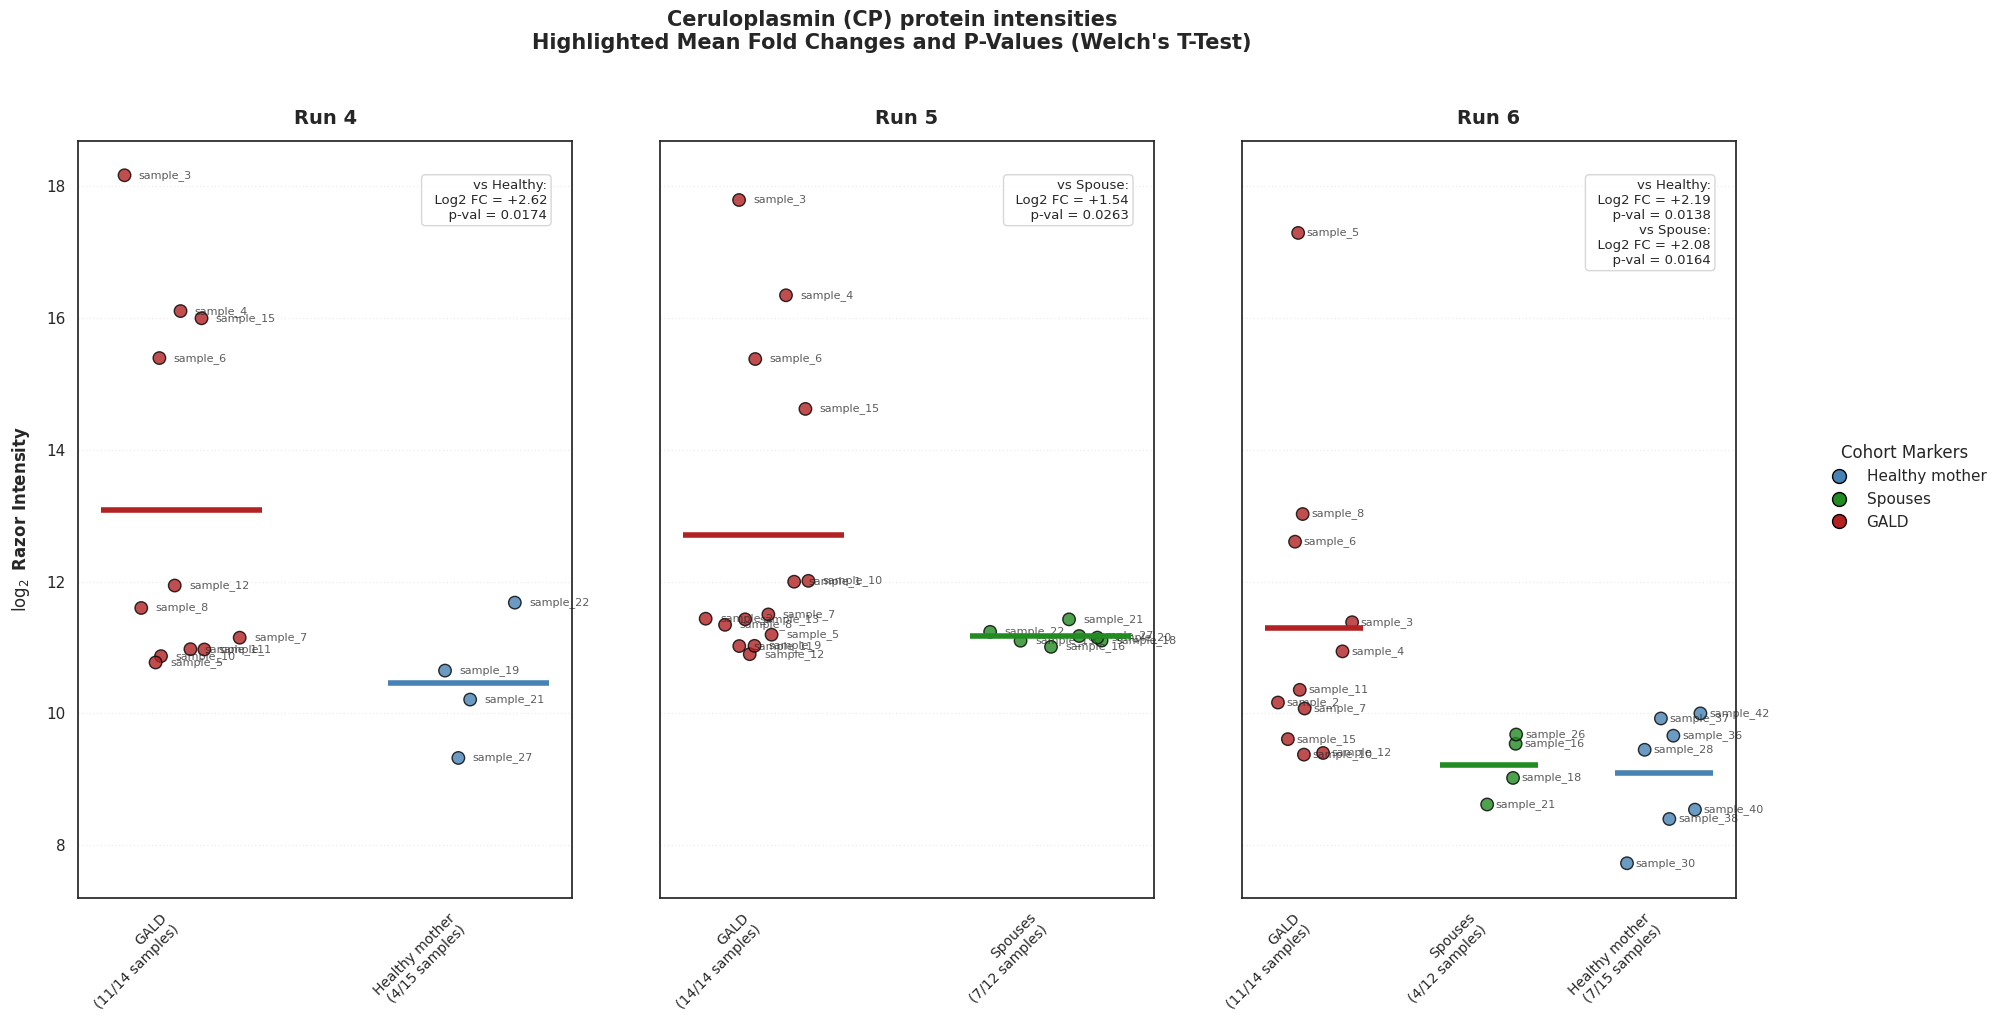

In [40]:
# Multi-panel scatter plot of CP intensities (Dynamic alignment, warnings cleared, dots labeled)
# No imputation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind

print("--- Generating Perfectly Aligned Scatter Plots with Sample ID Labels ---")

intensity_column = 'Razor Intensity' 

# ==========================================
# 1. COMPILE RAW TOTALS FOR TRUE DENOMINATORS
# ==========================================
run_totals = {
    'Run 4': master_prot_run4_maxQuant_df.groupby('Group')['Sample'].nunique().to_dict(),
    'Run 5': master_prot_run5_maxQuant_df.groupby('Group')['Sample'].nunique().to_dict(),
    'Run 6': master_prot_run6_maxQuant_df.groupby('Group')['Sample'].nunique().to_dict()
}

# ==========================================
# 2. FILTER AND ISOLATE POSITIVE CP MEASUREMENTS
# ==========================================
run_datasets = {}
for run_name, df_raw in [('Run 4', master_prot_run4_maxQuant_df), 
                        ('Run 5', master_prot_run5_maxQuant_df), 
                        ('Run 6', master_prot_run6_maxQuant_df)]:
    
    cp_filtered = df_raw[df_raw["Gene"] == "CP"].copy()
    cp_filtered = cp_filtered[cp_filtered[intensity_column] > 0].copy()
    cp_filtered['Log2_Intensity'] = np.log2(cp_filtered[intensity_column])
    run_datasets[run_name] = cp_filtered

# ==========================================
# 3. MULTI-PANEL PLOTTING (FIXED GEOMETRY)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True) # Widened slightly for text headroom

palette = {
    'Healthy donor': 'steelblue', 
    'GALD_spouse': 'forestgreen',
    'GALD': 'firebrick'
}

cohort_order = ['GALD', 'GALD_spouse', 'Healthy donor']
display_names = {'GALD': 'GALD', 'GALD_spouse': 'Spouses', 'Healthy donor': 'Healthy mother'}
runs = ['Run 4', 'Run 5', 'Run 6']

for i, run_name in enumerate(runs):
    ax = axes[i]
    df_panel = run_datasets[run_name]
    
    detected_counts = df_panel.groupby('Group')['Sample'].nunique().to_dict()
    totals_context = run_totals[run_name]
    
    present_cohorts = [cohort for cohort in cohort_order if cohort in totals_context]
    cohort_to_x = {cohort: idx for idx, cohort in enumerate(present_cohorts)}
    
    label_map = {}
    panel_order = []
    
    for cohort in present_cohorts:
        tot = totals_context[cohort]
        det = detected_counts.get(cohort, 0)
        pct = (det / tot * 100) if tot > 0 else 0.0
        
        custom_label = f"{display_names[cohort]}\n({det}/{tot} samples)"
        label_map[cohort] = custom_label
        panel_order.append(custom_label)
            
    df_panel_clean = df_panel[df_panel['Group'].isin(label_map.keys())].copy()
    df_panel_clean['Sub_Axis_Label'] = df_panel_clean['Group'].map(label_map)
    
    # Draw points with horizontal jitter intact
    sns.stripplot(
        data=df_panel_clean,
        x='Sub_Axis_Label',
        y='Log2_Intensity',
        hue='Group',
        order=panel_order,
        palette=palette,
        jitter=0.22,        
        size=9,
        edgecolor='black',
        linewidth=1,
        alpha=0.80,
        ax=ax,
        legend=False
    )
    
    # --------------------------------------------------------
    # ADD TEXT LABELS TO INDIVIDUAL SAMPLE POINTS
    # --------------------------------------------------------
    # Pulling information directly from the active subplot layer
    # to account for dynamic horizontal jitter shifts
    for collection in ax.collections:
        offsets = collection.get_offsets()
        if len(offsets) == 0:
            continue
        
        # Iterate over each point rendered on the canvas
        for idx, (pos_x, pos_y) in enumerate(offsets):
            # Locate the specific row in our slice to pull the exact Sample name string
            # Match strictly based on proximity to avoid sorting matrix overlaps
            matched_row = df_panel_clean.iloc[
                (df_panel_clean['Log2_Intensity'] - pos_y).abs().argsort()[:1]
            ]
            
            if not matched_row.empty:
                sample_name = str(matched_row['Sample'].values[0])
                
                # Render label with a minor right shift (+0.05) to keep text clear of the dot
                ax.text(
                    pos_x + 0.05, 
                    pos_y, 
                    sample_name, 
                    fontsize=8, 
                    alpha=0.75, 
                    verticalalignment='center'
                )

    # Calculate Means
    gald_vals = df_panel_clean[df_panel_clean['Group'] == 'GALD']['Log2_Intensity']
    spouse_vals = df_panel_clean[df_panel_clean['Group'] == 'GALD_spouse']['Log2_Intensity']
    healthy_vals = df_panel_clean[df_panel_clean['Group'] == 'Healthy donor']['Log2_Intensity']
    
    gald_mean = gald_vals.mean()
    spouse_mean = spouse_vals.mean() if len(spouse_vals) > 0 else np.nan
    healthy_mean = healthy_vals.mean() if len(healthy_vals) > 0 else np.nan
    
    # Position mean bars dynamically
    if 'GALD' in cohort_to_x:
        x_gald = cohort_to_x['GALD']
        ax.hlines(y=gald_mean, xmin=x_gald - 0.28, xmax=x_gald + 0.28, colors='firebrick', linestyles='-', lw=4, zorder=5)
        
    if 'GALD_spouse' in cohort_to_x and not np.isnan(spouse_mean):
        x_spouse = cohort_to_x['GALD_spouse']
        ax.hlines(y=spouse_mean, xmin=x_spouse - 0.28, xmax=x_spouse + 0.28, colors='forestgreen', linestyles='-', lw=4, zorder=5)
        
    if 'Healthy donor' in cohort_to_x and not np.isnan(healthy_mean):
        x_healthy = cohort_to_x['Healthy donor']
        ax.hlines(y=healthy_mean, xmin=x_healthy - 0.28, xmax=x_healthy + 0.28, colors='steelblue', linestyles='-', lw=4, zorder=5)
        
    # Calculate Welch's T-Test Stats
    stats_box_text = []
    if len(gald_vals) > 1 and len(healthy_vals) > 1:
        _, p_hd = ttest_ind(gald_vals, healthy_vals, equal_var=False)
        fc_hd = gald_mean - healthy_mean
        stats_box_text.append(f"vs Healthy:\n  Log2 FC = {fc_hd:+.2f}\n  p-val = {p_hd:.4f}")
        
    if len(gald_vals) > 1 and len(spouse_vals) > 1:
        _, p_sp = ttest_ind(gald_vals, spouse_vals, equal_var=False)
        fc_sp = gald_mean - spouse_mean
        stats_box_text.append(f"vs Spouse:\n  Log2 FC = {fc_sp:+.2f}\n  p-val = {p_sp:.4f}")
        
    # Text Annotation Boxes (Top-Right Aligned)
    if stats_box_text:
        annotation_str = "\n".join(stats_box_text)
        ax.text(
            0.95, 0.95, annotation_str,            
            transform=ax.transAxes, 
            verticalalignment='top', 
            horizontalalignment='right',          
            fontsize=9.5, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray')
        )

    # Lock ticks before writing labels
    ax.set_xticks(range(len(panel_order)))
    ax.set_xticklabels(panel_order, rotation=45, ha='right', fontsize=10)
    
    ax.set_title(run_name, fontsize=14, weight='bold', pad=12)
    ax.set_xlabel("", fontsize=10) 
    ax.grid(axis='y', alpha=0.3, linestyle=':')

# ==========================================
# 4. GLOBAL POLISHING
# ==========================================
axes[0].set_ylabel(r"$\log_2$ Razor Intensity", fontsize=12, weight='bold', labelpad=10)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
           markersize=10, markeredgecolor='black', label=display_names[group])
    for group, color in palette.items()
]
fig.legend(handles=legend_elements, title="Cohort Markers", bbox_to_anchor=(1.01, 0.6), loc='upper left', frameon=False)

plt.suptitle("Ceruloplasmin (CP) protein intensities\nHighlighted Mean Fold Changes and P-Values (Welch's T-Test)", fontsize=15, weight='bold', y=1.02)

plt.tight_layout()
plt.show()


--- Running Volcano Pipeline: GALD vs Spouses with Gene Export ---


/home/henrikk17/miniconda3/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


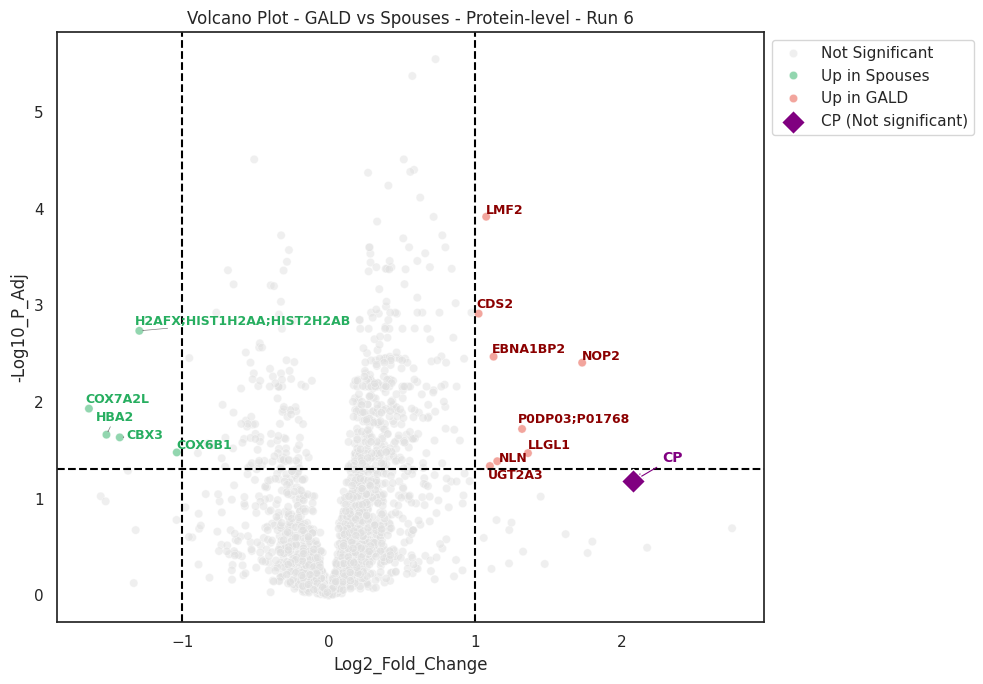

In [41]:
# Volcano Plot: GALD vs Spouses (Detection-Only)
# Highlighting CP in purple & SKP1 in blue + Exporting Significant Gene List
# If P-value (due to only 0 or 1 protein detection in one of the cohorts) can't be calculated, then CP/ SKP1 can't be plotted, and won't be highlighted in the plot. 

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure adjustText is imported if available (for the labels)
try:
    from adjustText import adjust_text
except ImportError:
    pass

print("--- Running Volcano Pipeline: GALD vs Spouses with Gene Export ---")

# ==========================================
# 1. FILTER & PIVOT
# ==========================================
df6 = master_prot_run6_maxQuant_df.copy()
df_subset = df6[df6['Group'].isin(['GALD', 'GALD_spouse'])].copy()
df_pos = df_subset[df_subset['Razor Intensity'] > 0].copy()

pivot_df = df_pos.pivot_table(index='Protein Group', columns='Sample', values='Razor Intensity', aggfunc='sum')
log_df = np.log2(pivot_df)

gald_cols = [s for s in log_df.columns if s in df_subset[df_subset['Group'] == 'GALD']['Sample'].values]
spouse_cols = [s for s in log_df.columns if s in df_subset[df_subset['Group'] == 'GALD_spouse']['Sample'].values]

# ==========================================
# 2. STATISTICAL TESTING
# ==========================================
log2_fc = log_df[gald_cols].mean(axis=1) - log_df[spouse_cols].mean(axis=1)
_, p_vals = ttest_ind(log_df[gald_cols], log_df[spouse_cols], axis=1, equal_var=False, nan_policy='omit')

results_df = pd.DataFrame({'Log2_Fold_Change': log2_fc, 'P_Value': p_vals}).dropna()
_, p_adj, _, _ = multipletests(results_df['P_Value'], method='fdr_bh')
results_df['Adjusted_P_Value'] = p_adj
results_df['-Log10_P_Adj'] = -np.log10(p_adj)

# ==========================================
# 3. SIGNIFICANCE FILTER
# ==========================================
results_df['Significance'] = 'Not Significant'
results_df.loc[(results_df['-Log10_P_Adj'] >= -np.log10(0.05)) & (results_df['Log2_Fold_Change'] >= 1.0), 'Significance'] = 'Up in GALD'
results_df.loc[(results_df['-Log10_P_Adj'] >= -np.log10(0.05)) & (results_df['Log2_Fold_Change'] <= -1.0), 'Significance'] = 'Up in Spouses'

# ==========================================
# 4. MAP GENES & EXPORT
# ==========================================
gene_map = df6[['Protein Group', 'Gene']].drop_duplicates().set_index('Protein Group')['Gene']
results_df['Gene'] = results_df.index.map(gene_map)
results_df = results_df.reset_index()

sig_df = results_df[results_df['Significance'] != 'Not Significant'].sort_values('-Log10_P_Adj', ascending=False)
# print("\n--- SIGNIFICANT GENES LIST ---")
# display(sig_df[['Gene', 'Log2_Fold_Change', 'Adjusted_P_Value', 'Significance']])

# ==========================================
# 5. PLOT BASE DATA
# ==========================================
plt.figure(figsize=(10, 7))
sns.scatterplot(data=results_df, x='Log2_Fold_Change', y='-Log10_P_Adj', hue='Significance', 
                palette={'Not Significant': '#E0E0E0', 'Up in GALD': '#E74C3C', 'Up in Spouses': '#27AE60'},
                alpha=0.5, legend='full')

# ==========================================
# 6. DYNAMICALLY HIGHLIGHT CP AND SKP1
# ==========================================
targets_found = []

# CP (Purple)
cp_idx = results_df[results_df['Gene'] == 'CP'].index
if not cp_idx.empty:
    cp_idx = cp_idx[0]
    cp_data = results_df.loc[cp_idx]
    targets_found.append('CP')
    cp_label = f"CP ({'Significant' if cp_data['Significance'] != 'Not Significant' else 'Not significant'})"
    sns.scatterplot(x=[cp_data['Log2_Fold_Change']], y=[cp_data['-Log10_P_Adj']], 
                    color='purple', s=150, marker='D', label=cp_label, zorder=5)
    plt.annotate('CP', xy=(cp_data['Log2_Fold_Change'], cp_data['-Log10_P_Adj']),
                 xytext=(cp_data['Log2_Fold_Change'] + 0.2, cp_data['-Log10_P_Adj'] + 0.2),
                 fontsize=10, weight='bold', color='purple', arrowprops=dict(arrowstyle='->', color='purple', lw=0.8))

# SKP1 (Blue)
skp1_idx = results_df[results_df['Gene'] == 'SKP1'].index
if not skp1_idx.empty:
    skp1_idx = skp1_idx[0]
    skp1_data = results_df.loc[skp1_idx]
    targets_found.append('SKP1')
    skp1_label = f"SKP1 ({'Significant' if skp1_data['Significance'] != 'Not Significant' else 'Not significant'})"
    sns.scatterplot(x=[skp1_data['Log2_Fold_Change']], y=[skp1_data['-Log10_P_Adj']], 
                    color='blue', s=150, marker='D', label=skp1_label, zorder=5)
    plt.annotate('SKP1', xy=(skp1_data['Log2_Fold_Change'], skp1_data['-Log10_P_Adj']),
                 xytext=(skp1_data['Log2_Fold_Change'] + 0.2, skp1_data['-Log10_P_Adj'] + 0.2),
                 fontsize=10, weight='bold', color='blue', arrowprops=dict(arrowstyle='->', color='blue', lw=0.8))

# ==========================================
# 7. AUTOMATED LABELS (EXCLUDING MANUALLY HIGHLIGHTED)
# ==========================================
# Label top hits - Red
top_hits = results_df[results_df['Significance'] == 'Up in GALD'].sort_values(by=['-Log10_P_Adj', 'Log2_Fold_Change'], ascending=[False, False])

texts_red = []
for i, row in top_hits.iterrows():
    label_name = row['Gene'] if ('Gene' in row and pd.notna(row['Gene'])) else row['Protein Group']
    if label_name in targets_found:
        continue  # Skip to prevent duplicate text labels
    if len(texts_red) < 10:  # Restrict to top 10
        texts_red.append(plt.text(row['Log2_Fold_Change'], row['-Log10_P_Adj'], str(label_name), fontsize=9, weight='bold', color='darkred'))

try:
    adjust_text(texts_red, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
except NameError:
    pass

# Label the downregulated hits - Green
down_hits = results_df[results_df['Significance'] == 'Up in Spouses'].sort_values(by=['-Log10_P_Adj', 'Log2_Fold_Change'], ascending=[False, False])

texts_green = []
for i, row in down_hits.iterrows():
    label_name = row['Gene'] if ('Gene' in row and pd.notna(row['Gene'])) else row['Protein Group']
    if label_name in targets_found:
        continue  # Skip to prevent duplicate text labels
    if len(texts_green) < 10:  # Restrict to top 10
        texts_green.append(plt.text(row['Log2_Fold_Change'], row['-Log10_P_Adj'], str(label_name), fontsize=9, weight='bold', color='#27AE60'))

try:
    adjust_text(texts_green, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
except NameError:
    pass

# ==========================================
# 8. THRESHOLDS & PLOT FORMATTING
# ==========================================
plt.axvline(x=1.0, color='black', linestyle='--')
plt.axvline(x=-1.0, color='black', linestyle='--')
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--')

plt.title("Volcano Plot - GALD vs Spouses - Protein-level - Run 6")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [42]:
#SKP1 does not appear in the volcano plot above as it only has 1 healthy sample
#So it is impossible to calculate the p-value. 

#Run 6 - 1 healhy mother with SKP1, 0 spouses with SKP1 (t-test not possible)
df6[(df6["Gene"] == "SKP1") & (df6["Group"] != "GALD")]

,Protein,Protein Group,Gene,Protein Description,Protein Name,Score,Q-value,Sample_Col,Razor Intensity,Sample,Group,Sample_type
104996,E5RI56;E5RJR5;P63208,E5RI56;E5RJR5;P63208,SKP1,"tr|E5RI56|E5RI56_HUMAN readthrough, S-phase ki...",S-phase kinase-associated protein 1,20.024,0.0,LFQ intensity 35_S2-C11_1_10404,7257.6,sample_35,Healthy donor,Liver Lysate


In [43]:
#Run 4 - no healthy mothers with SKP1 (t-test not possible)
master_prot_run4_maxQuant_df[master_prot_run4_maxQuant_df["Gene"] == "SKP1"]

,Protein,Protein Group,Gene,Protein Description,Protein Name,Score,Q-value,Sample_Col,Razor Intensity,Sample,Group,Sample_type


In [44]:
#Run 5 - 3 spouses with SKP1 (t-test possible)
master_prot_run5_maxQuant_df[(master_prot_run5_maxQuant_df["Gene"] == "SKP1") & (master_prot_run5_maxQuant_df["Group"] != "GALD")]

,Protein,Protein Group,Gene,Protein Description,Protein Name,Score,Q-value,Sample_Col,Razor Intensity,Sample,Group,Sample_type
21280,E5RJR5;E5RI56;P63208;E5RGM3;E7ERH2;F8W8N3;P632...,E5RJR5;E5RI56;P63208;E5RGM3;E7ERH2;F8W8N3;P632...,SKP1,"tr|E5RJR5|E5RJR5_HUMAN Isoform of P63208, S-ph...",S-phase kinase-associated protein 1,23.374,0.0,LFQ intensity 16_S2-H9_1_5964,29203.0,sample_16,GALD_spouse,Liver Lysate
27124,E5RJR5;E5RI56;P63208;E5RGM3;E7ERH2;F8W8N3;P632...,E5RJR5;E5RI56;P63208;E5RGM3;E7ERH2;F8W8N3;P632...,SKP1,"tr|E5RJR5|E5RJR5_HUMAN Isoform of P63208, S-ph...",S-phase kinase-associated protein 1,23.374,0.0,LFQ intensity 18_S2-B10_1_5966,35600.0,sample_18,GALD_spouse,Liver Lysate
50500,E5RJR5;E5RI56;P63208;E5RGM3;E7ERH2;F8W8N3;P632...,E5RJR5;E5RI56;P63208;E5RGM3;E7ERH2;F8W8N3;P632...,SKP1,"tr|E5RJR5|E5RJR5_HUMAN Isoform of P63208, S-ph...",S-phase kinase-associated protein 1,23.374,0.0,LFQ intensity 25_S2-A11_1_5973,25331.0,sample_25,GALD_spouse,Liver Lysate


--- Running Global Volcano Pipeline (All Runs & Comparisons) ---

📊 Processing Run 4: GALD vs Healthy mother...


/home/henrikk17/miniconda3/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


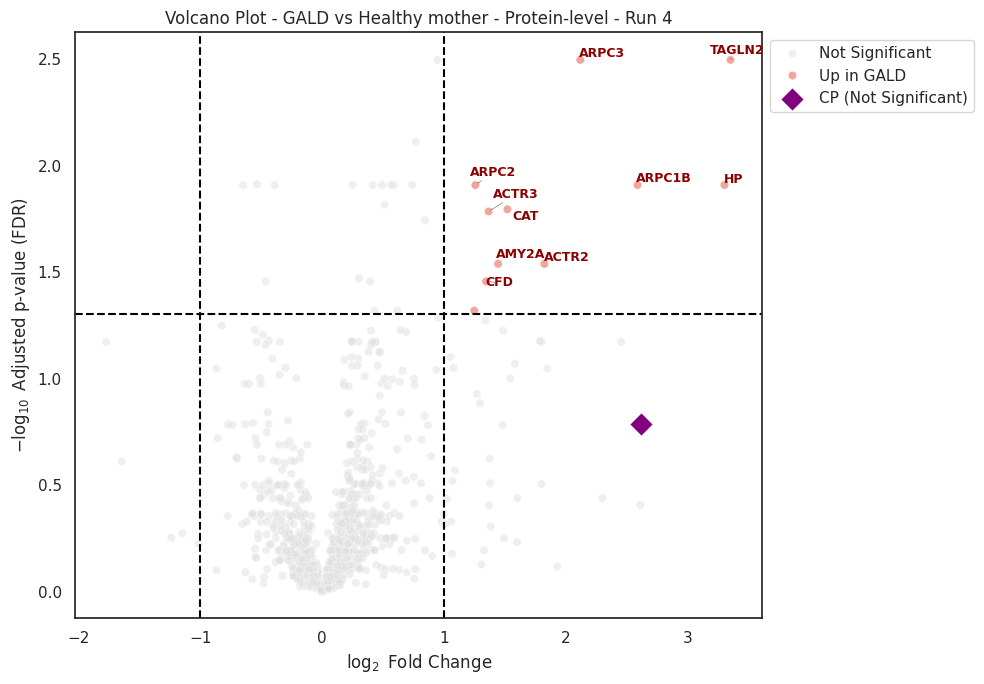


⏩ Skipping Run 4: GALD vs Spouses (Cohort missing in data)

⏩ Skipping Run 5: GALD vs Healthy mother (Cohort missing in data)

📊 Processing Run 5: GALD vs Spouses...


/home/henrikk17/miniconda3/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


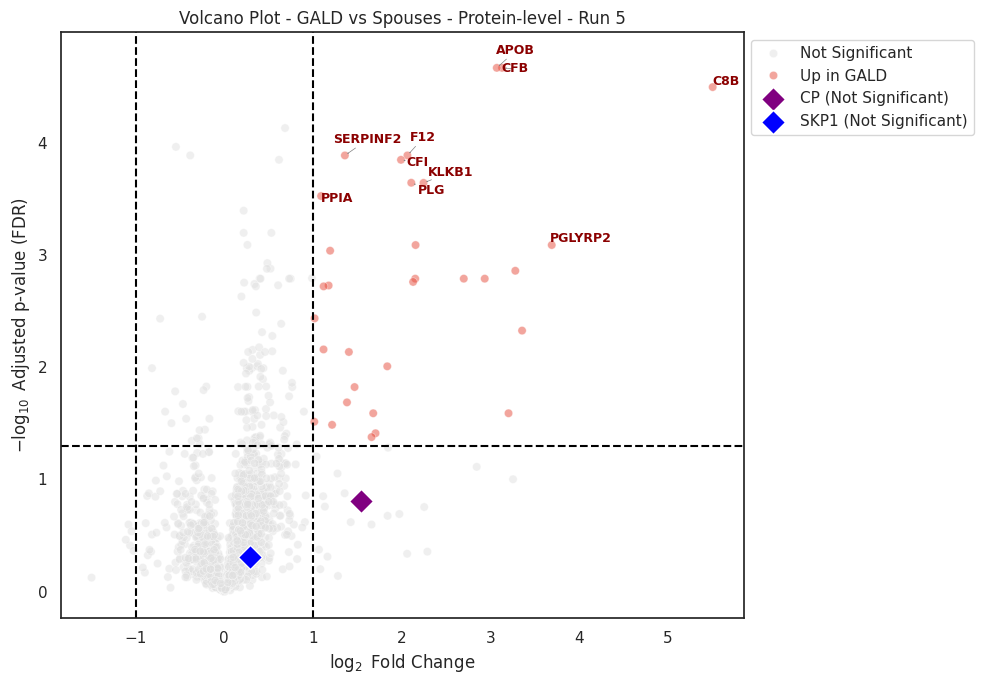


📊 Processing Run 6: GALD vs Healthy mother...


/home/henrikk17/miniconda3/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


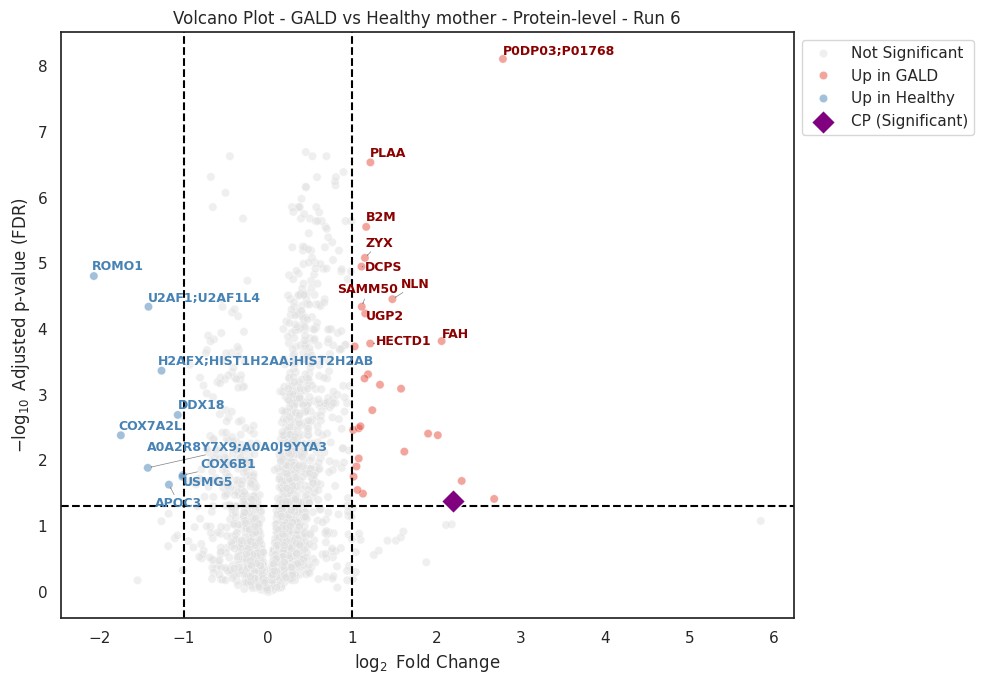


📊 Processing Run 6: GALD vs Spouses...


/home/henrikk17/miniconda3/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


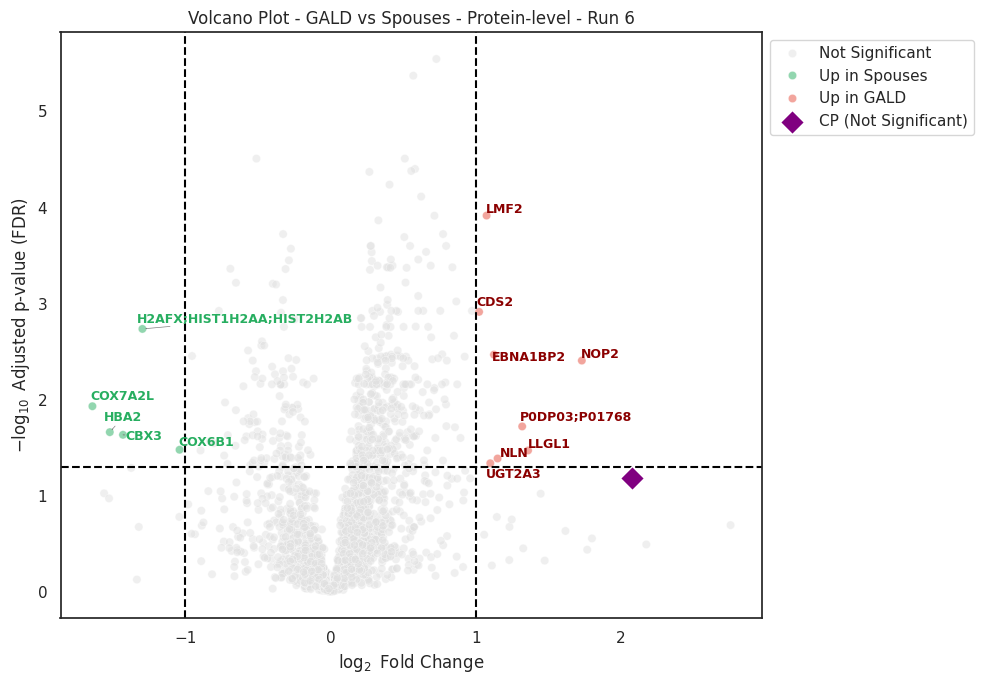


🏆 MASTER SIGNIFICANT GENES LIST (ALL RUNS & COMPARISONS)


,Experiment_Run,Comparison,Protein Group,Gene,Significance,Log2_Fold_Change,P_Value,Adjusted_P_Value
4,Run 4,GALD vs Healthy mother,O15145;C9JZD1;F8VR50,ARPC3,Up in GALD,2.117925,0.000009,0.003192
8,Run 4,GALD vs Healthy mother,P37802;X6RJP6;P37802-2;C9J5W6;Q9UI15,TAGLN2,Up in GALD,3.351355,0.000005,0.003192
2,Run 4,GALD vs Healthy mother,O15143;C9JEY1;C9K057;F8VXW2;C9JBJ7;C9JTT6;C9JM51,ARPC1B,Up in GALD,2.588088,0.000103,0.012346
3,Run 4,GALD vs Healthy mother,O15144;H7C3F9;C9JTV5;G5E9J0,ARPC2,Up in GALD,1.257140,0.000159,0.012346
5,Run 4,GALD vs Healthy mother,P00738;J3QLC9;J3QR68;H0Y300;A0A0C4DGL8;P00738-...,HP,Up in GALD,3.301813,0.000194,0.012346
...,...,...,...,...,...,...,...,...
91,Run 6,GALD vs Spouses,Q13185;C9JMM0;B8ZZ43;S4R2Y4,CBX3,Up in Spouses,-1.428720,0.003459,0.023266
88,Run 6,GALD vs Spouses,P14854;A0A494C160,COX6B1,Up in Spouses,-1.039134,0.005876,0.033296
92,Run 6,GALD vs Spouses,Q15334,LLGL1,Up in GALD,1.360744,0.006133,0.033863
83,Run 6,GALD vs Spouses,E9PCB6,NLN,Up in GALD,1.150868,0.008277,0.041066


In [45]:
# Making a volcano plot with EVERY experiment with every cohort
# It will output a DataFrame with every protein group that was a significant hit for every experiment and cohort.

#With CP and SKP1 coloring

# Master Volcano Plot Pipeline: All Runs & All Cohort Comparisons (Detection-Only)
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

print("--- Running Global Volcano Pipeline (All Runs & Comparisons) ---")

# Define the datasets and the comparisons we want to run
runs = [
    ('Run 4', master_prot_run4_maxQuant_df),
    ('Run 5', master_prot_run5_maxQuant_df),
    ('Run 6', master_prot_run6_maxQuant_df)
]

# (Control Group Name, Display Name, Color, Up-Label)
comparisons = [
    ('Healthy donor', 'Healthy mother', 'steelblue', 'Up in Healthy'),
    ('GALD_spouse', 'Spouses', '#27AE60', 'Up in Spouses')
]

# List to store significant hits from every iteration
all_significant_hits = []

for run_name, df_raw in runs:
    for ctrl_group, ctrl_display, ctrl_color, ctrl_label in comparisons:
        
        # 1. Check if both cohorts exist in this run
        df_subset = df_raw[df_raw['Group'].isin(['GALD', ctrl_group])].copy()
        
        present_groups = df_subset['Group'].unique()
        if 'GALD' not in present_groups or ctrl_group not in present_groups:
            print(f"\n⏩ Skipping {run_name}: GALD vs {ctrl_display} (Cohort missing in data)")
            continue
            
        print(f"\n📊 Processing {run_name}: GALD vs {ctrl_display}...")

        # 2. Filter: Drop 0s (Detection-only)
        df_pos = df_subset[df_subset['Razor Intensity'] > 0].copy()

        # 3. Pivot & Log2
        pivot_df = df_pos.pivot_table(index='Protein Group', columns='Sample', values='Razor Intensity', aggfunc='sum')
        log_df = np.log2(pivot_df)

        gald_cols = [s for s in log_df.columns if s in df_subset[df_subset['Group'] == 'GALD']['Sample'].values]
        ctrl_cols = [s for s in log_df.columns if s in df_subset[df_subset['Group'] == ctrl_group]['Sample'].values]

        # Ensure we have enough samples to run a t-test
        if len(gald_cols) < 2 or len(ctrl_cols) < 2:
            print(f"⏩ Not enough valid samples to compute statistics. Skipping.")
            continue

        # 4. Stats
        log2_fc = log_df[gald_cols].mean(axis=1) - log_df[ctrl_cols].mean(axis=1)
        _, p_vals = ttest_ind(log_df[gald_cols], log_df[ctrl_cols], axis=1, equal_var=False, nan_policy='omit')

        results_df = pd.DataFrame({'Log2_Fold_Change': log2_fc, 'P_Value': p_vals}).dropna()
        
        # Require valid p-values to proceed with FDR
        if results_df.empty:
            continue
            
        _, p_adj, _, _ = multipletests(results_df['P_Value'], method='fdr_bh')
        results_df['Adjusted_P_Value'] = p_adj
        results_df['-Log10_P_Adj'] = -np.log10(p_adj)

        # 5. Significance Filter
        results_df['Significance'] = 'Not Significant'
        results_df.loc[(results_df['-Log10_P_Adj'] >= -np.log10(0.05)) & (results_df['Log2_Fold_Change'] >= 1.0), 'Significance'] = 'Up in GALD'
        results_df.loc[(results_df['-Log10_P_Adj'] >= -np.log10(0.05)) & (results_df['Log2_Fold_Change'] <= -1.0), 'Significance'] = ctrl_label

        # 6. Map Genes
        gene_map = df_raw[['Protein Group', 'Gene']].drop_duplicates().set_index('Protein Group')['Gene']
        results_df['Gene'] = results_df.index.map(gene_map)
        results_df = results_df.reset_index()

        # 7. Export Significant Genes to Master List
        sig_df = results_df[results_df['Significance'] != 'Not Significant'].copy()
        if not sig_df.empty:
            sig_df['Experiment_Run'] = run_name
            sig_df['Comparison'] = f"GALD vs {ctrl_display}"
            all_significant_hits.append(sig_df)

        # ==========================================
        # 8. PLOTTING
        # ==========================================
        plt.figure(figsize=(10, 7))
        
        # Dynamic palette based on comparison
        plot_palette = {'Not Significant': '#E0E0E0', 'Up in GALD': '#E74C3C', ctrl_label: ctrl_color}
        
        sns.scatterplot(data=results_df, x='Log2_Fold_Change', y='-Log10_P_Adj', hue='Significance', 
                        palette=plot_palette, alpha=0.5, legend='full')

        # --- Label Top Hits (GALD / Red) ---
        top_hits = results_df[results_df['Significance'] == 'Up in GALD'].sort_values(by=['-Log10_P_Adj', 'Log2_Fold_Change'], ascending=[False, False]).head(10)
        texts = []
        for i, row in top_hits.iterrows():
            label_name = row['Gene'] if ('Gene' in row and pd.notna(row['Gene'])) else row['Protein Group']
            texts.append(plt.text(row['Log2_Fold_Change'], row['-Log10_P_Adj'], str(label_name), fontsize=9, weight='bold', color='darkred'))

        # --- Label Top Hits (Control / Green or Blue) ---
        down_hits = results_df[results_df['Significance'] == ctrl_label].sort_values(by=['-Log10_P_Adj', 'Log2_Fold_Change'], ascending=[False, False]).head(10)
        for i, row in down_hits.iterrows():
            label_name = row['Gene'] if ('Gene' in row and pd.notna(row['Gene'])) else row['Protein Group']
            texts.append(plt.text(row['Log2_Fold_Change'], row['-Log10_P_Adj'], str(label_name), fontsize=9, weight='bold', color=ctrl_color))

        try:
            adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
        except NameError:
            pass

        # --- Highlight CP in purple ---
        cp_idx = results_df[results_df['Gene'] == 'CP'].index[0] if 'CP' in results_df['Gene'].values else None
        if cp_idx is not None:
            cp_data = results_df.loc[cp_idx]
            cp_sig_status = 'Significant' if cp_data['Significance'] != 'Not Significant' else 'Not Significant'
            cp_label = f"CP ({cp_sig_status})"
            
            sns.scatterplot(data=results_df.loc[[cp_idx]], x='Log2_Fold_Change', y='-Log10_P_Adj', 
                            color='purple', s=150, marker='D', label=cp_label, zorder=10)

        # --- Highlight SKP1 in blue ---
        skp1_idx = results_df[results_df['Gene'] == 'SKP1'].index[0] if 'SKP1' in results_df['Gene'].values else None
        if skp1_idx is not None:
            skp1_data = results_df.loc[skp1_idx]
            skp1_sig_status = 'Significant' if skp1_data['Significance'] != 'Not Significant' else 'Not Significant'
            skp1_label = f"SKP1 ({skp1_sig_status})"
            
            sns.scatterplot(data=results_df.loc[[skp1_idx]], x='Log2_Fold_Change', y='-Log10_P_Adj', 
                            color='blue', s=150, marker='D', label=skp1_label, zorder=10)

        # --- Layout and Polish ---
        plt.axvline(x=1.0, color='black', linestyle='--')
        plt.axvline(x=-1.0, color='black', linestyle='--')
        plt.axhline(y=-np.log10(0.05), color='black', linestyle='--')
        
        plt.title(f"Volcano Plot - GALD vs {ctrl_display} - Protein-level - {run_name}")
        plt.xlabel(r'$\log_2$ Fold Change')
        plt.ylabel(r'$-\log_{10}$ Adjusted p-value (FDR)')
        
        # Safely position legend
        plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()

# ==========================================
# 9. COMPILE MASTER RESULTS DATAFRAME
# ==========================================
print("\n====================================================================")
print("🏆 MASTER SIGNIFICANT GENES LIST (ALL RUNS & COMPARISONS)")
print("====================================================================")

if all_significant_hits:
    master_sig_df = pd.concat(all_significant_hits, ignore_index=True)
    # Reorder columns for clean presentation
    master_sig_df = master_sig_df[['Experiment_Run', 'Comparison', 'Protein Group', 'Gene', 'Significance', 'Log2_Fold_Change', 'P_Value', 'Adjusted_P_Value']]
    
    # Sort by Run, then by strongest statistical significance
    master_sig_df = master_sig_df.sort_values(by=['Experiment_Run', 'Comparison', 'Adjusted_P_Value'], ascending=[True, True, True])
    
    # Display final aggregated table
    display(master_sig_df)
else:
    print("No significant hits found across any experiments using the current thresholds.")
    master_sig_df = pd.DataFrame() # Return empty df to prevent downstream errors


--- Generating 4-Way Venn Diagram from Master Volcano Results ---
Run 4 (vs Healthy):  11 targets
Run 5 (vs Spouse):   32 targets
Run 6 (vs Healthy):  30 targets
Run 6 (vs Spouse):   8 targets


<Figure size 1000x1000 with 0 Axes>

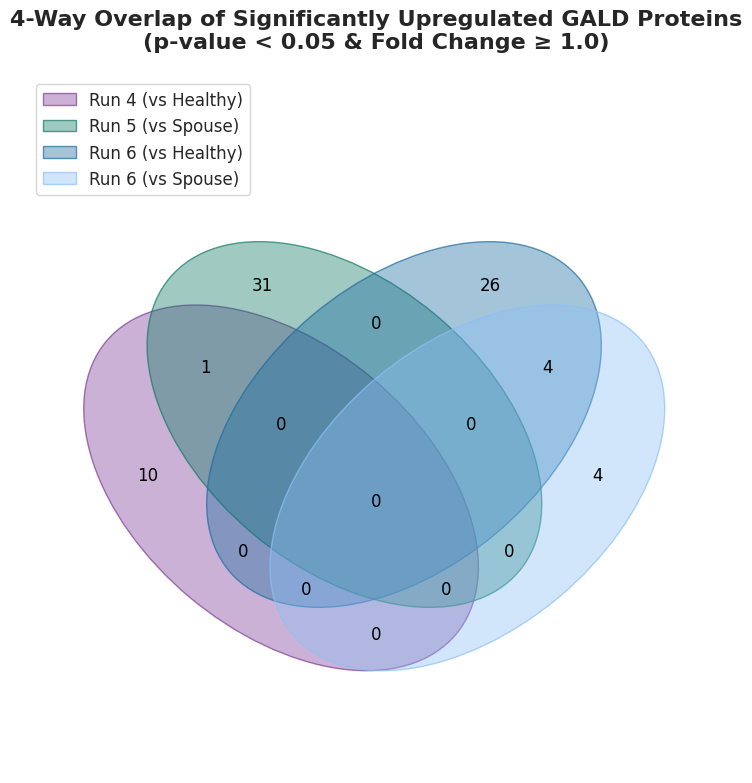


🔥 CORE OVERLAP (Upregulated in all 4 comparisons): 0 proteins
No proteins survived all 4 strict statistical filters concurrently.


In [46]:
#Overlap of significant protein groups in the volcano plots
#Across all experiments


# 4-Way Venn diagram of GALD-upregulated targets across all experiments
import matplotlib.pyplot as plt
from venn import venn

print("--- Generating 4-Way Venn Diagram from Master Volcano Results ---")

# ==========================================
# 1. EXTRACT EXCLUSIVE SETS (UP IN GALD ONLY)
# ==========================================
# Filter the master dataframe to only look at proteins significantly upregulated in GALD
gald_hits_df = master_sig_df[master_sig_df['Significance'] == 'Up in GALD'].copy()

def extract_target_set(run_name, comparison_name):
    """Helper to cleanly extract a set of Protein Groups for a specific run and comparison."""
    subset = gald_hits_df[(gald_hits_df['Experiment_Run'] == run_name) & 
                          (gald_hits_df['Comparison'] == comparison_name)]
    return set(subset['Protein Group'].dropna())

# Extract sets matching your 4 specific filters
r4_vs_healthy = extract_target_set('Run 4', 'GALD vs Healthy mother')
r5_vs_spouse  = extract_target_set('Run 5', 'GALD vs Spouses')
r6_vs_healthy = extract_target_set('Run 6', 'GALD vs Healthy mother')
r6_vs_spouse  = extract_target_set('Run 6', 'GALD vs Spouses')

print(f"Run 4 (vs Healthy):  {len(r4_vs_healthy)} targets")
print(f"Run 5 (vs Spouse):   {len(r5_vs_spouse)} targets")
print(f"Run 6 (vs Healthy):  {len(r6_vs_healthy)} targets")
print(f"Run 6 (vs Spouse):   {len(r6_vs_spouse)} targets")

# ==========================================
# 2. FORMAT DATA FOR PYVENN
# ==========================================
venn_dict = {
    "Run 4 (vs Healthy)": r4_vs_healthy,
    "Run 5 (vs Spouse)": r5_vs_spouse,
    "Run 6 (vs Healthy)": r6_vs_healthy,
    "Run 6 (vs Spouse)": r6_vs_spouse
}

# ==========================================
# 3. PLOT THE VENN DIAGRAM
# ==========================================
plt.figure(figsize=(10, 10))

# Custom Color Palette
#custom_colors = ['lightsalmon', 'darkgreen', 'firebrick', 'palegreen']

custom_colors = ["#7D3C98", "#117A65", "#1B6CA1", "#8CC1F5"]

# Generate the plot
venn(
    venn_dict, 
    cmap=custom_colors, 
    fmt="{size}", 
    fontsize=12, 
    legend_loc="upper left"
)

plt.title("4-Way Overlap of Significantly Upregulated GALD Proteins\n(p-value < 0.05 & Fold Change ≥ 1.0)", 
          fontsize=16, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PRINT THE ULTIMATE CORE OVERLAP
# ==========================================
core_antigens = r4_vs_healthy & r5_vs_spouse & r6_vs_healthy & r6_vs_spouse

print("\n=====================================================")
print(f"🔥 CORE OVERLAP (Upregulated in all 4 comparisons): {len(core_antigens)} proteins")
print("=====================================================")

if len(core_antigens) > 0:
    for target in core_antigens:
        # Pull Gene and Protein Group details cleanly from the master DataFrame
        target_info = gald_hits_df[gald_hits_df['Protein Group'] == target].iloc[0]
        gene_name = target_info['Gene'] if pd.notna(target_info['Gene']) else "Unknown Gene"
        
        print(f"• Gene: {gene_name}")
        print(f"  Protein Group: {target}\n")
else:
    print("No proteins survived all 4 strict statistical filters concurrently.")


--- Generating 4-Way Venn Diagram (Individual Proteins) ---
Run 4 (vs Healthy) distinct proteins:  67
Run 5 (vs Spouse) distinct proteins:   213
Run 6 (vs Healthy) distinct proteins:  124
Run 6 (vs Spouse) distinct proteins:   16


<Figure size 1000x1000 with 0 Axes>

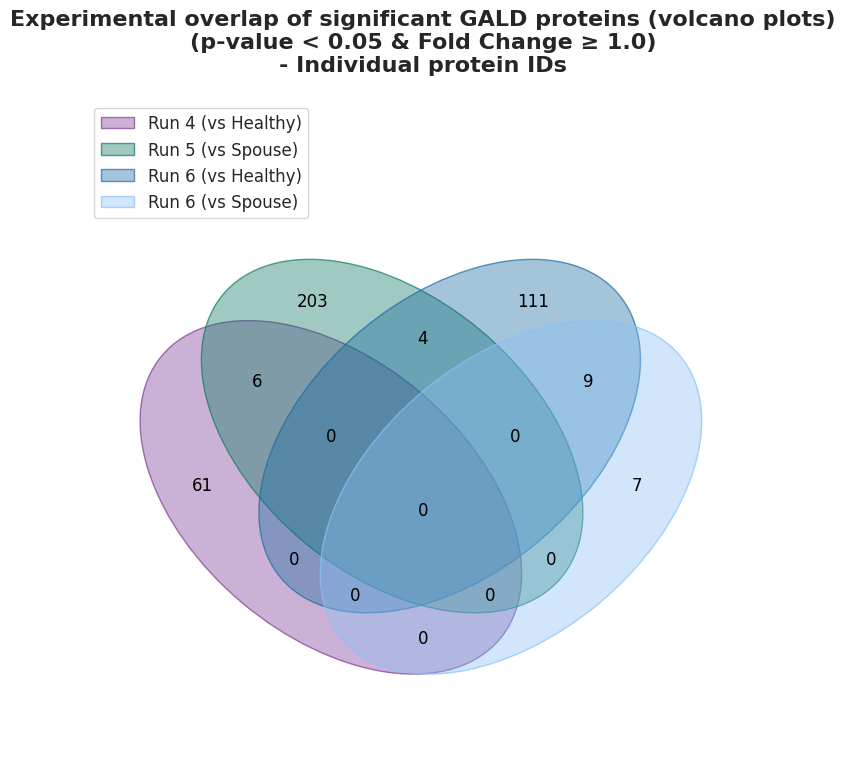


🔥 CORE OVERLAP (Found in all 4 filters): 0 individual proteins
No individual proteins survived all 4 strict statistical filters concurrently.


In [47]:
#Overlap of significant volcano plot proteins

#A version which extracts the proteins from the protein groups
#Individual proteins

# 4-Way Venn diagram of individual proteins from GALD-upregulated targets
import pandas as pd
import matplotlib.pyplot as plt
from venn import venn

print("--- Generating 4-Way Venn Diagram (Individual Proteins) ---")

# ==========================================
# 1. HELPER FUNCTION TO SPLIT GROUPS
# ==========================================
def extract_individual_proteins(protein_group_series):
    """Takes a series of 'Protein_A;Protein_B' strings and returns a set of {'Protein_A', 'Protein_B'}"""
    individual_proteins = set()
    for group in protein_group_series:
        prots = [p.strip() for p in str(group).split(';')]
        individual_proteins.update(prots)
    return individual_proteins

# ==========================================
# 2. EXTRACT AND SPLIT EXCLUSIVE SETS
# ==========================================
# Filter the master dataframe to only look at proteins significantly upregulated in GALD
gald_hits_df = master_sig_df[master_sig_df['Significance'] == 'Up in GALD'].copy()

def extract_target_set(run_name, comparison_name):
    """Helper to extract a subset and instantly split the protein groups into individuals."""
    subset = gald_hits_df[(gald_hits_df['Experiment_Run'] == run_name) & 
                          (gald_hits_df['Comparison'] == comparison_name)]
    return extract_individual_proteins(subset['Protein Group'].dropna())

# Extract sets matching your 4 specific filters
r4_vs_healthy = extract_target_set('Run 4', 'GALD vs Healthy mother')
r5_vs_spouse  = extract_target_set('Run 5', 'GALD vs Spouses')
r6_vs_healthy = extract_target_set('Run 6', 'GALD vs Healthy mother')
r6_vs_spouse  = extract_target_set('Run 6', 'GALD vs Spouses')

print(f"Run 4 (vs Healthy) distinct proteins:  {len(r4_vs_healthy)}")
print(f"Run 5 (vs Spouse) distinct proteins:   {len(r5_vs_spouse)}")
print(f"Run 6 (vs Healthy) distinct proteins:  {len(r6_vs_healthy)}")
print(f"Run 6 (vs Spouse) distinct proteins:   {len(r6_vs_spouse)}")

# ==========================================
# 3. FORMAT DATA FOR PYVENN
# ==========================================
venn_dict = {
    "Run 4 (vs Healthy)": r4_vs_healthy,
    "Run 5 (vs Spouse)": r5_vs_spouse,
    "Run 6 (vs Healthy)": r6_vs_healthy,
    "Run 6 (vs Spouse)": r6_vs_spouse
}

# ==========================================
# 4. PLOT THE VENN DIAGRAM
# ==========================================
plt.figure(figsize=(10, 10))

# Custom Color Palette
#custom_colors = ['lightsalmon', 'darkgreen', 'firebrick', 'palegreen']

custom_colors = ["#7D3C98", "#117A65", "#1B6CA1", "#8CC1F5"]

venn(
    venn_dict, 
    cmap=custom_colors, 
    fmt="{size}", 
    fontsize=12, 
    legend_loc="upper left"
)

plt.title("Experimental overlap of significant GALD proteins (volcano plots)\n(p-value < 0.05 & Fold Change ≥ 1.0)\n- Individual protein IDs", 
          fontsize=16, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# ==========================================
# 5. PRINT THE ULTIMATE CORE OVERLAP
# ==========================================
core_antigens = r4_vs_healthy & r5_vs_spouse & r6_vs_healthy & r6_vs_spouse

print("\n=====================================================")
print(f"🔥 CORE OVERLAP (Found in all 4 filters): {len(core_antigens)} individual proteins")
print("=====================================================")

if len(core_antigens) > 0:
    for target in core_antigens:
        # Trace the individual ID back to the master dataframe to get context
        match = gald_hits_df[gald_hits_df['Protein Group'].str.contains(target, regex=False, na=False)]
        
        if not match.empty:
            gene_name = match['Gene'].iloc[0] if pd.notna(match['Gene'].iloc[0]) else "Unknown Gene"
            original_group = match['Protein Group'].iloc[0]
            
            print(f"🎯 Individual Hit: {target}")
            print(f"   Gene Name:      {gene_name}")
            print(f"   Parent Group:   {original_group}\n")
        else:
            print(f"🎯 Individual Hit: {target} (Tracing error: Could not map back to master dataframe)\n")
else:
    print("No individual proteins survived all 4 strict statistical filters concurrently.")


In [48]:
#Looking closer at the 2-way overlap

# ==========================================
# 1. DEFINE THE PAIRWISE OVERLAPS
# ==========================================
overlaps = {
    "R4 Healthy & R5 Spouse": r4_vs_healthy & r5_vs_spouse,
    "R4 Healthy & R6 Healthy": r4_vs_healthy & r6_vs_healthy,
    "R4 Healthy & R6 Spouse": r4_vs_healthy & r6_vs_spouse,
    "R5 Spouse & R6 Healthy": r5_vs_spouse & r6_vs_healthy,
    "R5 Spouse & R6 Spouse": r5_vs_spouse & r6_vs_spouse,
    "R6 Healthy & R6 Spouse": r6_vs_healthy & r6_vs_spouse
}

# ==========================================
# 2. PRINT SUMMARY COUNTS
# ==========================================
print("\n--- 2-Way Overlap Counts ---")
for label, intersection in overlaps.items():
    print(f"{label}: {len(intersection)} proteins")

# ==========================================
# 3. PRINT DETAILED PROTEIN NAMES
# ==========================================
print("\n--- Detailed Protein Overlaps ---")
for label, intersection in overlaps.items():
    if len(intersection) > 0:
        print(f"\n[{label}]")
        for target in intersection:
            # Trace back to Gene name using the master results
            match = gald_hits_df[gald_hits_df['Protein Group'].str.contains(target, regex=False, na=False)]
            gene = match['Gene'].iloc[0] if not match.empty and pd.notna(match['Gene'].iloc[0]) else "Unknown"
            print(f"  - {target} ({gene})")
    else:
        print(f"\n[{label}]: No overlap found.")


--- 2-Way Overlap Counts ---
R4 Healthy & R5 Spouse: 6 proteins
R4 Healthy & R6 Healthy: 0 proteins
R4 Healthy & R6 Spouse: 0 proteins
R5 Spouse & R6 Healthy: 4 proteins
R5 Spouse & R6 Spouse: 0 proteins
R6 Healthy & R6 Spouse: 9 proteins

--- Detailed Protein Overlaps ---

[R4 Healthy & R5 Spouse]
  - F8WEW2 (ACTR3)
  - P04040 (CAT)
  - F8WDR7 (ACTR3)
  - B4DXW1 (ACTR3)
  - F8WE84 (ACTR3)
  - P61158 (ACTR3)

[R4 Healthy & R6 Healthy]: No overlap found.

[R4 Healthy & R6 Spouse]: No overlap found.

[R5 Spouse & R6 Healthy]
  - H0YAC1 (KLKB1)
  - E9PBC5 (KLKB1)
  - P03952 (KLKB1)
  - C9J075 (KLKB1)

[R5 Spouse & R6 Spouse]: No overlap found.

[R6 Healthy & R6 Spouse]
  - P46087-3 (NOP2)
  - Q15334 (LLGL1)
  - P46087-4 (NOP2)
  - E9PCB6 (NLN)
  - P01768 (Unknown)
  - F5H5X6 (NOP2)
  - P0DP03 (Unknown)
  - P46087-2 (NOP2)
  - P46087 (NOP2)


KLKB1 is a liver protein

In [49]:
#The volcano plot values of CP: 
pd.DataFrame(results_df.loc[cp_idx])

,739
Protein Group,P00450;E9PFZ2;H7C5R1;D6RE86;H7C5N5
Log2_Fold_Change,2.079419
P_Value,0.016402
Adjusted_P_Value,0.06612
-Log10_P_Adj,1.179667
Significance,Not Significant
Gene,CP


### **Bonus plots:**

--- Generating Imputation Conceptual Schematic ---


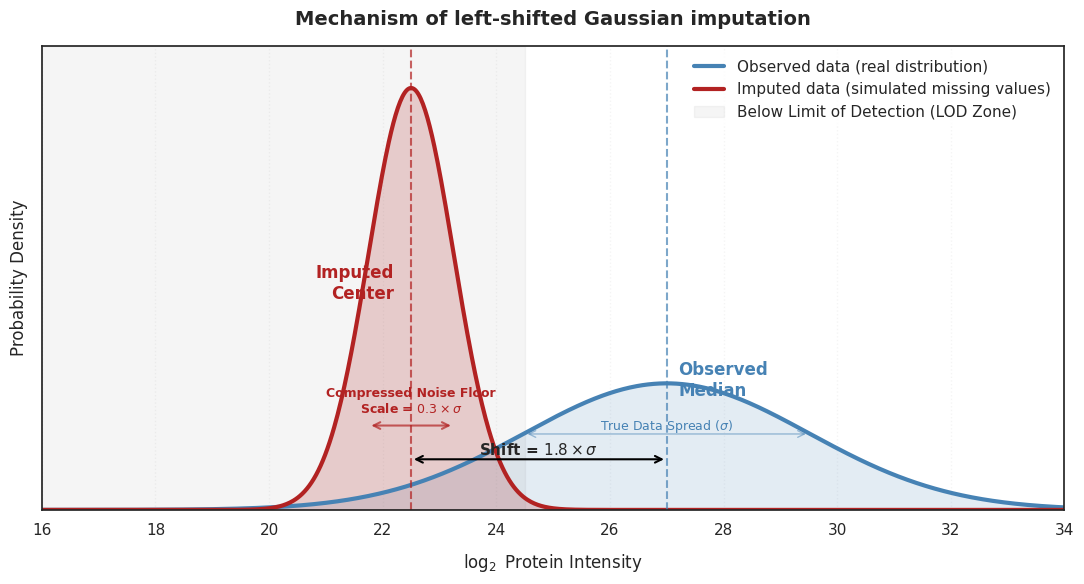

In [50]:
#Understanding left-shifted Gaussian imputation:

# Script to generate a conceptual diagram of downshifted normal distribution imputation
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

print("--- Generating Imputation Conceptual Schematic ---")

# Setup a clean plotting landscape
fig, ax = plt.subplots(figsize=(11, 6))

# Define mathematical coordinates for the curves
x = np.linspace(15, 35, 1000)
real_median = 27.0
real_sd = 2.5

# 1. Real Biological Data Distribution Curve (Wide)
y_real = stats.norm.pdf(x, real_median, real_sd)
ax.plot(x, y_real, color='steelblue', lw=3, label='Observed data (real distribution)')
ax.fill_between(x, y_real, color='steelblue', alpha=0.15)

# 2. Imputation Parameters Math
impute_shift = 1.8
impute_scale = 0.3

imposed_mean = real_median - (impute_shift * real_sd) # 27 - (1.8 * 2.5) = 22.5
imposed_sd = real_sd * impute_scale                    # 2.5 * 0.3 = 0.75

# 3. Imputed Data Distribution Curve (Narrow and Shifted Left)
y_imputed = stats.norm.pdf(x, imposed_mean, imposed_sd)
ax.plot(x, y_imputed, color='firebrick', lw=3, label='Imputed data (simulated missing values)')
ax.fill_between(x, y_imputed, color='firebrick', alpha=0.2)

# --------------------------------------------------------
# 📊 ADD STRUCTURAL GUIDELINES AND TEXT LABEL BLOCKS
# --------------------------------------------------------
# Vertical Anchor for Real Median
ax.axvline(x=real_median, color='steelblue', linestyle='--', alpha=0.7, lw=1.5)
ax.text(real_median + 0.2, max(y_real) * 0.9, 'Observed\nMedian', color='steelblue', weight='bold')

# Vertical Anchor for Imputed Center
ax.axvline(x=imposed_mean, color='firebrick', linestyle='--', alpha=0.7, lw=1.5)
ax.text(imposed_mean - 0.3, max(y_imputed) * 0.5, 'Imputed\nCenter', color='firebrick', weight='bold', ha='right')

# Horizontal Dimension Arrow for the Shift (1.8 SD)
ax.annotate(
    '', xy=(imposed_mean, max(y_real) * 0.4), xytext=(real_median, max(y_real) * 0.4),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5, ls='-')
)
ax.text((real_median + imposed_mean)/2, max(y_real) * 0.43, r'Shift = $1.8 \times \sigma$', 
        ha='center', fontsize=11, weight='bold')

# Width Indicators comparing the Standard Deviations
# Real biological width bracket
ax.annotate('', xy=(real_median - real_sd, max(y_real)*0.6), xytext=(real_median + real_sd, max(y_real)*0.6),
            arrowprops=dict(arrowstyle='<->', color='steelblue', alpha=0.5, lw=1))
ax.text(real_median, max(y_real)*0.63, r'True Data Spread ($\sigma$)', color='steelblue', ha='center', fontsize=9)

# Imputed compressed variance width bracket
ax.annotate('', xy=(imposed_mean - imposed_sd, max(y_imputed)*0.2), xytext=(imposed_mean + imposed_sd, max(y_imputed)*0.2),
            arrowprops=dict(arrowstyle='<->', color='firebrick', alpha=0.7, lw=1.5))
ax.text(imposed_mean, max(y_imputed)*0.23, r'Compressed Noise Floor' + '\n' + r'Scale = $0.3 \times \sigma$', 
        color='firebrick', ha='center', fontsize=9, weight='bold')

# Limit of Detection (LOD) conceptual gray boundary zone
ax.axvspan(15, 24.5, color='gray', alpha=0.08, label='Below Limit of Detection (LOD Zone)')

# Polishing plot boundaries and clean styling
ax.set_title('Mechanism of left-shifted Gaussian imputation', fontsize=14, weight='bold', pad=15)
ax.set_xlabel(r'$\log_2$ Protein Intensity', fontsize=12, labelpad=10)
ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
ax.set_xlim(16, 34)
ax.set_ylim(0, max(y_imputed) * 1.1)
ax.set_yticks([]) # Hide density decimals to emphasize schematic concepts
ax.grid(axis='x', alpha=0.2, linestyle=':')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()


Venn diagram of individual proteins in protein groups and their overlap

--- Extracting and Splitting Individual Proteins ---
Run 4 Overlap (GALD & Healthy): 6443 shared proteins
Run 5 Overlap (GALD & Spouse):  13879 shared proteins
Run 6 Core Overlap (All 3):     13220 shared proteins

--- Generating Unweighted Venn Diagrams (Individual Proteins) ---


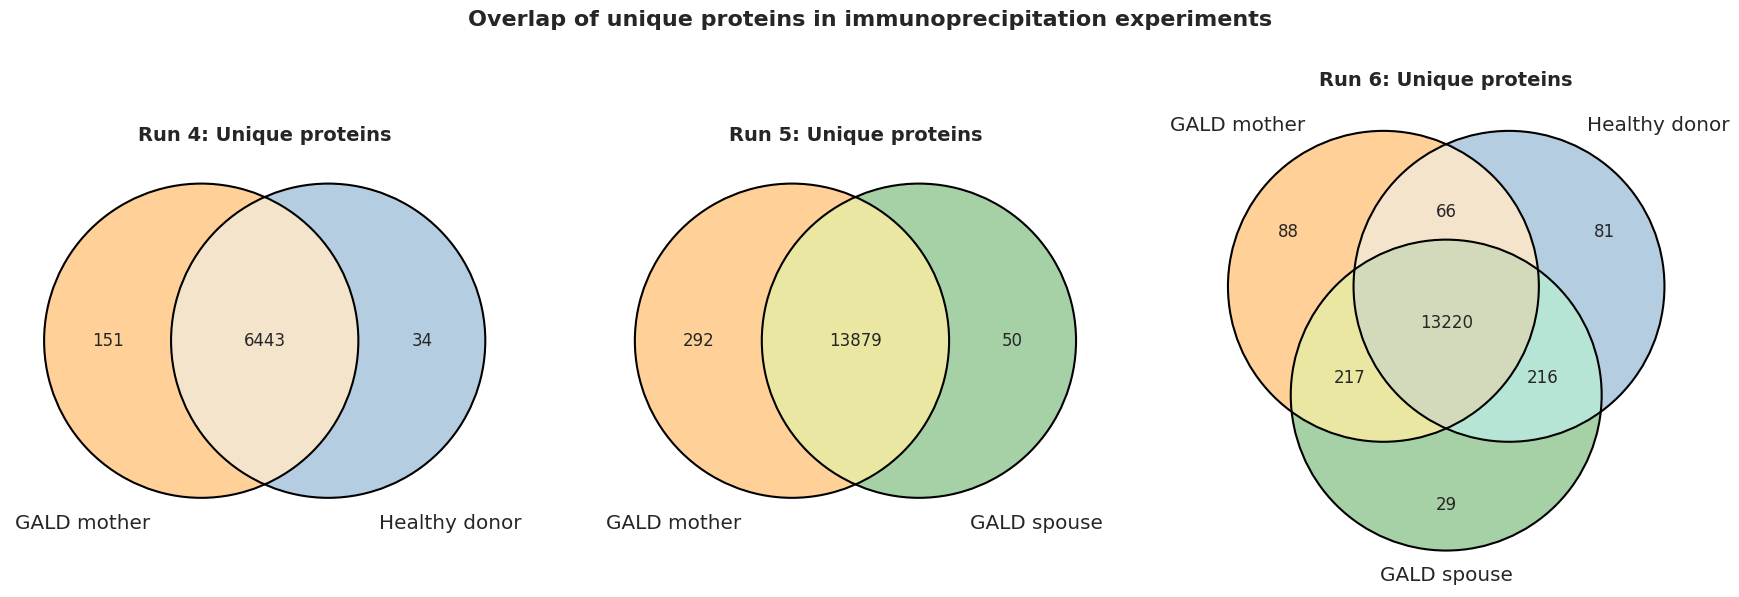

In [51]:
# Analyzing protein overlaps at the split, individual-protein level
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3, venn2_circles, venn3_circles
from matplotlib_venn.layout.venn2 import DefaultLayoutAlgorithm as Venn2Layout
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm as Venn3Layout
from venn import venn  # Required for the 4-way plot

print("--- Extracting and Splitting Individual Proteins ---")

# ==========================================
# 1. HELPER FUNCTION TO SPLIT PROTEIN GROUPS
# ==========================================
def extract_individual_proteins(df, cohort_name):
    """Filters the dataframe by cohort, drops NAs, splits the Protein Group strings by ';', and returns a set of individual proteins."""
    subset = df[df['Group'] == cohort_name]['Protein Group'].dropna()
    individual_proteins = set()
    for group in subset:
        prots = [p.strip() for p in str(group).split(';')]
        individual_proteins.update(prots)
    return individual_proteins

# ==========================================
# 2. EXTRACT SETS (INDIVIDUAL PROTEIN LEVEL)
# ==========================================
# Run 4
gald_run4 = extract_individual_proteins(master_prot_run4_maxQuant_df, 'GALD')
healthy_run4 = extract_individual_proteins(master_prot_run4_maxQuant_df, 'Healthy donor')

# Run 5
gald_run5 = extract_individual_proteins(master_prot_run5_maxQuant_df, 'GALD')
spouse_run5 = extract_individual_proteins(master_prot_run5_maxQuant_df, 'GALD_spouse')

# Run 6
gald_run6 = extract_individual_proteins(master_prot_run6_maxQuant_df, 'GALD')
healthy_run6 = extract_individual_proteins(master_prot_run6_maxQuant_df, 'Healthy donor')
spouse_run6 = extract_individual_proteins(master_prot_run6_maxQuant_df, 'GALD_spouse')

print(f"Run 4 Overlap (GALD & Healthy): {len(gald_run4 & healthy_run4)} shared proteins")
print(f"Run 5 Overlap (GALD & Spouse):  {len(gald_run5 & spouse_run5)} shared proteins")
print(f"Run 6 Core Overlap (All 3):     {len(gald_run6 & healthy_run6 & spouse_run6)} shared proteins\n")

# ==========================================
# 3. PLOT 1: INTRA-EXPERIMENT OVERLAPS (1x3 SUBPLOTS)
# ==========================================
print("--- Generating Unweighted Venn Diagrams (Individual Proteins) ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def shift_labels_outward(venn_obj, shift_amount=0.15):
    if venn_obj and venn_obj.set_labels[0]:
        pos_left = venn_obj.set_labels[0].get_position()
        venn_obj.set_labels[0].set_position((pos_left[0] - shift_amount, pos_left[1]))
    if venn_obj and venn_obj.set_labels[1]:
        pos_right = venn_obj.set_labels[1].get_position()
        venn_obj.set_labels[1].set_position((pos_right[0] + shift_amount, pos_right[1]))

unweighted_v2 = Venn2Layout(fixed_subset_sizes=(1, 1, 1))
unweighted_v3 = Venn3Layout(fixed_subset_sizes=(1, 1, 1, 1, 1, 1, 1))

# --- Plot Run 4 ---
plt.sca(axes[0])
v4 = venn2([gald_run4, healthy_run4], 
           set_labels=('GALD mother', 'Healthy donor'), 
           set_colors=('darkorange', 'steelblue'), 
           alpha=0.4, layout_algorithm=unweighted_v2)
venn2_circles(subsets=(1, 1, 1), linestyle='solid', linewidth=1.5, color='black')
shift_labels_outward(v4)
plt.title("Run 4: Unique proteins", fontsize=14, weight='bold')

# --- Plot Run 5 ---
plt.sca(axes[1])
v5 = venn2([gald_run5, spouse_run5], 
           set_labels=('GALD mother', 'GALD spouse'), 
           set_colors=('darkorange', 'forestgreen'), 
           alpha=0.4, layout_algorithm=unweighted_v2)
venn2_circles(subsets=(1, 1, 1), linestyle='solid', linewidth=1.5, color='black')
shift_labels_outward(v5)
plt.title("Run 5: Unique proteins", fontsize=14, weight='bold')

# --- Plot Run 6 ---
plt.sca(axes[2])
v6 = venn3([gald_run6, healthy_run6, spouse_run6], 
           set_labels=('GALD mother', 'Healthy donor', 'GALD spouse'), 
           set_colors=('darkorange', 'steelblue', 'forestgreen'), 
           alpha=0.4, layout_algorithm=unweighted_v3)
venn3_circles(subsets=(1, 1, 1, 1, 1, 1, 1), linestyle='solid', linewidth=1.5, color='black')
plt.title("Run 6: Unique proteins", fontsize=14, weight='bold')

fig.suptitle("Overlap of unique proteins in immunoprecipitation experiments", fontsize=16, weight='bold', y=1.02)

plt.tight_layout()
plt.show()



--- Analyzing the 'GALD-Only' Overlap Across All 3 Runs ---
Run 4 (GALD purely exclusive): 151 individual proteins
Run 5 (GALD purely exclusive): 292 individual proteins
Run 6 (GALD purely exclusive): 88 individual proteins


<Figure size 800x800 with 0 Axes>

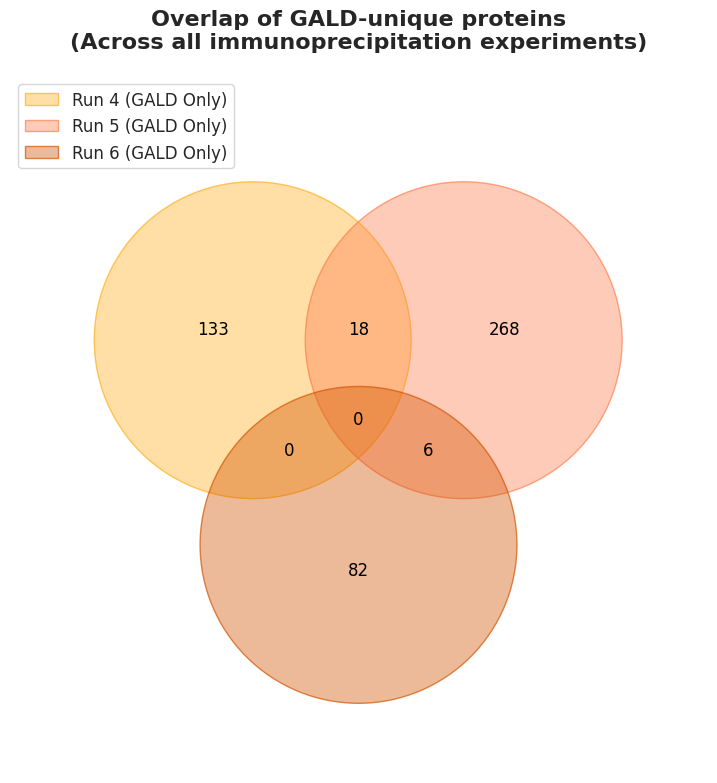


🔥 CROSS-RUN GALD EXCLUSIVE CORE: 0 individual proteins
These proteins were detected in GALD, but completely absent in controls, across EVERY run.
No exclusively GALD-specific proteins survived perfectly across all three machine runs.


In [52]:
# Analyzing the 3-Way Overlap of STRICTLY GALD-EXCLUSIVE Proteins Across All Experiments
# (I.e. the overlap of the orange part above)
import matplotlib.pyplot as plt
from venn import venn

print("\n--- Analyzing the 'GALD-Only' Overlap Across All 3 Runs ---")

# ==========================================
# 1. CALCULATE STRICTLY GALD-EXCLUSIVE SETS
# ==========================================
# Subtract the controls from the GALD cohorts for each respective run
gald_only_run4 = gald_run4 - healthy_run4
gald_only_run5 = gald_run5 - spouse_run5

# For Run 6, it must be absent in BOTH Healthy and Spouse controls
gald_only_run6 = gald_run6 - healthy_run6 - spouse_run6

print(f"Run 4 (GALD purely exclusive): {len(gald_only_run4)} individual proteins")
print(f"Run 5 (GALD purely exclusive): {len(gald_only_run5)} individual proteins")
print(f"Run 6 (GALD purely exclusive): {len(gald_only_run6)} individual proteins")

# ==========================================
# 2. FORMAT DATA FOR PYVENN
# ==========================================
venn_dict_gald_only = {
    "Run 4 (GALD Only)": gald_only_run4,
    "Run 5 (GALD Only)": gald_only_run5,
    "Run 6 (GALD Only)": gald_only_run6
}

# ==========================================
# 3. PLOT THE 3-WAY GALD-EXCLUSIVE VENN DIAGRAM
# ==========================================
plt.figure(figsize=(8, 8))

# 3 distinct shades of orange/rust to honor the "Orange Circle" theme
orange_palette = ['#FFB020', '#FF7F50', '#D35400']

# Plot using the unified stylized package
venn(
    venn_dict_gald_only, 
    cmap=orange_palette, 
    fmt="{size}", 
    fontsize=12, 
    legend_loc="upper left"
)

plt.title("Overlap of GALD-unique proteins\n(Across all immunoprecipitation experiments)", 
          fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# 4. PRINT THE ULTIMATE GALD-EXCLUSIVE CORE
# ==========================================
core_gald_exclusive = gald_only_run4 & gald_only_run5 & gald_only_run6

print("\n====================================================================")
print(f"🔥 CROSS-RUN GALD EXCLUSIVE CORE: {len(core_gald_exclusive)} individual proteins")
print("These proteins were detected in GALD, but completely absent in controls, across EVERY run.")
print("====================================================================")

if len(core_gald_exclusive) > 0:
    for target in list(core_gald_exclusive):
        # Trace back to Run 6 to get the description and gene name
        match = master_prot_run6_maxQuant_df[master_prot_run6_maxQuant_df['Protein Group'].str.contains(target, regex=False, na=False)]
        
        if not match.empty:
            gene = match['Gene'].iloc[0] if pd.notna(match['Gene'].iloc[0]) else "Unknown Gene"
            desc = match['Protein Description'].iloc[0]
            print(f"• Gene: {gene:<15} | ID: {target}")
            print(f"  Description: {desc}\n")
        else:
            print(f"• Gene: Unknown         | ID: {target}")
            print(f"  Description: (Not found in Run 6 mapping)\n")
else:
    print("No exclusively GALD-specific proteins survived perfectly across all three machine runs.")

In [53]:
# Printing intersecting GALD unique proteins with Gene mapping
import pandas as pd

print("--- Mapping Intersecting GALD-Exclusive Proteins to Genes ---")

# ==========================================
# 1. ROBUST GENE LOOKUP FUNCTION
# ==========================================
def get_gene_for_protein(target):
    """Searches across all 3 dataframes to find the gene name for a given protein ID."""
    
    # 1. Check Run 6 first
    match6 = master_prot_run6_maxQuant_df[master_prot_run6_maxQuant_df['Protein Group'].str.contains(target, regex=False, na=False)]
    if not match6.empty and 'Gene' in match6.columns and pd.notna(match6['Gene'].iloc[0]):
        return match6['Gene'].iloc[0]
        
    # 2. Fallback to Run 5
    match5 = master_prot_run5_maxQuant_df[master_prot_run5_maxQuant_df['Protein Group'].str.contains(target, regex=False, na=False)]
    if not match5.empty and 'Gene' in match5.columns and pd.notna(match5['Gene'].iloc[0]):
        return match5['Gene'].iloc[0]
        
    # 3. Fallback to Run 4
    match4 = master_prot_run4_maxQuant_df[master_prot_run4_maxQuant_df['Protein Group'].str.contains(target, regex=False, na=False)]
    if not match4.empty and 'Gene' in match4.columns and pd.notna(match4['Gene'].iloc[0]):
        return match4['Gene'].iloc[0]
        
    return "Unknown Gene"

# ==========================================
# 2. PRINTING HELPER
# ==========================================
def print_mapped_intersection(title, protein_set):
    print(f"\n{title} ({len(protein_set)} proteins):")
    if len(protein_set) == 0:
        print("  None")
        return
        
    for target in protein_set:
        gene = get_gene_for_protein(target)
        print(f"  • Gene: {gene:<15} | ID: {target}")

# ==========================================
# 3. EXECUTE MAPPING
# ==========================================
# Run 4 & Run 5
print_mapped_intersection(
    "GALD unique proteins - Run 4 and Run 5", 
    gald_only_run4 & gald_only_run5
)

# Run 5 & Run 6
print_mapped_intersection(
    "GALD unique proteins - Run 5 and Run 6", 
    gald_only_run5 & gald_only_run6
)

# Run 4 & Run 6 (Adding this one for completeness!)
print_mapped_intersection(
    "GALD unique proteins - Run 4 and Run 6", 
    gald_only_run4 & gald_only_run6
)


--- Mapping Intersecting GALD-Exclusive Proteins to Genes ---

GALD unique proteins - Run 4 and Run 5 (18 proteins):
  • Gene: UGP2            | ID: C9JVG3
  • Gene: CORO1A          | ID: H3BRJ0
  • Gene: UGP2            | ID: C9JNZ1
  • Gene: UGP2            | ID: Q16851-2
  • Gene: UGP2            | ID: A0A7I2V676
  • Gene: CORO1A          | ID: H3BRY3
  • Gene: CORO1A          | ID: H3BSL1
  • Gene: CORO1A          | ID: P31146
  • Gene: UGP2            | ID: E7EUC7
  • Gene: UGP2            | ID: A0A7I2V4T0
  • Gene: UGP2            | ID: A0A087WYS1
  • Gene: UGP2            | ID: A0A7I2YQ74
  • Gene: CORO1A          | ID: H3BTU6
  • Gene: CORO1A          | ID: H3BNA2
  • Gene: UGP2            | ID: Q16851
  • Gene: MUC5B           | ID: Q9HC84
  • Gene: CORO1A          | ID: H3BU76
  • Gene: UGP2            | ID: C9JQU9

GALD unique proteins - Run 5 and Run 6 (6 proteins):
  • Gene: F11             | ID: X6R3B1
  • Gene: F11             | ID: P03951
  • Gene: F11             | ID:

In [54]:
master_prot_run6_maxQuant_df["Gene"].unique() #There are 2333 unique genes, at protein level. Not sure what is causing the minor deviation. 


array(['HDLBP', nan, 'PSMA2', ..., 'LCLAT1', 'IGLV5-45', 'NAGA'],
      shape=(2333,), dtype=object)

---
## **Revisited - September 2026**:

#### *Peptide-level investigation of 5 significant ceruloplasmin (CP) hits:*<br>
```P00450, E9PFZ2, H7C5R1, D6RE86, H7C5N5``` 

In [57]:
#Investigating the peptide-level abudance of different CP isoforms in GALD mothers vs healthy mothers and spouses 
#Heatmap of peptide-level abundance 

target_hits_list = ["P00450", "E9PFZ2", "H7C5R1", "D6RE86", "H7C5N5"] 

print(target_hits_list) 

master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Protein"].isin(target_hits_list)] #Getting peptide entries of only relevant 5 CP isoforms

['P00450', 'E9PFZ2', 'H7C5R1', 'D6RE86', 'H7C5N5']


,Peptide Sequence,Protein,Protein Group,Gene,Protein Name,Score,PEP,Sample_Col,Razor Intensity,Sample,Group,Sample_type,Protein Description
3555,HYYIGIIETTWDYASDHGEK,P00450,P00450;E9PFZ2;D6RE86,CP,Ceruloplasmin,95.345,3.791900e-06,LFQ intensity 1_S3-A1_1_9338,12744.0,sample_1,GALD,Liver Lysate,NaN
4305,KAEEEHLGILGPQLHADVGDK,P00450,P00450;E9PFZ2;H7C5R1,CP,Ceruloplasmin,98.328,1.379000e-05,LFQ intensity 1_S3-A1_1_9338,1769.5,sample_1,GALD,Liver Lysate,NaN
6304,MYYSAVDPTKDIFTGLIGPMK,P00450,P00450;CON__ENSEMBL:ENSBTAP00000031900,CP,Ceruloplasmin,98.895,6.013400e-09,LFQ intensity 1_S3-A1_1_9338,4947.7,sample_1,GALD,Liver Lysate,NaN
8731,TYCSEPEKVDKDNEDFQESNR,P00450,P00450;E9PFZ2;H7C5R1,CP,Ceruloplasmin,114.500,4.763800e-07,LFQ intensity 1_S3-A1_1_9338,6036.3,sample_1,GALD,Liver Lysate,NaN
14517,KAEEEHLGILGPQLHADVGDK,P00450,P00450;E9PFZ2;H7C5R1,CP,Ceruloplasmin,98.328,1.379000e-05,LFQ intensity 10_S3-A10_1_9347,6822.1,sample_10,GALD,Liver Lysate,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
287930,ERGPEEEHLGILGPVIWAEVGDTIR,P00450,P00450;E9PFZ2;H7C5R1,CP,Ceruloplasmin,86.838,5.253200e-14,LFQ intensity 8_S3-A8_1_9345,20258.0,sample_8,GALD,Liver Lysate,NaN
289491,HYYIGIIETTWDYASDHGEK,P00450,P00450;E9PFZ2;D6RE86,CP,Ceruloplasmin,95.345,3.791900e-06,LFQ intensity 8_S3-A8_1_9345,13909.0,sample_8,GALD,Liver Lysate,NaN
290453,KLISVDTEHSNIYLQNGPDR,P00450,P00450;E9PFZ2,CP,Ceruloplasmin,89.489,1.926600e-05,LFQ intensity 8_S3-A8_1_9345,10843.0,sample_8,GALD,Liver Lysate,NaN
292485,NNEGTYYSPNYNPQSR,P00450,P00450;E9PFZ2;H7C5R1,CP,Ceruloplasmin,84.102,3.104500e-03,LFQ intensity 8_S3-A8_1_9345,6173.8,sample_8,GALD,Liver Lysate,NaN


In [ ]:
#Checking leading razor protein of the peptide entries which contain the 5 CP isoforms: 
#isin() on the "Protein" column 
print("Run 4:", master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Protein"].isin(target_hits_list)]["Protein"].unique()) #Only P00450 as leading razor

print("Run 5:", master_pep_run5_maxQuant_df[master_pep_run5_maxQuant_df["Protein"].isin(target_hits_list)]["Protein"].unique()) #Only P00450 as leading razor

print("Run 6:", master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Protein"].isin(target_hits_list)]["Protein"].unique()) #Only P00450 as leading razor


Run 4: ['P00450']
Run 5: ['P00450']
Run 6: ['P00450']


In [ ]:
#Checking leading razor protein of the peptide entries which contain the 5 CP isoforms: 
#Str.contains() in the protein group
print("Run 4:", master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Protein Group"].str.contains("|".join(target_hits_list))]["Protein"].unique()) #Only P00450 as leading razor

print("Run 5:", master_pep_run5_maxQuant_df[master_pep_run5_maxQuant_df["Protein Group"].str.contains("|".join(target_hits_list))]["Protein"].unique()) #Only P00450 as leading razor

print("Run 6:", master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Protein Group"].str.contains("|".join(target_hits_list))]["Protein"].unique()) #Only P00450 as leading razor


Run 4: ['P00450']
Run 5: ['P00450']
Run 6: ['P00450']


Based on this we can conclude that no unique peptides exist, as we otherwise wouldn't have P00450 as the only leading razor protein in all of these peptide entries. <br>
Reminder that the subset of peptides above represents peptides which have been mapped to any of the significant 5 CP isoforms/ fragments

**Coverage of detected peptide sequences** relative to the sequence length of P00450 (CP, canonical):

In [152]:
#The lenght of the canonical CP isoform (P00450) is 1065 amino acids): 

CP_length = 1065 #Source: UniProt P00450

In [ ]:
#Helper function: remove nested peptides from a list of peptides
#I.e. if you have both "ABCDE" and "BC" in the list, remove "BC" since it is nested within "ABCDE"

import numpy as np

def remove_nested_peptides(peptide_array):
    """
    Takes an array of peptides and removes any that are exact substrings 
    of another longer peptide in the list.
    """
    # Convert to list and sort by length descending (longest first)
    peptides = sorted(list(peptide_array), key=len, reverse=True)
    
    unique_longest_peptides = []
    
    for pep in peptides:
        # Check if 'pep' is found inside any of the already saved longer peptides
        is_nested = any(pep in longer_pep for longer_pep in unique_longest_peptides)
        
        if not is_nested:
            unique_longest_peptides.append(pep)
            
    return np.array(unique_longest_peptides)

# Example usage with the data:
raw_peptides = master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Protein"].str.contains("P02771")]["Peptide Sequence"].unique()
filtered_peptides = remove_nested_peptides(raw_peptides)
print(f"Reduced from {len(raw_peptides)} to {len(filtered_peptides)} non-overlapping peptides.")


Reduced from 46 to 25 non-overlapping peptides.


In [121]:
print("Amount of unique peptides for the CP hits:",len(master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Protein"].isin(target_hits_list)]["Peptide Sequence"].unique()))
print("Amount of unique peptides for the CP hits (overlapping peptides removed):",len(remove_nested_peptides(master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Protein"].isin(target_hits_list)]["Peptide Sequence"].unique())))

Amount of unique peptides for the CP hits: 22
Amount of unique peptides for the CP hits (overlapping peptides removed): 19


In [154]:
total_covered_peptide_length_run4 = sum([len(pep) for pep in remove_nested_peptides(master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Protein"].isin(target_hits_list)]["Peptide Sequence"].unique())])
total_covered_peptide_length_run5 = sum([len(pep) for pep in remove_nested_peptides(master_pep_run5_maxQuant_df[master_pep_run5_maxQuant_df["Protein"].isin(target_hits_list)]["Peptide Sequence"].unique())])
total_covered_peptide_length_run6 = sum([len(pep) for pep in remove_nested_peptides(master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Protein"].isin(target_hits_list)]["Peptide Sequence"].unique())])

print("Total length of the different peptides in run 4 relative to total length of CP (P00450):")
print(total_covered_peptide_length_run4, f"({total_covered_peptide_length_run4/CP_length*100:.2f}%)")
print()

print("Total length of the different peptides in run 5 relative to total length of CP (P00450):")
print(total_covered_peptide_length_run5, f"({total_covered_peptide_length_run5/CP_length*100:.2f}%)")
print()

print("Total length of the different peptides in run 6 relative to total length of CP (P00450):")
print(total_covered_peptide_length_run6, f"({total_covered_peptide_length_run6/CP_length*100:.2f}%)")
print()


Total length of the different peptides in run 4 relative to total length of CP (P00450):
375 (35.21%)

Total length of the different peptides in run 5 relative to total length of CP (P00450):
313 (29.39%)

Total length of the different peptides in run 6 relative to total length of CP (P00450):
280 (26.29%)



**Note**: In the subsequent code section I will make a code which highlights the peptide coverage. <br>
The count values achieved in this code provides more accurate peptide coverage length, as this code doesn't account for partial overlap between 2 peptides. 

Comparison of the % coverage relative to another protein

In [153]:
#Comparison of coverage 
#Random fetal liver protein: Alpha-fetoprotein (AFP, P02771) 

target_prot_id = "P02771"
target_prot_length = 609 #Source: UniProt P02771. The length of AFP is 609. 

#Coverage of target protein: 

target_total_covered_peptide_length_run4 = sum([len(pep) for pep in remove_nested_peptides(master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Protein"].str.contains(target_prot_id)]["Peptide Sequence"].unique())])
target_total_covered_peptide_length_run5 = sum([len(pep) for pep in remove_nested_peptides(master_pep_run5_maxQuant_df[master_pep_run5_maxQuant_df["Protein"].str.contains(target_prot_id)]["Peptide Sequence"].unique())])
target_total_covered_peptide_length_run6 = sum([len(pep) for pep in remove_nested_peptides(master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Protein"].str.contains(target_prot_id)]["Peptide Sequence"].unique())])

print(f"Total length of the different peptides in run 4 relative to total length of target protein - {target_prot_id}:")
print(target_total_covered_peptide_length_run4, f"({target_total_covered_peptide_length_run4/target_prot_length*100:.2f}%)")
print()

print(f"Total length of the different peptides in run 5 relative to total length of target protein - {target_prot_id}:")
print(target_total_covered_peptide_length_run5, f"({target_total_covered_peptide_length_run5/target_prot_length*100:.2f}%)")
print()

print(f"Total length of the different peptides in run 6 relative to total length of target protein - {target_prot_id}:")
print(target_total_covered_peptide_length_run6, f"({target_total_covered_peptide_length_run6/target_prot_length*100:.2f}%)")
print()


Total length of the different peptides in run 4 relative to total length of target protein - P02771:
0 (0.00%)

Total length of the different peptides in run 5 relative to total length of target protein - P02771:
0 (0.00%)

Total length of the different peptides in run 6 relative to total length of target protein - P02771:
553 (90.80%)



##### **Highlighted peptide coverage:**

In [ ]:
#Coordinate boolean mapping

from IPython.display import display, HTML

def highlight_coverage_in_notebook(reference_sequence, peptide_list):
    """
    Calculates exact sequence coverage by mapping peptides to sequence coordinates,
    and displays an HTML-formatted sequence with highlighted coverage in Jupyter.
    """
    # 1. Create a boolean array representing the protein sequence (all False initially)
    covered = [False] * len(reference_sequence)
    
    # 2. Map peptides to coordinates
    for pep in peptide_list:
        start = 0
        while True:
            # Find the peptide in the reference sequence
            pos = reference_sequence.find(pep, start)
            if pos == -1:
                break
            
            # Set the matched positions to True
            for i in range(pos, pos + len(pep)):
                covered[i] = True
            
            # Move start forward to find multiple occurrences if they exist
            start = pos + 1
            
    # 3. Calculate true mathematical coverage
    covered_count = sum(covered)
    total_length = len(reference_sequence)
    coverage_pct = (covered_count / total_length) * 100
    
    # 4. Generate HTML highlighting
    html_out = "<div style='font-family: monospace; word-wrap: break-word; max-width: 800px; line-height: 1.6; font-size: 14px;'>"
    in_highlight = False
    
    for i, char in enumerate(reference_sequence):
        if covered[i] and not in_highlight:
            # Start yellow highlight
            html_out += "<span style='background-color: #ffeb3b; font-weight: bold; color: black;'>"
            in_highlight = True
        elif not covered[i] and in_highlight:
            # End highlight
            html_out += "</span>"
            in_highlight = False
            
        html_out += char
        
    if in_highlight:
        html_out += "</span>"
        
    html_out += "</div>"
    
    # Print the exact stats and display the HTML
    print(f"=== TRUE SEQUENCE COVERAGE ===")
    print(f"Covered Amino Acids: {covered_count} / {total_length}")
    print(f"Coverage Percentage: {coverage_pct:.2f}%\n")
    display(HTML(html_out))
    
    return coverage_pct

# --- Example Usage ---
# You need the actual string of the P00450 FASTA sequence here:
#CP_FASTA = """MKILILGIFLFLCSTPAWAKEKHYYIGIIETTWDYASDHGEKKLISVDTEHSNIYLQNGPDRIGRLYKKALYLQYTDETFRTTIEKPVWLGFLGPIIKAETGDKVYVHLKNLASRPYTFHSHGITYYKEHEGAIYPDNTTDFQRADDKVYPGEQYTYMLLATEEQSPGEGDGNCVTRIYHSHIDAPKDIASGLIGPLIICKKDSLDKEKEKHIDREFVVMFSVVDENFSWYLEDNIKTYCSEPEKVDKDNEDFQESNRMYSVNGYTFGSLPGLSMCAEDRVKWYLFGMGNEVDVHAAFFHGQALTNKNYRIDTINLFPATLFDAYMVAQNPGEWMLSCQNLNHLKAGLQAFFQVQECNKSSSKDNIRGKHVRHYYIAAEEIIWNYAPSGIDIFTKENLTAPGSDSAVFFEQGTTRIGGSYKKLVYREYTDASFTNRKERGPEEEHLGILGPVIWAEVGDTIRVTFHNKGAYPLSIEPIGVRFNKNNEGTYYSPNYNPQSRSVPPSASHVAPTETFTYEWTVPKEVGPTNADPVCLAKMYYSAVEPTKDIFTGLIGPMKICKKGSLHANGRQKDVDKEFYLFPTVFDENESLLLEDNIRMFTTAPDQVDKEDEDFQESNKMHSMNGFMYGNQPGLTMCKGDSVVWYLFSAGNEADVHGIYFSGNTYLWRGERRDTANLFPQTSLTLHMWPDTEGTFNVECLTTDHYTGGMKQKYTVNQCRRQSEDSTFYLGERTYYIAAVEVEWDYSPQREWEKELHHLQEQNVSNAFLDKGEFYIGSKYKKVVYRQYTDSTFRVPVERKAEEEHLGILGPQLHADVGDKVKIIFKNMATRPYSIHAHGVQTESSTVTPTLPGETLTYVWKIPERSGAGTEDSACIPWAYYSTVDQVKDLYSGLIGPLIVCRRPYLKVFNPRRKLEFALLFLVFDENESWYLDDNIKTYSDHPEKVNKDDEEFIESNKMHAINGRMFGNLQGLTMHVGDEVNWYLMGMGNEIDLHTVHFHGHSFQYKHRGVYSSDVFDIFPGTYQTLEMFPRTPGIWLLHCHVTDHIHAGMETTYTVLQNEDTKSG""" 

CP_FASTA = """
MKILILGIFLFLCSTPAWAKEKHYYIGIIETTWDYASDHGEKKLISVDTEHSNIYLQNGP
DRIGRLYKKALYLQYTDETFRTTIEKPVWLGFLGPIIKAETGDKVYVHLKNLASRPYTFH
SHGITYYKEHEGAIYPDNTTDFQRADDKVYPGEQYTYMLLATEEQSPGEGDGNCVTRIYH
SHIDAPKDIASGLIGPLIICKKDSLDKEKEKHIDREFVVMFSVVDENFSWYLEDNIKTYC
SEPEKVDKDNEDFQESNRMYSVNGYTFGSLPGLSMCAEDRVKWYLFGMGNEVDVHAAFFH
GQALTNKNYRIDTINLFPATLFDAYMVAQNPGEWMLSCQNLNHLKAGLQAFFQVQECNKS
SSKDNIRGKHVRHYYIAAEEIIWNYAPSGIDIFTKENLTAPGSDSAVFFEQGTTRIGGSY
KKLVYREYTDASFTNRKERGPEEEHLGILGPVIWAEVGDTIRVTFHNKGAYPLSIEPIGV
RFNKNNEGTYYSPNYNPQSRSVPPSASHVAPTETFTYEWTVPKEVGPTNADPVCLAKMYY
SAVEPTKDIFTGLIGPMKICKKGSLHANGRQKDVDKEFYLFPTVFDENESLLLEDNIRMF
TTAPDQVDKEDEDFQESNKMHSMNGFMYGNQPGLTMCKGDSVVWYLFSAGNEADVHGIYF
SGNTYLWRGERRDTANLFPQTSLTLHMWPDTEGTFNVECLTTDHYTGGMKQKYTVNQCRR
QSEDSTFYLGERTYYIAAVEVEWDYSPQREWEKELHHLQEQNVSNAFLDKGEFYIGSKYK
KVVYRQYTDSTFRVPVERKAEEEHLGILGPQLHADVGDKVKIIFKNMATRPYSIHAHGVQ
TESSTVTPTLPGETLTYVWKIPERSGAGTEDSACIPWAYYSTVDQVKDLYSGLIGPLIVC
RRPYLKVFNPRRKLEFALLFLVFDENESWYLDDNIKTYSDHPEKVNKDDEEFIESNKMHA
INGRMFGNLQGLTMHVGDEVNWYLMGMGNEIDLHTVHFHGHSFQYKHRGVYSSDVFDIFP
GTYQTLEMFPRTPGIWLLHCHVTDHIHAGMETTYTVLQNEDTKSG
""".replace("\n", "")

#Important: You should not include line breaks in the fasta sequence when inserting it above. 

raw_peptides = remove_nested_peptides(master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Protein"].isin(target_hits_list)]["Peptide Sequence"].unique())

print(raw_peptides)

# You can pass the raw peptides directly; coordinate mapping handles overlaps automatically
true_coverage = highlight_coverage_in_notebook(CP_FASTA, raw_peptides)

['NMATRPYSIHAHGVQTESSTVTPTLPGETLTYVWK' 'GDSVVWYLFSAGNEADVHGIYFSGNTYLWR'
 'ERGPEEEHLGILGPVIWAEVGDTIR' 'WYLFGMGNEVDVHAAFFHGQALTNK'
 'KAEEEHLGILGPQLHADVGDKVK' 'MYYSAVDPTKDIFTGLIGPMK' 'TYCSEPEKVDKDNEDFQESNR'
 'HYYIGIIETTWDYASDHGEKK' 'MFTTAPDQVDKEDEDFQESNK' 'TYSDHPEKVNKDDEEFIESNK'
 'KLISVDTEHSNIYLQNGPDR' 'MHSMNGFMYGNQPGLTMCK' 'NNEGTYYSPNYNPQSR'
 'EVGPTNADPVCLAK' 'DIASGLIGPLIICK' 'DLYSGLIGPLIVCR' 'ALYLQYTDETFR'
 'AETGDKVYVHLK' 'EYTDASFTNRK']
=== TRUE SEQUENCE COVERAGE ===
Covered Amino Acids: 353 / 1065
Coverage Percentage: 33.15%



In [150]:
#Run 4:
print("Run 4 Coverage:\n")
true_coverage = highlight_coverage_in_notebook(CP_FASTA, remove_nested_peptides(master_pep_run4_maxQuant_df[master_pep_run4_maxQuant_df["Protein"].isin(target_hits_list)]["Peptide Sequence"].unique()))

#Run 5:
print("Run 5 Coverage:\n")
true_coverage = highlight_coverage_in_notebook(CP_FASTA, remove_nested_peptides(master_pep_run5_maxQuant_df[master_pep_run5_maxQuant_df["Protein"].isin(target_hits_list)]["Peptide Sequence"].unique()))

#Run 6:
print("Run 6 Coverage:\n")
true_coverage = highlight_coverage_in_notebook(CP_FASTA, remove_nested_peptides(master_pep_run6_maxQuant_df[master_pep_run6_maxQuant_df["Protein"].isin(target_hits_list)]["Peptide Sequence"].unique()))

Run 4 Coverage:

=== TRUE SEQUENCE COVERAGE ===
Covered Amino Acids: 353 / 1065
Coverage Percentage: 33.15%



Run 5 Coverage:

=== TRUE SEQUENCE COVERAGE ===
Covered Amino Acids: 292 / 1065
Coverage Percentage: 27.42%



Run 6 Coverage:

=== TRUE SEQUENCE COVERAGE ===
Covered Amino Acids: 252 / 1065
Coverage Percentage: 23.66%



### **Heatmap of peptide-level:**


Generating Heatmap for Run 4...


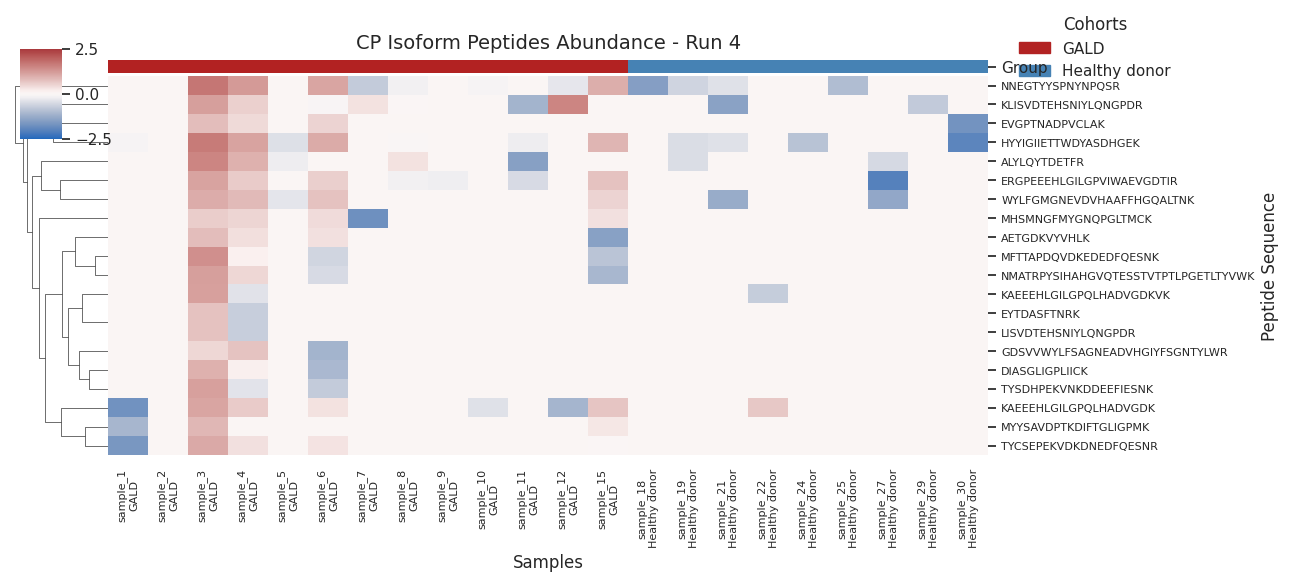


Generating Heatmap for Run 5...


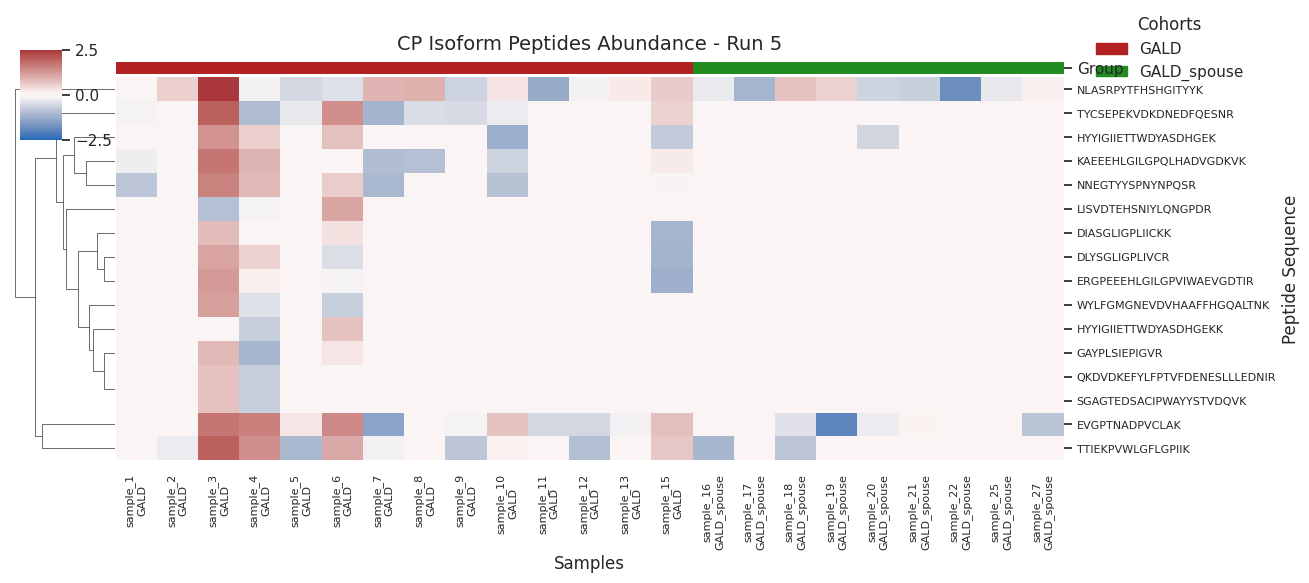


Generating Heatmap for Run 6...


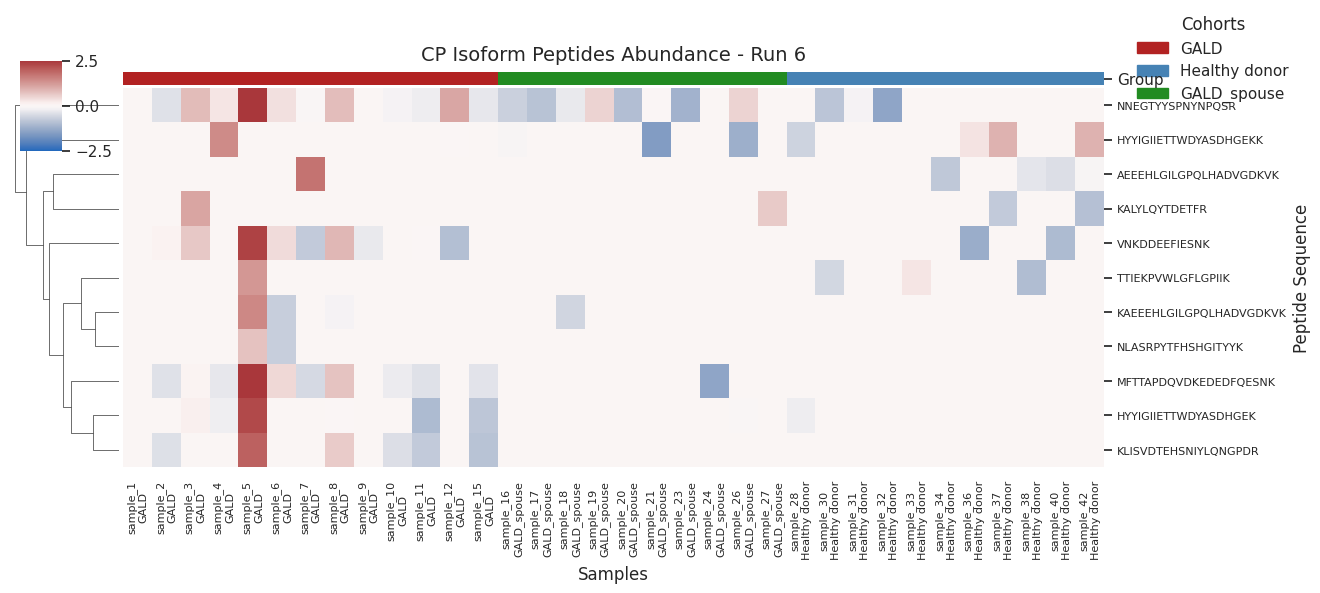

In [ ]:
#Non-clustered heatmap of peptide-level: 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches

# Helper function for "natural" alphanumeric sorting (so sample_2 comes before sample_11)
def alphanum_key(s):
    return [int(c) if c.isdigit() else c.lower() for c in re.split('([0-9]+)', s)]

# Define target CP isoforms
target_hits_list = ["P00450", "E9PFZ2", "H7C5R1", "D6RE86", "H7C5N5"] 

# Use your MaxQuant DataFrames
runs_peptide = [
    ('Run 4', master_pep_run4_maxQuant_df),
    ('Run 5', master_pep_run5_maxQuant_df),
    ('Run 6', master_pep_run6_maxQuant_df)
]

# Define cohort colors for the heatmap header
group_palette = {
    'GALD': 'firebrick', 
    'Healthy donor': 'steelblue', 
    'GALD_spouse': 'forestgreen'
}

for run_name, pep_df in runs_peptide:
    print(f"\nGenerating Heatmap for {run_name}...")

    # 1. Filter for the target CP isoforms
    df_filtered = pep_df[pep_df["Protein"].isin(target_hits_list)].copy()
    
    if df_filtered.empty:
        print(f"⏩ No target peptides found in {run_name}. Skipping.")
        continue

    # Set column names
    peptide_col = 'Peptide Sequence'
    intensity_col = 'Razor Intensity'

    # Ensure intensity is numeric
    df_filtered[intensity_col] = pd.to_numeric(df_filtered[intensity_col], errors='coerce')

    # ==========================================
    # Concatenate Sample and Group
    # ==========================================
    df_filtered['Sample_Label'] = df_filtered['Sample'].astype(str) + '\n' + df_filtered['Group'].astype(str)

    # 2. Extract Sample-to-Group mapping
    sample_group_map = df_filtered[['Sample_Label', 'Group']].drop_duplicates().set_index('Sample_Label')['Group']
    
    # NEW: Sort samples sequentially (sample_1, sample_2... sample_11) instead of by cohort
    sorted_samples = sorted(sample_group_map.index.tolist(), key=alphanum_key)

    # 3. Pivot data into a matrix: Rows = Peptides, Columns = Sample_Label
    pivot_df = df_filtered.pivot_table(
        index=peptide_col, 
        columns='Sample_Label', 
        values=intensity_col, 
        aggfunc='sum'
    )

    # Ensure all sorted samples are present
    for sample in sorted_samples:
        if sample not in pivot_df.columns:
            pivot_df[sample] = np.nan
            
    # Reorder columns by our sequential numerical list
    pivot_df = pivot_df[sorted_samples]

    # 4. Log2 Transform & Z-Score Row-wise (Peptide-wise)
    log_df = np.log2(pivot_df.replace(0, np.nan))
    
    with np.errstate(invalid='ignore'):
        z_df = log_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

    # Drop peptides that have no variance (std=0) or are entirely NaN
    z_df = z_df.dropna(how='all')
    
    # Fill remaining missing values with 0 (the mean of a Z-score) for clustering purposes
    z_df_filled = z_df.fillna(0)

    if z_df_filled.empty:
        print(f"⏩ No valid numeric data left after processing {run_name}. Skipping.")
        continue

    # 5. Map the column colors based on the cohorts
    col_colors = sample_group_map[sorted_samples].map(group_palette)

    # 6. Generate the Clustermap
    fig = sns.clustermap(
        z_df_filled,
        row_cluster=True,       # Cluster peptides with similar abundance patterns
        col_cluster=False,      # CRITICAL: Keep false to preserve strict sample_1, sample_2 ordering
        col_colors=col_colors,  # Adds the color bar at the top indicating the group
        cmap='vlag',            # Blue/White/Red diverging colormap
        center=0,
        vmin=-2.5, vmax=2.5,    # Cap the Z-score colors at +/- 2.5 standard deviations
        figsize=(14, max(6, len(z_df_filled) * 0.25)), # Dynamically scale height
        dendrogram_ratio=(0.1, 0.05),
        cbar_pos=(0.02, 0.8, 0.03, 0.15),
        xticklabels=True,
        yticklabels=True
    )

    # Formatting
    fig.ax_heatmap.set_title(f"CP Isoform Peptides Abundance - {run_name}", fontsize=14, pad=20)
    fig.ax_heatmap.set_xlabel("Samples", fontsize=12)
    fig.ax_heatmap.set_ylabel("Peptide Sequence", fontsize=12)
    
    # Rotate x-axis labels 90 degrees to handle the newline beautifully 
    plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=90, ha="center", fontsize=8)
    plt.setp(fig.ax_heatmap.get_yticklabels(), fontsize=8)

    # Add custom legend for the Cohort header strip
    legend_patches = [mpatches.Patch(color=color, label=group) for group, color in group_palette.items() if group in sample_group_map.values]
    fig.ax_col_dendrogram.legend(handles=legend_patches, title='Cohorts', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    # Display directly in notebook
    plt.show()


Generating Heatmap for Run 4...


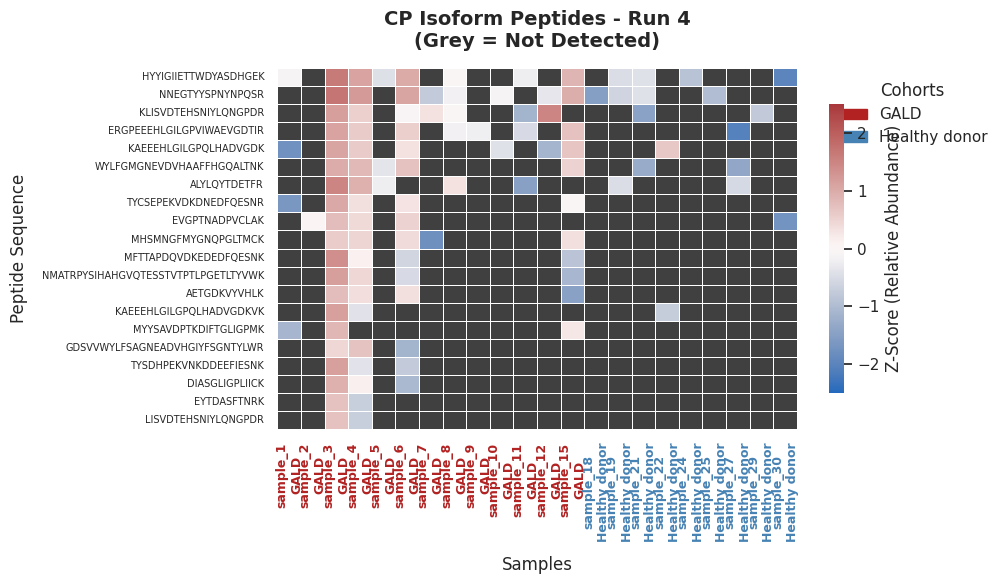


Generating Heatmap for Run 5...


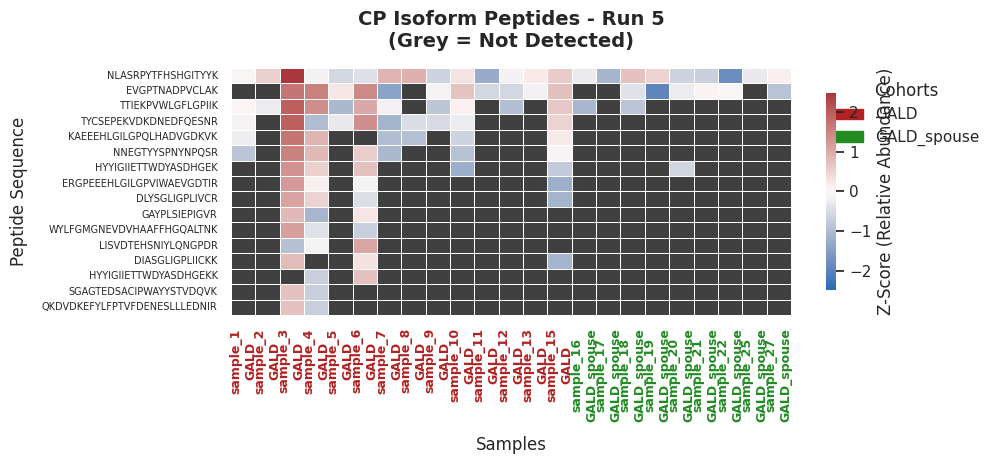


Generating Heatmap for Run 6...


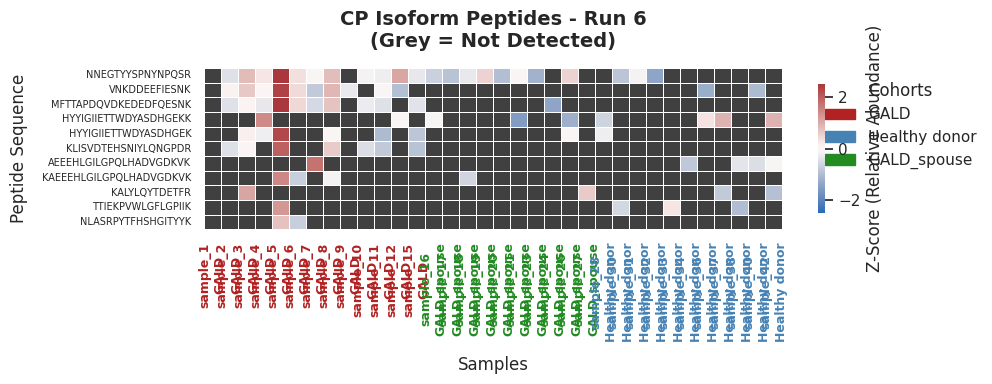

In [162]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches

# Helper function for "natural" alphanumeric sorting
def alphanum_key(s):
    return [int(c) if c.isdigit() else c.lower() for c in re.split('([0-9]+)', s)]

target_hits_list = ["P00450", "E9PFZ2", "H7C5R1", "D6RE86", "H7C5N5"] 

runs_peptide = [
    ('Run 4', master_pep_run4_maxQuant_df),
    ('Run 5', master_pep_run5_maxQuant_df),
    ('Run 6', master_pep_run6_maxQuant_df)
]

group_palette = {
    'GALD': 'firebrick', 
    'Healthy donor': 'steelblue', 
    'GALD_spouse': 'forestgreen'
}

for run_name, pep_df in runs_peptide:
    print(f"\nGenerating Heatmap for {run_name}...")

    df_filtered = pep_df[pep_df["Protein"].isin(target_hits_list)].copy()
    
    if df_filtered.empty:
        print(f"⏩ No target peptides found in {run_name}. Skipping.")
        continue

    peptide_col = 'Peptide Sequence'
    intensity_col = 'Razor Intensity'

    df_filtered[intensity_col] = pd.to_numeric(df_filtered[intensity_col], errors='coerce')
    df_filtered['Sample_Label'] = df_filtered['Sample'].astype(str) + '\n' + df_filtered['Group'].astype(str)

    sample_group_map = df_filtered[['Sample_Label', 'Group']].drop_duplicates().set_index('Sample_Label')['Group']
    sorted_samples = sorted(sample_group_map.index.tolist(), key=alphanum_key)

    pivot_df = df_filtered.pivot_table(
        index=peptide_col, 
        columns='Sample_Label', 
        values=intensity_col, 
        aggfunc='sum'
    )

    for sample in sorted_samples:
        if sample not in pivot_df.columns:
            pivot_df[sample] = np.nan
            
    pivot_df = pivot_df[sorted_samples]

    # Log2 Transform & Z-Score
    log_df = np.log2(pivot_df.replace(0, np.nan))
    
    with np.errstate(invalid='ignore'):
        z_df = log_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

    z_df = z_df.dropna(how='all')
    
    # Sort peptides by detection frequency (fewest NaNs at the top) then by average intensity
    z_df['na_count'] = z_df.isna().sum(axis=1)
    z_df['mean_intensity'] = log_df.mean(axis=1)
    z_df = z_df.sort_values(by=['na_count', 'mean_intensity'], ascending=[True, False])
    z_df = z_df.drop(columns=['na_count', 'mean_intensity'])

    if z_df.empty:
        print(f"⏩ No valid numeric data left after processing {run_name}. Skipping.")
        continue

    # Setup the pure heatmap plot (No Clustermap fluff)
    fig, ax = plt.subplots(figsize=(10, max(4, len(z_df) * 0.3)))
    
    # Set background color for NaNs (Missing values)
    ax.set_facecolor('#404040') # Dark grey for missing data

    sns.heatmap(
        z_df,
        cmap='vlag',
        center=0,
        vmin=-2.5, vmax=2.5,
        ax=ax,
        cbar_kws={'label': 'Z-Score (Relative Abundance)', 'shrink': 0.8},
        linewidths=0.5,
        linecolor='white'
    )

    # Formatting
    ax.set_title(f"CP Isoform Peptides - {run_name}\n(Grey = Not Detected)", fontsize=14, weight='bold', pad=15)
    ax.set_xlabel("Samples", fontsize=12, labelpad=10)
    ax.set_ylabel("Peptide Sequence", fontsize=12, labelpad=10)
    
    # Color the X-axis labels based on their cohort
    for tick_label in ax.get_xticklabels():
        sample_name = tick_label.get_text()
        group_name = sample_group_map.get(sample_name)
        if group_name in group_palette:
            tick_label.set_color(group_palette[group_name])
            tick_label.set_fontweight('bold')

    plt.xticks(rotation=90, ha="center", fontsize=9)
    plt.yticks(fontsize=7)

    # Clean Legend
    legend_patches = [mpatches.Patch(color=color, label=group) for group, color in group_palette.items() if group in sample_group_map.values]
    ax.legend(handles=legend_patches, title='Cohorts', loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

    plt.tight_layout()
    plt.show()


Generating Heatmap for Run 4...


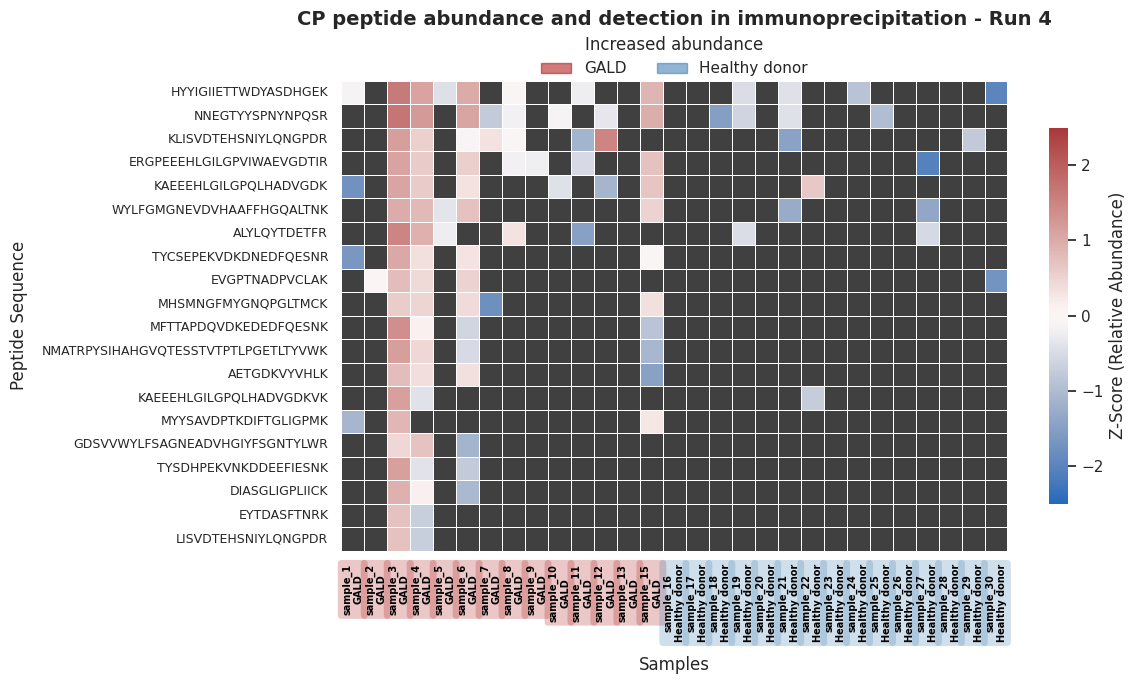


Generating Heatmap for Run 5...


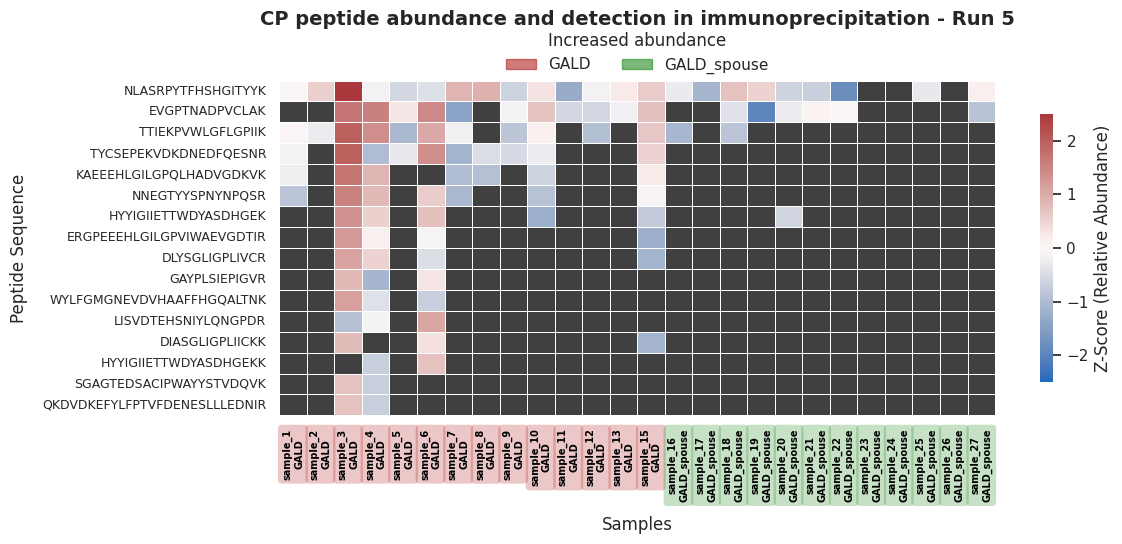


Generating Heatmap for Run 6...


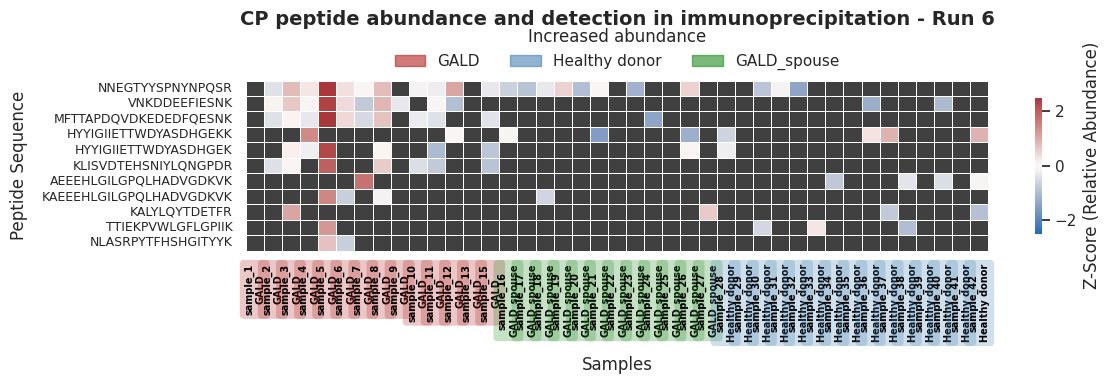

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches

# Helper function for "natural" alphanumeric sorting
def alphanum_key(s):
    return [int(c) if c.isdigit() else c.lower() for c in re.split('([0-9]+)', s)]

target_hits_list = ["P00450", "E9PFZ2", "H7C5R1", "D6RE86", "H7C5N5"] 

runs_peptide = [
    ('Run 4', master_pep_run4_maxQuant_df),
    ('Run 5', master_pep_run5_maxQuant_df),
    ('Run 6', master_pep_run6_maxQuant_df)
]

group_palette = {
    'GALD': 'firebrick', 
    'Healthy donor': 'steelblue', 
    'GALD_spouse': 'forestgreen'
}

for run_name, pep_df in runs_peptide:
    print(f"\nGenerating Heatmap for {run_name}...")

    # ==========================================
    # 1. Capture ALL samples in the run first
    # ==========================================
    all_samples_df = pep_df[['Sample', 'Group']].drop_duplicates().copy()
    all_samples_df['Sample_Label'] = all_samples_df['Sample'].astype(str) + '\n' + all_samples_df['Group'].astype(str)
    
    # Create our master map and sorted list so empty samples are never forgotten
    sample_group_map = all_samples_df.set_index('Sample_Label')['Group']
    sorted_samples = sorted(sample_group_map.index.tolist(), key=alphanum_key)

    # ==========================================
    # 2. Filter for Target Peptides
    # ==========================================
    df_filtered = pep_df[pep_df["Protein"].isin(target_hits_list)].copy()
    
    if df_filtered.empty:
        print(f"⏩ No target peptides found in {run_name}. Skipping.")
        continue

    peptide_col = 'Peptide Sequence'
    intensity_col = 'Razor Intensity'

    df_filtered[intensity_col] = pd.to_numeric(df_filtered[intensity_col], errors='coerce')
    df_filtered['Sample_Label'] = df_filtered['Sample'].astype(str) + '\n' + df_filtered['Group'].astype(str)

    # ==========================================
    # 3. Pivot and inject missing samples
    # ==========================================
    pivot_df = df_filtered.pivot_table(
        index=peptide_col, 
        columns='Sample_Label', 
        values=intensity_col, 
        aggfunc='sum'
    )

    # Force ALL samples into the pivot table, filling missing ones with NaN
    for sample in sorted_samples:
        if sample not in pivot_df.columns:
            pivot_df[sample] = np.nan
            
    # Reorder columns by our sequential list
    pivot_df = pivot_df[sorted_samples]

    # ==========================================
    # 4. Math & Sorting
    # ==========================================
    # Log2 Transform & Z-Score
    log_df = np.log2(pivot_df.replace(0, np.nan))
    
    with np.errstate(invalid='ignore'):
        z_df = log_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

    # Drop peptides that are entirely NaN across all samples
    z_df = z_df.dropna(how='all')
    
    # Sort peptides by detection frequency (fewest NaNs at the top) then by average intensity
    z_df['na_count'] = z_df.isna().sum(axis=1)
    z_df['mean_intensity'] = log_df.mean(axis=1)
    z_df = z_df.sort_values(by=['na_count', 'mean_intensity'], ascending=[True, False])
    z_df = z_df.drop(columns=['na_count', 'mean_intensity'])

    if z_df.empty:
        print(f"⏩ No valid numeric data left after processing {run_name}. Skipping.")
        continue

    # ==========================================
    # 5. Drawing the Heatmap
    # ==========================================
    fig, ax = plt.subplots(figsize=(12, max(4, len(z_df) * 0.35))) # Made slightly wider
    
    # Set background color for NaNs (Missing values)
    ax.set_facecolor('#404040') 

    sns.heatmap(
        z_df,
        cmap='vlag',
        center=0,
        vmin=-2.5, vmax=2.5,
        ax=ax,
        cbar_kws={'label': 'Z-Score (Relative Abundance)', 'shrink': 0.8, 'pad': 0.05},
        linewidths=0.5,
        linecolor='white'
    )

    # Formatting
    ax.set_title(f"CP peptide abundance and detection in immunoprecipitation - {run_name}", fontsize=14, weight='bold', pad=40)
    ax.set_xlabel("Samples", fontsize=12, labelpad=10)
    ax.set_ylabel("Peptide Sequence", fontsize=12, labelpad=10)
    
    # Improve X-axis labels (Black text with soft colored background box)
    for tick_label in ax.get_xticklabels():
        sample_name = tick_label.get_text()
        group_name = sample_group_map.get(sample_name)
        if group_name in group_palette:
            tick_label.set_color("black")
            tick_label.set_fontweight('bold')
            # Add a colored bounding box behind the text
            tick_label.set_bbox(dict(facecolor=group_palette[group_name], edgecolor='none', alpha=0.25, boxstyle='round,pad=0.4'))

    plt.xticks(rotation=90, ha="center", fontsize=7)
    plt.yticks(fontsize=9)

    # Clean Legend (Moved to Top Center to avoid colorbar overlap)
    legend_patches = [mpatches.Patch(color=color, alpha=0.6, label=group) for group, color in group_palette.items() if group in sample_group_map.values]
    ax.legend(handles=legend_patches, title='Increased abundance', loc='lower center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=False)

    plt.tight_layout()
    plt.show()



Generating Heatmap for Run 4...


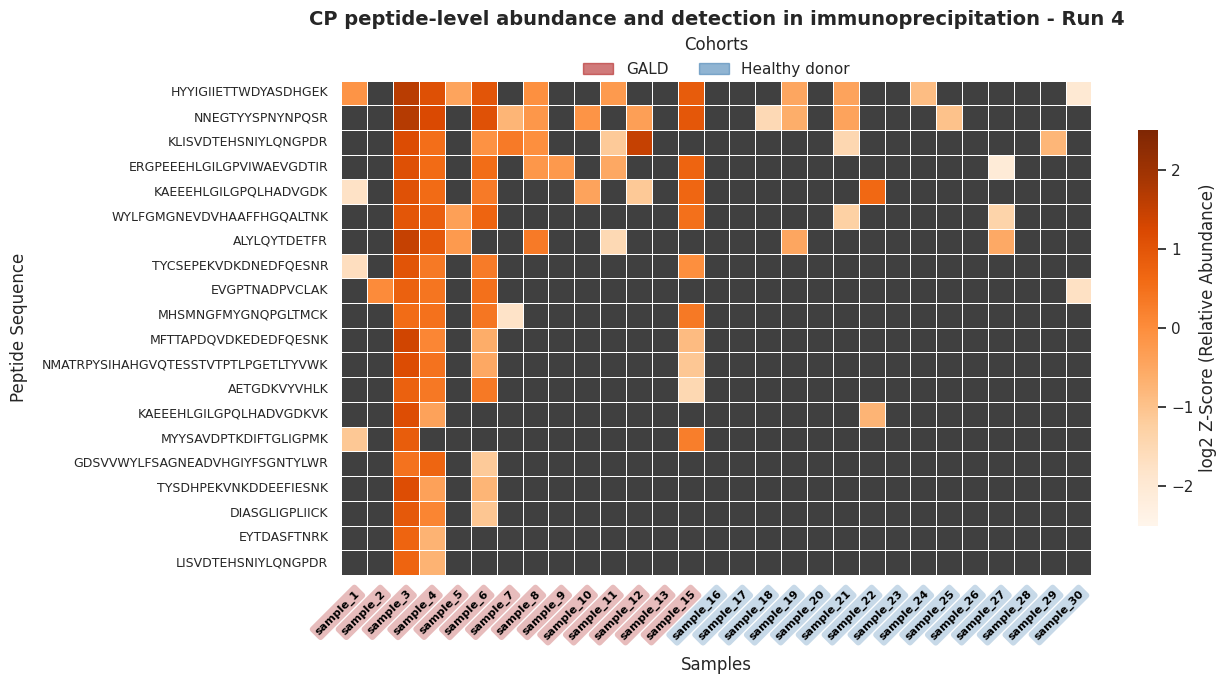


Generating Heatmap for Run 5...


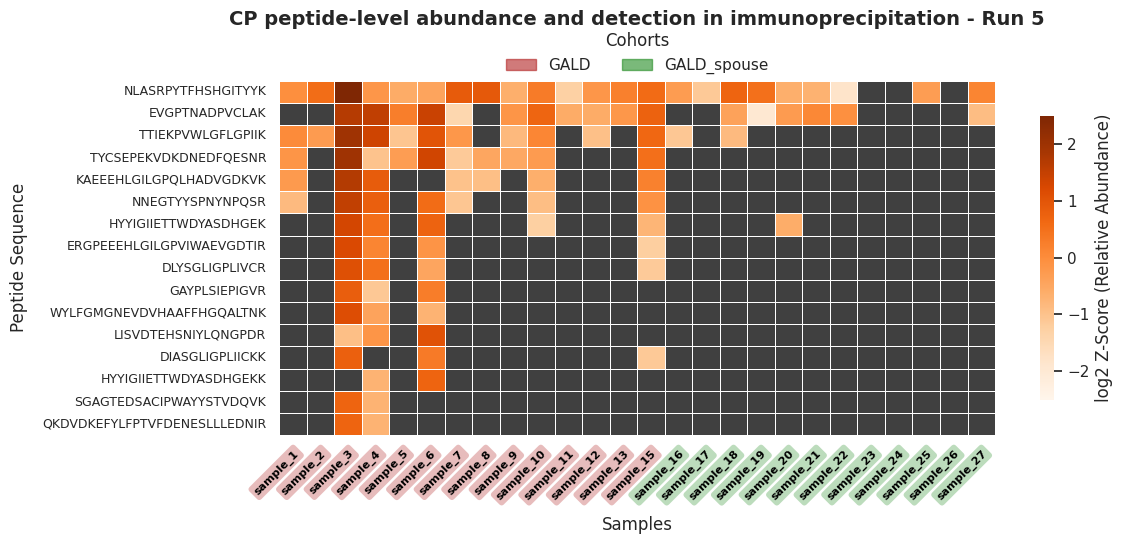


Generating Heatmap for Run 6...


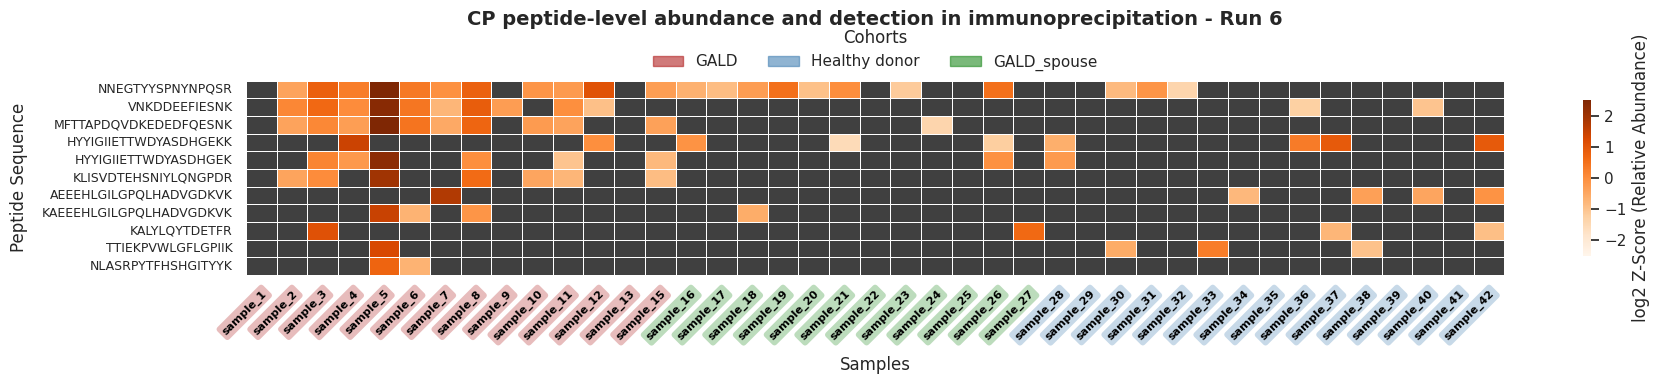

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches

# Helper function for "natural" alphanumeric sorting
def alphanum_key(s):
    return [int(c) if c.isdigit() else c.lower() for c in re.split('([0-9]+)', s)]

target_hits_list = ["P00450", "E9PFZ2", "H7C5R1", "D6RE86", "H7C5N5"] 

runs_peptide = [
    ('Run 4', master_pep_run4_maxQuant_df),
    ('Run 5', master_pep_run5_maxQuant_df),
    ('Run 6', master_pep_run6_maxQuant_df)
]

group_palette = {
    'GALD': 'firebrick', 
    'Healthy donor': 'steelblue', 
    'GALD_spouse': 'forestgreen'
}

for run_name, pep_df in runs_peptide:
    print(f"\nGenerating Heatmap for {run_name}...")

    # ==========================================
    # 1. Capture ALL samples in the run first
    # ==========================================
    all_samples_df = pep_df[['Sample', 'Group']].drop_duplicates().copy()
    all_samples_df['Sample_Label'] = all_samples_df['Sample'].astype(str) + '\n' + all_samples_df['Group'].astype(str)
    
    # Create our master map and sorted list so empty samples are never forgotten
    sample_group_map = all_samples_df.set_index('Sample_Label')['Group']
    sorted_samples = sorted(sample_group_map.index.tolist(), key=alphanum_key)

    # ==========================================
    # 2. Filter for Target Peptides
    # ==========================================
    df_filtered = pep_df[pep_df["Protein"].isin(target_hits_list)].copy()
    
    if df_filtered.empty:
        print(f"⏩ No target peptides found in {run_name}. Skipping.")
        continue

    peptide_col = 'Peptide Sequence'
    intensity_col = 'Razor Intensity'

    df_filtered[intensity_col] = pd.to_numeric(df_filtered[intensity_col], errors='coerce')
    df_filtered['Sample_Label'] = df_filtered['Sample'].astype(str) + '\n' + df_filtered['Group'].astype(str)

    # ==========================================
    # 3. Pivot and inject missing samples
    # ==========================================
    pivot_df = df_filtered.pivot_table(
        index=peptide_col, 
        columns='Sample_Label', 
        values=intensity_col, 
        aggfunc='sum'
    )

    # Force ALL samples into the pivot table, filling missing ones with NaN
    for sample in sorted_samples:
        if sample not in pivot_df.columns:
            pivot_df[sample] = np.nan
            
    # Reorder columns by our sequential list
    pivot_df = pivot_df[sorted_samples]

    # ==========================================
    # 4. Math & Sorting
    # ==========================================
    # Log2 Transform & Z-Score
    log_df = np.log2(pivot_df.replace(0, np.nan))
    
    with np.errstate(invalid='ignore'):
        z_df = log_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

    # Drop peptides that are entirely NaN across all samples
    z_df = z_df.dropna(how='all')
    
    # Sort peptides by detection frequency (fewest NaNs at the top) then by average intensity
    z_df['na_count'] = z_df.isna().sum(axis=1)
    z_df['mean_intensity'] = log_df.mean(axis=1)
    z_df = z_df.sort_values(by=['na_count', 'mean_intensity'], ascending=[True, False])
    z_df = z_df.drop(columns=['na_count', 'mean_intensity'])

    if z_df.empty:
        print(f"⏩ No valid numeric data left after processing {run_name}. Skipping.")
        continue

    # ==========================================
    # 5. Drawing the Heatmap
    # ==========================================
    # Dynamically scale width based on sample count to give them breathing room
    dynamic_width = max(12, len(sorted_samples) * 0.45)
    fig, ax = plt.subplots(figsize=(dynamic_width, max(4, len(z_df) * 0.35))) 
    
    # Set background color for NaNs (Missing values)
    ax.set_facecolor('#404040') 

    sns.heatmap(
        z_df,
        #cmap='vlag',
        cmap = 'Oranges',
        center=0,
        vmin=-2.5, vmax=2.5,
        ax=ax,
        cbar_kws={'label': 'log2 Z-Score (Peptide abundance)', 'shrink': 0.8, 'pad': 0.05},
        linewidths=0.5,
        linecolor='white'
    )

    # Formatting
    ax.set_title(f"CP peptide-level abundance and detection in immunoprecipitation - {run_name}", fontsize=14, weight='bold', pad=40)
    ax.set_xlabel("Samples", fontsize=12, labelpad=10)
    ax.set_ylabel("Peptide Sequence", fontsize=12, labelpad=10)
    
    # Improve X-axis labels: Strip the text to just "sample_X", rely on box color for group info
    labels = ax.get_xticklabels()
    for tick_label in labels:
        full_label = tick_label.get_text() # This holds 'sample_X\nGroup'
        group_name = sample_group_map.get(full_label)
        
        # Keep only the sample name for the text
        sample_name_only = full_label.split('\n')[0]
        tick_label.set_text(sample_name_only)
        
        if group_name in group_palette:
            tick_label.set_color("black")
            tick_label.set_fontweight('bold')
            tick_label.set_bbox(dict(facecolor=group_palette[group_name], edgecolor='none', alpha=0.3, boxstyle='round,pad=0.3'))

    # Re-apply the modified labels with a clean 45-degree angled layout
    ax.set_xticklabels(labels)
    plt.xticks(rotation=45, ha="right", rotation_mode="anchor", fontsize=8)
    plt.yticks(fontsize=9)

    # Clean Legend
    legend_patches = [mpatches.Patch(color=color, alpha=0.6, label=group) for group, color in group_palette.items() if group in sample_group_map.values]
    ax.legend(handles=legend_patches, title='Cohorts', loc='lower center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=False)

    plt.tight_layout()
    plt.show()
    